In [1]:
# ============================================================
# Cell 1: Setup — Drive mount, imports, constants, seeds
# ============================================================
# Bolted Flange Looseness Detection — ML Final Project 2026
# Team 23: Saurav Silwal, Bhupendra Joshi, Saurav Maraseni
# ============================================================

# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Standard library ---
import os, re, glob, time, random, warnings, pickle, json
from pathlib import Path
warnings.filterwarnings('ignore')

# --- Numerical / data ---
import numpy as np
import pandas as pd

# --- Audio ---
import librosa
import librosa.display
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.signal import welch

# --- ML (shallow) ---
from sklearn.model_selection import (
    train_test_split, GridSearchCV, LeaveOneGroupOut, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, f1_score
)
from sklearn.pipeline import Pipeline

# --- Deep learning ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi'] = 100

# ============================================================
# Reproducibility — set seeds everywhere
# ============================================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ============================================================
# Project-wide constants
# ============================================================
# --- Paths ---
DATA_DIR = '/content/drive/MyDrive/Training Data 2026'   # raw .m4a files live here
OUTPUT_DIR = '/content/drive/MyDrive/ML_Project_2026'    # we'll save artifacts here
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Audio ---
SR = 48000                       # target sample rate (matches iPhone recording)

# --- Hit detection (validated on 50ftlbF2A2.m4a → 21 hits cleanly extracted) ---
RMS_FRAME_LENGTH = 512           # samples per RMS frame
RMS_HOP_LENGTH   = 128           # hop between RMS frames
PEAK_REL_THRESH  = 0.30          # peak height as fraction of envelope max
PEAK_MIN_DIST_S  = 0.30          # minimum gap between peaks (seconds)

# --- Hit window: 20 ms pre + 500 ms post → 520 ms total ---
PRE_PEAK_S       = 0.020         # 20 ms before peak
POST_PEAK_S      = 0.500         # 500 ms after peak
HIT_WINDOW_S     = PRE_PEAK_S + POST_PEAK_S
HIT_WINDOW_LEN   = int(HIT_WINDOW_S * SR)   # = 24960 samples

# --- Quality filter (rejects noise / non-impulsive hits) ---
MIN_PEAK_AMP     = 0.05          # absolute peak amplitude floor
MIN_CREST_FACTOR = 4.0           # peak / RMS — ensures impulsive
MIN_ATTACK_RATIO = 0.6           # peak energy fraction in first 20 ms

# --- Mel-spectrogram (for CNN) ---
N_MELS           = 64
N_FFT            = 2048
HOP_LENGTH_MEL   = 375           # → ~128 frames over 500 ms window
SPEC_TIME_FRAMES = 128           # fixed time dimension

# --- Classes ---
CLASS_LABELS     = [0, 25, 50]   # ft-lbs
CLASS_TO_IDX     = {0: 0, 25: 1, 50: 2}    # label → integer for sklearn
IDX_TO_CLASS     = {v: k for k, v in CLASS_TO_IDX.items()}
N_CLASSES        = 3

# --- Flanges and areas ---
FLANGE_IDS       = [1, 2, 3, 4]
AREA_IDS         = [1, 2, 3, 4]

# ============================================================
# Sanity check
# ============================================================
print(f"TensorFlow version : {tf.__version__}")
print(f"Librosa version    : {librosa.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Sample rate (SR)   : {SR} Hz")
print(f"Hit window length  : {HIT_WINDOW_LEN} samples ({HIT_WINDOW_S*1000:.0f} ms)")
print(f"Data directory     : {DATA_DIR}")
print(f"Output directory   : {OUTPUT_DIR}")
print(f"Drive contents     : {len(os.listdir(DATA_DIR))} files in DATA_DIR"
      if os.path.exists(DATA_DIR) else "⚠️  DATA_DIR not found — check path")

Mounted at /content/drive
TensorFlow version : 2.20.0
Librosa version    : 0.11.0
NumPy version      : 2.0.2
Sample rate (SR)   : 48000 Hz
Hit window length  : 24960 samples (520 ms)
Data directory     : /content/drive/MyDrive/Training Data 2026
Output directory   : /content/drive/MyDrive/ML_Project_2026
Drive contents     : 48 files in DATA_DIR


In [2]:
# ============================================================
# Cell 2: File index — parse filenames into a DataFrame
# ============================================================
# Filename pattern: {class}ftlbF{flange}A{area}.m4a
# Example: 50ftlbF2A2.m4a → class=50, flange=2, area=2
# Expected: 4 flanges × 3 classes × 4 areas = 48 files
# ============================================================

# Regex for the filename pattern (case-insensitive, tolerant of optional 's' in 'ftlbs')
FILENAME_RE = re.compile(
    r'^(?P<cls>\d+)\s*ftlbs?\s*F(?P<flange>\d+)\s*A(?P<area>\d+)\.m4a$',
    re.IGNORECASE
)

def parse_filename(fname):
    """Extract (class_label, flange_id, area_id) from filename, or None if no match."""
    m = FILENAME_RE.match(fname.strip())
    if not m:
        return None
    return {
        'class_label': int(m.group('cls')),
        'flange_id'  : int(m.group('flange')),
        'area_id'    : int(m.group('area')),
    }

# ============================================================
# Build index
# ============================================================
records = []
unmatched = []

for fname in sorted(os.listdir(DATA_DIR)):
    # skip hidden files and non-audio
    if fname.startswith('.') or not fname.lower().endswith('.m4a'):
        continue
    parsed = parse_filename(fname)
    if parsed is None:
        unmatched.append(fname)
        continue
    parsed['filename']  = fname
    parsed['filepath']  = os.path.join(DATA_DIR, fname)
    parsed['class_idx'] = CLASS_TO_IDX[parsed['class_label']]
    records.append(parsed)

file_index = pd.DataFrame(records)

# Reorder columns for readability
file_index = file_index[['filename', 'flange_id', 'class_label', 'class_idx',
                         'area_id', 'filepath']]

# ============================================================
# Sanity checks
# ============================================================
print(f"Total files indexed : {len(file_index)}")
print(f"Unmatched files     : {len(unmatched)}")
if unmatched:
    print("  →", unmatched)

print("\nClass distribution (files per class):")
print(file_index['class_label'].value_counts().sort_index().to_string())

print("\nFlange distribution (files per flange):")
print(file_index['flange_id'].value_counts().sort_index().to_string())

print("\nArea distribution (files per area):")
print(file_index['area_id'].value_counts().sort_index().to_string())

print("\nFull coverage check (flange × class × area):")
coverage = file_index.groupby(['flange_id', 'class_label', 'area_id']).size().reset_index(name='count')
n_combos = len(coverage)
print(f"  → {n_combos} unique (flange, class, area) combos found "
      f"(expected 48: 4×3×4)")
print(f"  → Counts per combo: min={coverage['count'].min()}, "
      f"max={coverage['count'].max()} (should both be 1)")

print("\nFirst 5 rows of index:")
print(file_index.head().to_string(index=False))

# Save index for later cells
file_index.to_csv(os.path.join(OUTPUT_DIR, 'file_index.csv'), index=False)
print(f"\n✓ Saved file index → {os.path.join(OUTPUT_DIR, 'file_index.csv')}")

Total files indexed : 48
Unmatched files     : 0

Class distribution (files per class):
class_label
0     16
25    16
50    16

Flange distribution (files per flange):
flange_id
1    12
2    12
3    12
4    12

Area distribution (files per area):
area_id
1    12
2    12
3    12
4    12

Full coverage check (flange × class × area):
  → 48 unique (flange, class, area) combos found (expected 48: 4×3×4)
  → Counts per combo: min=1, max=1 (should both be 1)

First 5 rows of index:
     filename  flange_id  class_label  class_idx  area_id                                                filepath
0ftlbF1A1.m4a          1            0          0        1 /content/drive/MyDrive/Training Data 2026/0ftlbF1A1.m4a
0ftlbF1A2.m4a          1            0          0        2 /content/drive/MyDrive/Training Data 2026/0ftlbF1A2.m4a
0ftlbF1A3.m4a          1            0          0        3 /content/drive/MyDrive/Training Data 2026/0ftlbF1A3.m4a
0ftlbF1A4.m4a          1            0          0        4 /cont

Extracting hits from 48 files...



  0%|          | 0/48 [00:00<?, ?it/s]


EXTRACTION SUMMARY
Files processed       : 48
Total peaks detected  : 991
Hits kept             : 991
Hits rejected         : 0
Avg detected per file : 20.6
Avg kept per file     : 20.6
Waveform array shape  : (991, 24960)  (98.9 MB)

Kept-hit class distribution:
  class  0 ft-lbs : 328 hits
  class 25 ft-lbs : 330 hits
  class 50 ft-lbs : 333 hits

Kept-hit flange distribution:
  flange 1 : 246 hits
  flange 2 : 243 hits
  flange 3 : 253 hits
  flange 4 : 249 hits

✓ All files yielded ≥15 hits.

✓ Saved waveforms → /content/drive/MyDrive/ML_Project_2026/extracted_hits.npz
✓ Saved diagnostics → quality_log.csv, per_file_stats.csv


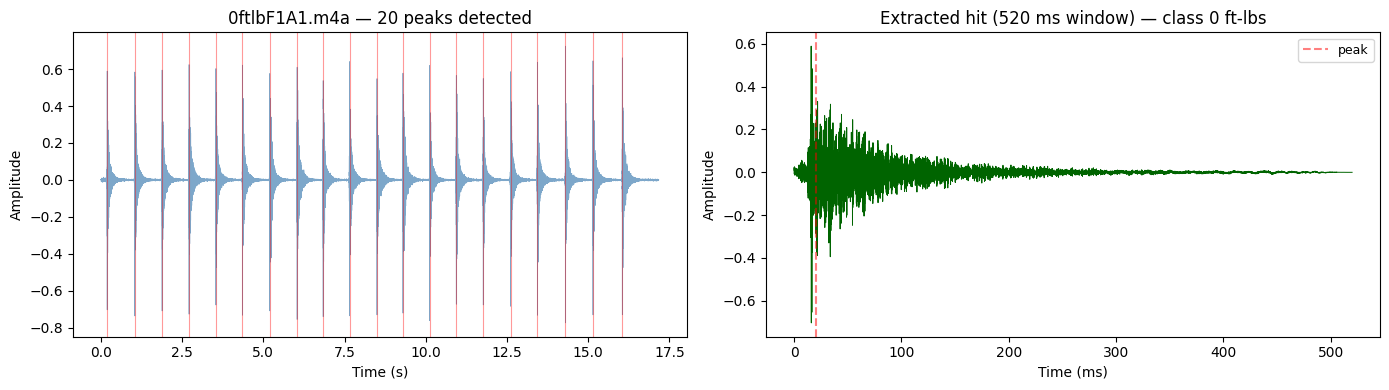

In [3]:
# ============================================================
# Cell 3: Hit detection — extract individual hits from each file
# ============================================================
# For each .m4a:
#   1. Load at 48 kHz
#   2. Compute RMS envelope, detect peaks (validated: 0.30×max, 300ms apart)
#   3. Extract 520ms window (20ms pre + 500ms post) around each peak
#   4. Apply quality filter (peak amp, crest factor, attack ratio)
#   5. Apply Hann fade-out on last 10% to remove window-edge artifacts
# Output: stacked array of shape (N_hits, 24960) + label/group arrays
# ============================================================

from tqdm.auto import tqdm

# Pre-compute sample counts from time constants
PRE_SAMPLES   = int(PRE_PEAK_S  * SR)    # 960
POST_SAMPLES  = int(POST_PEAK_S * SR)    # 24000
FADE_SAMPLES  = int(0.10 * HIT_WINDOW_LEN)   # last 10% Hann fade-out
ATTACK_WIN_S  = 0.050                    # 50 ms — for attack-ratio measurement

# ============================================================
# Helper functions
# ============================================================
def load_audio_safe(filepath, sr=SR):
    """Load any audio file at target sample rate, silencing librosa fallback warnings."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        y, _ = librosa.load(filepath, sr=sr, mono=True)
    return y.astype(np.float32)

def detect_peaks_rms(y, sr=SR):
    """Find hit-peak sample indices via RMS envelope."""
    rms = librosa.feature.rms(
        y=y, frame_length=RMS_FRAME_LENGTH, hop_length=RMS_HOP_LENGTH
    )[0]
    if rms.max() <= 0:
        return np.array([], dtype=int)
    height_thresh = PEAK_REL_THRESH * rms.max()
    min_dist_frames = int(PEAK_MIN_DIST_S * sr / RMS_HOP_LENGTH)
    peak_frames, _ = find_peaks(rms, height=height_thresh, distance=min_dist_frames)
    return peak_frames * RMS_HOP_LENGTH      # convert frames → audio samples

def extract_window(y, peak_sample, pre, post):
    """Extract `pre` samples before and `post` after peak. Zero-pad if at file edge."""
    window = np.zeros(pre + post, dtype=np.float32)
    src_start = max(0, peak_sample - pre)
    src_end   = min(len(y), peak_sample + post)
    dst_start = src_start - (peak_sample - pre)
    dst_end   = dst_start + (src_end - src_start)
    window[dst_start:dst_end] = y[src_start:src_end]
    return window

def apply_hann_fadeout(window, fade_samples):
    """Cosine fade-out on the last `fade_samples` to suppress window-edge transients."""
    fade = np.hanning(2 * fade_samples)[fade_samples:]   # right half of Hann
    out = window.copy()
    out[-fade_samples:] *= fade
    return out

def compute_quality(window):
    """Return (peak_amp, crest_factor, attack_ratio)."""
    abs_w = np.abs(window)
    peak_amp = float(abs_w.max())
    rms_val  = float(np.sqrt(np.mean(window**2)))
    crest    = peak_amp / (rms_val + 1e-12)
    attack_samples = int(ATTACK_WIN_S * SR)
    attack_max     = float(abs_w[:attack_samples].max())
    attack_ratio   = attack_max / (peak_amp + 1e-12)
    return peak_amp, crest, attack_ratio

# ============================================================
# Main extraction loop
# ============================================================
waveforms     = []    # list of (HIT_WINDOW_LEN,) arrays
labels        = []    # class_idx (0/1/2)
flange_groups = []    # flange_id (1..4) — used as LOIO group
area_groups   = []    # area_id (1..4)
file_row_idx  = []    # row in file_index
hit_within    = []    # 0-based hit index within file
quality_log   = []    # full diagnostic record

per_file_stats = []

print("Extracting hits from 48 files...\n")
for i, row in tqdm(file_index.iterrows(), total=len(file_index)):
    y = load_audio_safe(row['filepath'])
    peaks = detect_peaks_rms(y)

    n_kept = n_rejected = 0
    for hit_i, p in enumerate(peaks):
        win = extract_window(y, p, PRE_SAMPLES, POST_SAMPLES)
        peak_amp, crest, attack = compute_quality(win)

        passed = (peak_amp >= MIN_PEAK_AMP
                  and crest >= MIN_CREST_FACTOR
                  and attack >= MIN_ATTACK_RATIO)

        quality_log.append({
            'filename': row['filename'],
            'hit_idx_in_file': hit_i,
            'peak_sample': int(p),
            'peak_time_s': float(p / SR),
            'peak_amp': peak_amp,
            'crest_factor': crest,
            'attack_ratio': attack,
            'kept': passed,
        })

        if not passed:
            n_rejected += 1
            continue

        win = apply_hann_fadeout(win, FADE_SAMPLES)
        waveforms.append(win)
        labels.append(row['class_idx'])
        flange_groups.append(row['flange_id'])
        area_groups.append(row['area_id'])
        file_row_idx.append(i)
        hit_within.append(hit_i)
        n_kept += 1

    per_file_stats.append({
        'filename': row['filename'],
        'flange': row['flange_id'],
        'class':  row['class_label'],
        'area':   row['area_id'],
        'detected': len(peaks),
        'kept':     n_kept,
        'rejected': n_rejected,
    })

# ============================================================
# Stack into arrays
# ============================================================
waveforms     = np.stack(waveforms, axis=0)            # (N, 24960) float32
labels        = np.array(labels,        dtype=np.int64)
flange_groups = np.array(flange_groups, dtype=np.int64)
area_groups   = np.array(area_groups,   dtype=np.int64)
file_row_idx  = np.array(file_row_idx,  dtype=np.int64)

quality_df = pd.DataFrame(quality_log)
per_file_df = pd.DataFrame(per_file_stats)

# ============================================================
# Diagnostics
# ============================================================
print(f"\n{'='*60}")
print(f"EXTRACTION SUMMARY")
print(f"{'='*60}")
print(f"Files processed       : {len(file_index)}")
print(f"Total peaks detected  : {len(quality_df)}")
print(f"Hits kept             : {len(waveforms)}")
print(f"Hits rejected         : {(~quality_df['kept']).sum()}")
print(f"Avg detected per file : {per_file_df['detected'].mean():.1f}")
print(f"Avg kept per file     : {per_file_df['kept'].mean():.1f}")
print(f"Waveform array shape  : {waveforms.shape}  ({waveforms.nbytes/1e6:.1f} MB)")

print(f"\nKept-hit class distribution:")
for cls_idx, count in zip(*np.unique(labels, return_counts=True)):
    print(f"  class {IDX_TO_CLASS[cls_idx]:>2} ft-lbs : {count} hits")

print(f"\nKept-hit flange distribution:")
for fl, count in zip(*np.unique(flange_groups, return_counts=True)):
    print(f"  flange {fl} : {count} hits")

# Flag any files with unusually low yield
low_yield = per_file_df[per_file_df['kept'] < 15].sort_values('kept')
if len(low_yield):
    print(f"\n⚠️  {len(low_yield)} files with <15 kept hits (expected ~20):")
    print(low_yield.to_string(index=False))
else:
    print(f"\n✓ All files yielded ≥15 hits.")

# ============================================================
# Save extracted data + diagnostics
# ============================================================
np.savez_compressed(
    os.path.join(OUTPUT_DIR, 'extracted_hits.npz'),
    waveforms=waveforms, labels=labels,
    flange_groups=flange_groups, area_groups=area_groups,
    file_row_idx=file_row_idx,
)
quality_df.to_csv(os.path.join(OUTPUT_DIR, 'quality_log.csv'), index=False)
per_file_df.to_csv(os.path.join(OUTPUT_DIR, 'per_file_stats.csv'), index=False)
print(f"\n✓ Saved waveforms → {os.path.join(OUTPUT_DIR, 'extracted_hits.npz')}")
print(f"✓ Saved diagnostics → quality_log.csv, per_file_stats.csv")

# ============================================================
# Visual sanity check
# ============================================================
sample_file = file_index.iloc[0]
y_sample = load_audio_safe(sample_file['filepath'])
rms_sample = librosa.feature.rms(
    y=y_sample, frame_length=RMS_FRAME_LENGTH, hop_length=RMS_HOP_LENGTH
)[0]
peaks_sample = detect_peaks_rms(y_sample)

# Pick first kept hit from this file (if any)
hits_from_file_0 = np.where(file_row_idx == 0)[0]
example_hit_idx = hits_from_file_0[0] if len(hits_from_file_0) else None

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full file waveform with peak markers
t_full = np.arange(len(y_sample)) / SR
axes[0].plot(t_full, y_sample, lw=0.5, color='steelblue', alpha=0.7)
for p in peaks_sample:
    axes[0].axvline(p / SR, color='red', alpha=0.4, lw=0.8)
axes[0].set_title(f"{sample_file['filename']} — {len(peaks_sample)} peaks detected")
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

# Right: one extracted, windowed hit
if example_hit_idx is not None:
    t_hit = np.arange(HIT_WINDOW_LEN) / SR * 1000  # ms
    axes[1].plot(t_hit, waveforms[example_hit_idx], color='darkgreen', lw=0.7)
    axes[1].axvline(PRE_PEAK_S * 1000, color='red', ls='--', alpha=0.5, label='peak')
    axes[1].set_title(f"Extracted hit (520 ms window) — class {IDX_TO_CLASS[labels[example_hit_idx]]} ft-lbs")
    axes[1].set_xlabel('Time (ms)')
    axes[1].set_ylabel('Amplitude')
    axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# Cell 4: Feature extractor — 82-dim physics-informed vector
# ============================================================
# Group 1: Relative PSD in 20 log-spaced bins (50 Hz – 8 kHz)   → 20 dims
# Group 2: MFCC mean/std + delta MFCC mean/std (13 coeffs each) → 52 dims
# Group 3: Physics features (centroid, bandwidth, rolloff, ZCR,
#          peak freq, decay τ, energy ratio, RMS, Q-factor)     → 10 dims
# Total                                                          → 82 dims
# ============================================================
# This is the "moat": τ and Q-factor directly encode the physical
# mechanism of bolt looseness. Loose → low τ, low Q. Tight → high τ, high Q.
# ============================================================

# --- Constants for feature extraction ---
N_PSD_BINS       = 20
PSD_FMIN         = 50.0       # Hz, lowest log-bin edge
PSD_FMAX         = 8000.0     # Hz, highest log-bin edge
WELCH_NPERSEG    = 2048
WELCH_NOVERLAP   = 1024

N_MFCC           = 13
MFCC_NFFT        = 2048
MFCC_HOP         = 512

DECAY_FIT_MS     = 200        # fit τ over 200 ms post-peak
EARLY_LATE_FRAC  = 0.20       # E_early/E_late = first/last 20% of window
PEAK_SAMPLE_IN_WINDOW = PRE_SAMPLES   # peak sits at sample 960 (20 ms)

# ============================================================
# Group 1: Relative PSD in log-spaced bins
# ============================================================
def relative_psd_log_bins(y, sr=SR, n_bins=N_PSD_BINS,
                          f_min=PSD_FMIN, f_max=PSD_FMAX):
    """Welch PSD → integrate into log-spaced bins → normalize so sum = 1.
    Returns (bins[n_bins], f_full, pxx_full) — last two reused downstream."""
    f, pxx = welch(y, fs=sr,
                   nperseg=min(WELCH_NPERSEG, len(y)),
                   noverlap=min(WELCH_NOVERLAP, len(y) // 2))
    edges = np.logspace(np.log10(f_min), np.log10(f_max), n_bins + 1)
    bins = np.zeros(n_bins, dtype=np.float32)
    for i in range(n_bins):
        mask = (f >= edges[i]) & (f < edges[i+1])
        bins[i] = pxx[mask].sum()
    total = bins.sum()
    if total > 1e-20:
        bins = bins / total          # → relative (sum = 1.0)
    return bins, f, pxx

# ============================================================
# Group 2: MFCC and delta-MFCC statistics
# ============================================================
def mfcc_stats(y, sr=SR):
    """13 MFCCs → mean+std (26) + delta mean+std (26) = 52 dims."""
    mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC,
                                  n_fft=MFCC_NFFT, hop_length=MFCC_HOP)
    delta = librosa.feature.delta(mfcc)
    return np.concatenate([
        mfcc.mean(axis=1),  mfcc.std(axis=1),
        delta.mean(axis=1), delta.std(axis=1),
    ]).astype(np.float32)

# ============================================================
# Group 3: Physics features
# ============================================================
def peak_frequency(f, pxx):
    """Frequency of dominant resonance (argmax of PSD)."""
    if pxx.max() <= 0: return 0.0
    return float(f[np.argmax(pxx)])

def q_factor(f, pxx):
    """Q = f_peak / bandwidth at -3 dB. High Q = tight (rings cleanly)."""
    if pxx.max() <= 0: return 0.0
    pdb = 10 * np.log10(pxx + 1e-20)
    peak_idx = int(np.argmax(pdb))
    threshold = pdb[peak_idx] - 3.0
    # walk left/right until we drop below -3 dB
    L = peak_idx
    while L > 0 and pdb[L] >= threshold: L -= 1
    R = peak_idx
    while R < len(pdb) - 1 and pdb[R] >= threshold: R += 1
    bw = max(f[R] - f[L], 1.0)
    return float(f[peak_idx] / bw)

def decay_tau(y, peak_sample=PEAK_SAMPLE_IN_WINDOW, sr=SR, fit_ms=DECAY_FIT_MS):
    """Decay time constant τ from linear fit to log-envelope.
    Loose flange → small τ (fast damp). Tight flange → large τ (long ring)."""
    n_fit  = int(fit_ms * sr / 1000)
    seg    = y[peak_sample : min(peak_sample + n_fit, len(y))]
    if len(seg) < 100: return np.nan

    # smoothed amplitude envelope (5 ms moving average of |y|)
    env_w  = max(1, int(0.005 * sr))
    env    = np.convolve(np.abs(seg), np.ones(env_w)/env_w, mode='same')
    if env.max() < 1e-8: return np.nan

    # fit only over "active" region — where envelope ≥ 5% of its peak
    active = np.where(env > 0.05 * env.max())[0]
    if len(active) < 50: return np.nan
    n_active = active[-1] + 1

    eps      = env.max() * 1e-4
    log_env  = np.log(env[:n_active] + eps)
    t        = np.arange(n_active) / sr
    slope, _ = np.polyfit(t, log_env, 1)
    if slope >= 0: return np.nan      # not actually decaying
    tau = -1.0 / slope
    return float(tau) if 0.001 <= tau <= 10.0 else np.nan

def energy_ratio(y, frac=EARLY_LATE_FRAC):
    """E_late / E_early. Tight flanges still ringing → high ratio."""
    n_chunk = int(frac * len(y))
    e_early = np.sqrt(np.mean(y[:n_chunk]**2))
    e_late  = np.sqrt(np.mean(y[-n_chunk:]**2))
    return float(e_late / (e_early + 1e-12))

# ============================================================
# Master extractor — combines all three groups
# ============================================================
def extract_feature_vector(y, sr=SR):
    """Return concatenated 82-dim feature vector for one hit."""
    psd_bins, f_psd, pxx = relative_psd_log_bins(y, sr)            # 20

    cepstral = mfcc_stats(y, sr)                                   # 52

    sc    = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    sb    = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    sr85  = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)[0]
    zcr   = librosa.feature.zero_crossing_rate(y)[0]

    physics = np.array([
        sc.mean(),  sc.std(),                  # 2: centroid mean/std
        sb.mean(),                             # 1: bandwidth mean
        sr85.mean(),                           # 1: 85% rolloff mean
        zcr.mean(),                            # 1: zero-crossing rate
        peak_frequency(f_psd, pxx),            # 1: dominant freq
        decay_tau(y),                          # 1: τ (may be NaN)
        energy_ratio(y),                       # 1: E_late / E_early
        np.sqrt(np.mean(y**2)),                # 1: full-window RMS
        q_factor(f_psd, pxx),                  # 1: Q-factor
    ], dtype=np.float32)                       # → 10 total

    return np.concatenate([psd_bins, cepstral, physics])

# ============================================================
# Build feature-name list (for interpretability later)
# ============================================================
def build_feature_names():
    names = []
    edges = np.logspace(np.log10(PSD_FMIN), np.log10(PSD_FMAX), N_PSD_BINS + 1)
    for i in range(N_PSD_BINS):
        names.append(f'psd_{edges[i]:.0f}_{edges[i+1]:.0f}Hz')
    names += [f'mfcc{i:02d}_mean'  for i in range(N_MFCC)]
    names += [f'mfcc{i:02d}_std'   for i in range(N_MFCC)]
    names += [f'dmfcc{i:02d}_mean' for i in range(N_MFCC)]
    names += [f'dmfcc{i:02d}_std'  for i in range(N_MFCC)]
    names += ['spec_centroid_mean', 'spec_centroid_std',
              'spec_bandwidth_mean', 'spec_rolloff85_mean',
              'zero_cross_rate_mean', 'peak_frequency',
              'decay_tau', 'energy_ratio', 'rms_energy', 'q_factor']
    return names

FEATURE_NAMES = build_feature_names()
N_FEATURES    = len(FEATURE_NAMES)

# ============================================================
# Sanity test on one hit + class-discrimination preview
# ============================================================
print(f"Feature vector length: {N_FEATURES}  (expected 82)")
assert N_FEATURES == 82, "Feature count mismatch"

print(f"\n--- Testing extractor on waveforms[0] ---")
import time
t0 = time.time()
feat0 = extract_feature_vector(waveforms[0])
t_one = time.time() - t0
print(f"Shape: {feat0.shape}, NaNs: {np.isnan(feat0).sum()}, "
      f"range: [{np.nanmin(feat0):.3f}, {np.nanmax(feat0):.3f}]")
print(f"Group 1 PSD bins sum  : {feat0[:20].sum():.4f}  (should be ~1.0)")
print(f"Single-hit time       : {t_one*1000:.1f} ms")
print(f"Estimated full extract: {t_one * len(waveforms):.1f} s for {len(waveforms)} hits")

# Compare one example from each class — quick "physics works?" check
print(f"\n--- Class discrimination preview (one hit per class) ---")
print(f"{'Class':<8} {'τ (s)':>10} {'E_late/E_early':>16} "
      f"{'Peak Hz':>10} {'Q-factor':>10} {'Centroid':>10}")
for cls_idx in [0, 1, 2]:
    idx = np.where(labels == cls_idx)[0][0]
    f = extract_feature_vector(waveforms[idx])
    tau, eratio, pf, qf, sc_mean = f[-4], f[-3], f[-5], f[-1], f[-10]
    print(f"{IDX_TO_CLASS[cls_idx]:>3} ft-lb  "
          f"{tau:>10.4f} {eratio:>16.4f} {pf:>10.0f} {qf:>10.2f} {sc_mean:>10.0f}")
print("\nExpected pattern: τ, energy_ratio, peak_freq, Q all rise with tightness.")

Feature vector length: 82  (expected 82)

--- Testing extractor on waveforms[0] ---
Shape: (82,), NaNs: 0, range: [-432.623, 4618.144]
Group 1 PSD bins sum  : 1.0000  (should be ~1.0)
Single-hit time       : 65.3 ms
Estimated full extract: 64.7 s for 991 hits

--- Class discrimination preview (one hit per class) ---
Class         τ (s)   E_late/E_early    Peak Hz   Q-factor   Centroid
  0 ft-lb      0.0728           0.0241       3914      55.67       3340
 25 ft-lb      0.0901           0.0394       2695      57.50       2904
 50 ft-lb      0.1055           0.0444       4102      87.50       3114

Expected pattern: τ, energy_ratio, peak_freq, Q all rise with tightness.


Spectrogram shape    : (64, 128)  (expected (64, 128))
Mean / Std           : 0.000 / 1.000  (≈ 0 / 1 after standardize)
Range                : [-0.77, 3.19]
NaNs                 : 0
Single-hit time      : 5.1 ms
Estimated full extract: 5.0 s for 991 hits


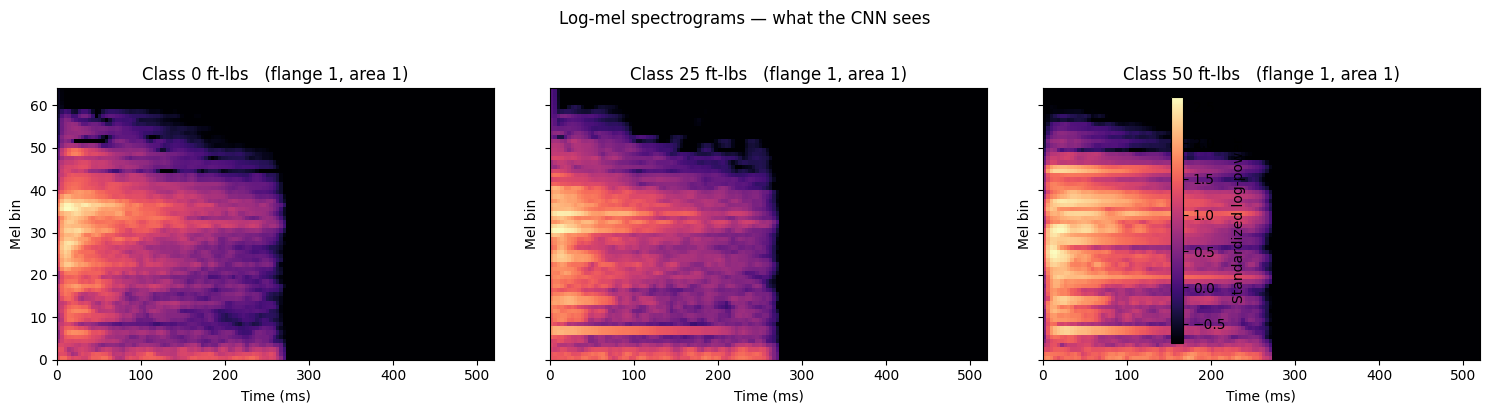


Look for: tighter flange (50 ft-lbs) → energy persists longer in time, with cleaner horizontal bands at resonance frequencies.


In [5]:
# ============================================================
# Cell 5: Mel-spectrogram extractor — input for the CNN
# ============================================================
# Each hit → log-mel spectrogram, shape (N_MELS=64, SPEC_TIME_FRAMES=128)
# Per-sample standardization (subtract mean / divide by std) so the CNN
# sees a consistent dynamic range regardless of recording loudness.
# ============================================================

# Constants from Cell 1: N_MELS=64, N_FFT=2048, HOP_LENGTH_MEL=375, SPEC_TIME_FRAMES=128
# At hop=375 over 24960 samples: ~67 frames natively. We'll pad to 128.
# Mel range: 0 Hz to Nyquist (24000 Hz) — covers the full audible spectrum
# we care about.

FMIN_MEL = 0
FMAX_MEL = SR // 2          # Nyquist = 24000 Hz

def extract_mel_spectrogram(y, sr=SR,
                            n_mels=N_MELS, n_fft=N_FFT,
                            hop_length=HOP_LENGTH_MEL,
                            target_frames=SPEC_TIME_FRAMES):
    """One hit → standardized log-mel spectrogram of fixed shape (n_mels, target_frames).

    Pipeline:
      1. mel power spectrogram
      2. power → dB (log compression, ref=max within this hit)
      3. pad with min value (silence) or center-crop to fixed time dim
      4. per-sample standardize (zero mean, unit std)
    """
    # 1) mel power spectrogram
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels,
        n_fft=n_fft, hop_length=hop_length,
        fmin=FMIN_MEL, fmax=FMAX_MEL, power=2.0,
    )

    # 2) log-compress to dB (ref=max gives values mostly in [-80, 0])
    mel_db = librosa.power_to_db(mel, ref=np.max).astype(np.float32)

    # 3) fix time dimension to target_frames
    n_frames = mel_db.shape[1]
    if n_frames < target_frames:
        # pad on the right with the min value (= "silence" in dB)
        pad_val = float(mel_db.min())
        pad_amt = target_frames - n_frames
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_amt)),
                        mode='constant', constant_values=pad_val)
    elif n_frames > target_frames:
        # center-crop to keep the transient + decay
        start = (n_frames - target_frames) // 2
        mel_db = mel_db[:, start:start + target_frames]

    # 4) per-sample standardize
    mu, sigma = mel_db.mean(), mel_db.std()
    mel_db = (mel_db - mu) / (sigma + 1e-6)

    return mel_db  # shape (n_mels, target_frames) = (64, 128)

# ============================================================
# Sanity test + visual preview
# ============================================================
import time
t0 = time.time()
spec0 = extract_mel_spectrogram(waveforms[0])
t_one = time.time() - t0

print(f"Spectrogram shape    : {spec0.shape}  (expected (64, 128))")
print(f"Mean / Std           : {spec0.mean():.3f} / {spec0.std():.3f}  (≈ 0 / 1 after standardize)")
print(f"Range                : [{spec0.min():.2f}, {spec0.max():.2f}]")
print(f"NaNs                 : {np.isnan(spec0).sum()}")
print(f"Single-hit time      : {t_one*1000:.1f} ms")
print(f"Estimated full extract: {t_one * len(waveforms):.1f} s for {len(waveforms)} hits")

assert spec0.shape == (N_MELS, SPEC_TIME_FRAMES), "Spec shape mismatch"

# ============================================================
# Visual: one spectrogram per class
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, cls_idx in zip(axes, [0, 1, 2]):
    idx = np.where(labels == cls_idx)[0][0]
    spec = extract_mel_spectrogram(waveforms[idx])
    im = ax.imshow(spec, origin='lower', aspect='auto', cmap='magma',
                   extent=[0, HIT_WINDOW_S * 1000, 0, N_MELS])
    ax.set_title(f'Class {IDX_TO_CLASS[cls_idx]} ft-lbs   '
                 f'(flange {flange_groups[idx]}, area {area_groups[idx]})')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Mel bin')

plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label='Standardized log-power')
plt.suptitle('Log-mel spectrograms — what the CNN sees', y=1.02)
plt.tight_layout()
plt.show()

print("\nLook for: tighter flange (50 ft-lbs) → energy persists longer in time, "
      "with cleaner horizontal bands at resonance frequencies.")

Extracting 82-dim feature vectors for 991 hits...


  0%|          | 0/991 [00:00<?, ?it/s]

  → done in 20.5 s (20.7 ms/hit)

✓ No NaNs in feature matrix.

Extracting mel spectrograms for 991 hits...


  0%|          | 0/991 [00:00<?, ?it/s]

  → done in 3.6 s (3.7 ms/hit)

✓ Saved → /content/drive/MyDrive/ML_Project_2026/features.npz

FEATURE MATRIX SUMMARY
X_feat shape  : (991, 82)   (0.3 MB)
X_spec shape  : (991, 64, 128, 1)   (32.5 MB)
y shape       : (991,), classes: [0 1 2]
groups shape  : (991,), flanges: [1 2 3 4]

Class-wise feature ranges (raw, no scaling yet):
  feature                       class 0       class 25       class 50
  decay_tau                      0.0895         0.0997         0.1031
  energy_ratio                   0.0258         0.0331         0.0348
  q_factor                      50.4579        50.2818        51.6171
  peak_frequency              3355.8499      3047.5852      3315.4561
  spec_centroid_mean          3358.9465      3279.8833      3421.9744
  rms_energy                     0.0473         0.0527         0.0509


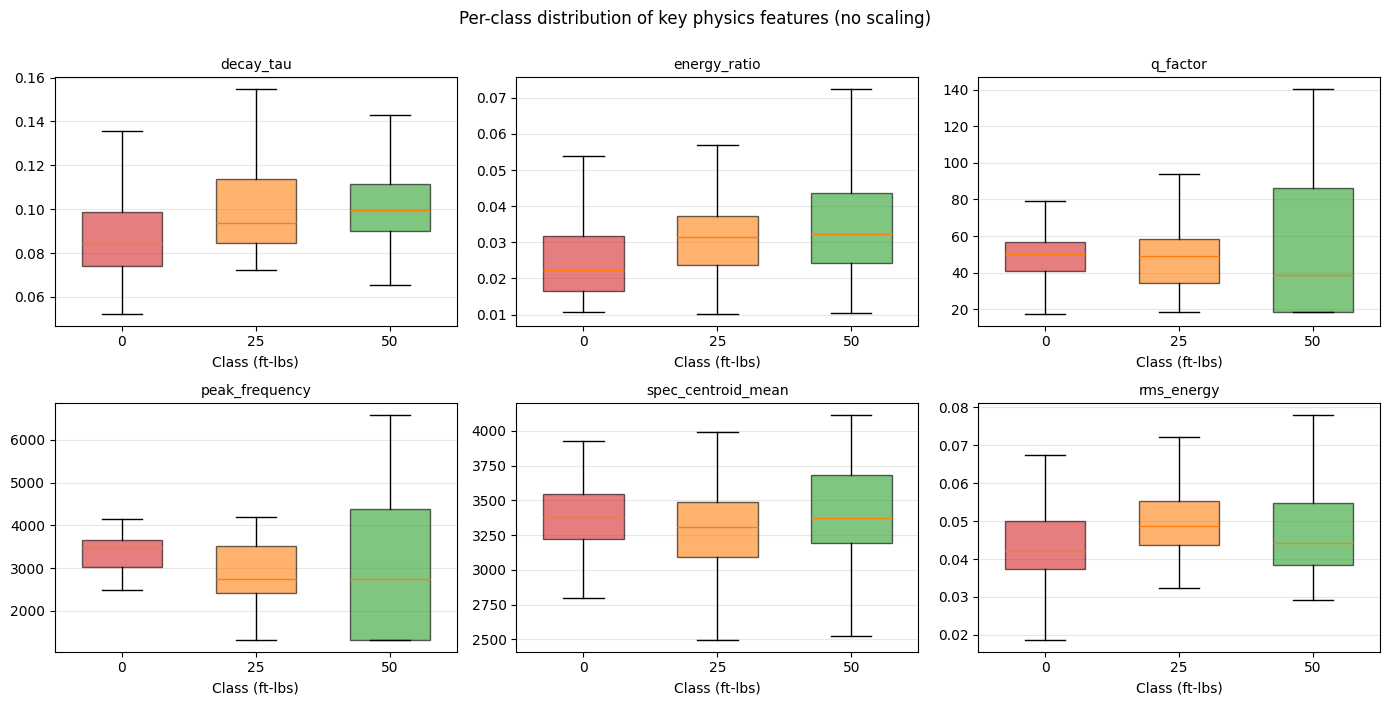

In [6]:
# ============================================================
# Cell 6: Run both extractors over all 991 hits
# ============================================================
# Outputs:
#   X_feat  (N, 82)         → SVM, LR, MLP input
#   X_spec  (N, 64, 128, 1) → CNN input
#   y       (N,)            → labels (0/1/2)
#   groups  (N,)            → flange_id (1..4) for LOIO
# ============================================================

from tqdm.auto import tqdm

N_HITS = len(waveforms)

# ============================================================
# 1) Tabular feature matrix
# ============================================================
print(f"Extracting 82-dim feature vectors for {N_HITS} hits...")
X_feat = np.zeros((N_HITS, N_FEATURES), dtype=np.float32)

t0 = time.time()
for i in tqdm(range(N_HITS)):
    X_feat[i] = extract_feature_vector(waveforms[i])
t_feat = time.time() - t0
print(f"  → done in {t_feat:.1f} s ({t_feat/N_HITS*1000:.1f} ms/hit)")

# ============================================================
# 2) Impute NaNs in tau (only feature that can fail)
# ============================================================
nan_mask = np.isnan(X_feat)
nan_per_col = nan_mask.sum(axis=0)
nan_cols = np.where(nan_per_col > 0)[0]

if len(nan_cols):
    print(f"\nNaN columns ({len(nan_cols)}):")
    for c in nan_cols:
        print(f"  {FEATURE_NAMES[c]:<25} : {nan_per_col[c]} NaN ({100*nan_per_col[c]/N_HITS:.1f}%)")
    # Per-class median imputation — keeps signal while filling gaps
    print("Imputing with per-class median...")
    for c in nan_cols:
        for cls in range(N_CLASSES):
            cls_mask = (labels == cls)
            col_vals = X_feat[cls_mask, c]
            median_val = np.nanmedian(col_vals)
            if np.isnan(median_val):
                median_val = np.nanmedian(X_feat[:, c])  # global fallback
            fill_mask = cls_mask & np.isnan(X_feat[:, c])
            X_feat[fill_mask, c] = median_val
    print(f"  → remaining NaNs: {np.isnan(X_feat).sum()}")
else:
    print("\n✓ No NaNs in feature matrix.")

assert not np.isnan(X_feat).any(), "Still have NaNs — investigate before training"

# ============================================================
# 3) Mel-spectrogram tensor
# ============================================================
print(f"\nExtracting mel spectrograms for {N_HITS} hits...")
X_spec = np.zeros((N_HITS, N_MELS, SPEC_TIME_FRAMES, 1), dtype=np.float32)

t0 = time.time()
for i in tqdm(range(N_HITS)):
    X_spec[i, :, :, 0] = extract_mel_spectrogram(waveforms[i])
t_spec = time.time() - t0
print(f"  → done in {t_spec:.1f} s ({t_spec/N_HITS*1000:.1f} ms/hit)")

# ============================================================
# 4) Final arrays — y and groups (already built earlier; rename for clarity)
# ============================================================
y      = labels.astype(np.int64)
groups = flange_groups.astype(np.int64)

# ============================================================
# 5) Save everything for downstream cells
# ============================================================
np.savez_compressed(
    os.path.join(OUTPUT_DIR, 'features.npz'),
    X_feat=X_feat, X_spec=X_spec,
    y=y, groups=groups,
    area_groups=area_groups,
    feature_names=np.array(FEATURE_NAMES),
)
print(f"\n✓ Saved → {os.path.join(OUTPUT_DIR, 'features.npz')}")

# ============================================================
# 6) Diagnostics
# ============================================================
print(f"\n{'='*60}")
print("FEATURE MATRIX SUMMARY")
print(f"{'='*60}")
print(f"X_feat shape  : {X_feat.shape}   ({X_feat.nbytes/1e6:.1f} MB)")
print(f"X_spec shape  : {X_spec.shape}   ({X_spec.nbytes/1e6:.1f} MB)")
print(f"y shape       : {y.shape}, classes: {np.unique(y)}")
print(f"groups shape  : {groups.shape}, flanges: {np.unique(groups)}")

print(f"\nClass-wise feature ranges (raw, no scaling yet):")
print(f"  {'feature':<22} {'class 0':>14} {'class 25':>14} {'class 50':>14}")
for fname in ['decay_tau', 'energy_ratio', 'q_factor', 'peak_frequency',
              'spec_centroid_mean', 'rms_energy']:
    col = FEATURE_NAMES.index(fname)
    means = [X_feat[y == c, col].mean() for c in range(N_CLASSES)]
    print(f"  {fname:<22} {means[0]:>14.4f} {means[1]:>14.4f} {means[2]:>14.4f}")

# ============================================================
# 7) Quick visual: feature separation by class
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
plot_feats = ['decay_tau', 'energy_ratio', 'q_factor',
              'peak_frequency', 'spec_centroid_mean', 'rms_energy']
colors = ['#d62728', '#ff7f0e', '#2ca02c']  # red=loose, orange=mid, green=tight
for ax, fname in zip(axes.flat, plot_feats):
    col = FEATURE_NAMES.index(fname)
    data = [X_feat[y == c, col] for c in range(N_CLASSES)]
    bp = ax.boxplot(data, labels=['0', '25', '50'], patch_artist=True,
                    showfliers=False, widths=0.6)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(fname, fontsize=10)
    ax.set_xlabel('Class (ft-lbs)')
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Per-class distribution of key physics features (no scaling)', y=1.00)
plt.tight_layout()
plt.show()

TASK 1 — Dependent test  (70/30 stratified split)
Train: 693 samples,  Test: 298 samples
Grid search: 3.2 s   |   Best: {'svm__C': 1, 'svm__gamma': 'scale'}
Train acc :  99.86%
Test  acc : 100.00%   Macro-F1: 1.000

Per-class breakdown (test):
              precision    recall  f1-score   support

    0 ft-lbs       1.00      1.00      1.00        99
   25 ft-lbs       1.00      1.00      1.00        99
   50 ft-lbs       1.00      1.00      1.00       100

    accuracy                           1.00       298
   macro avg       1.00      1.00      1.00       298
weighted avg       1.00      1.00      1.00       298

TASK 2 — Independent test  (Leave-One-Flange-Out)
Fold 1 (held-out F1): 3-class= 76.02%   Binary= 86.59%   F1=0.756   C=100   γ=0.001
Fold 2 (held-out F2): 3-class= 58.44%   Binary= 90.12%   F1=0.543   C=1     γ=0.01
Fold 3 (held-out F3): 3-class= 84.98%   Binary= 99.60%   F1=0.842   C=1     γ=0.001
Fold 4 (held-out F4): 3-class= 81.93%   Binary= 94.38%   F1=0.817   C=100 

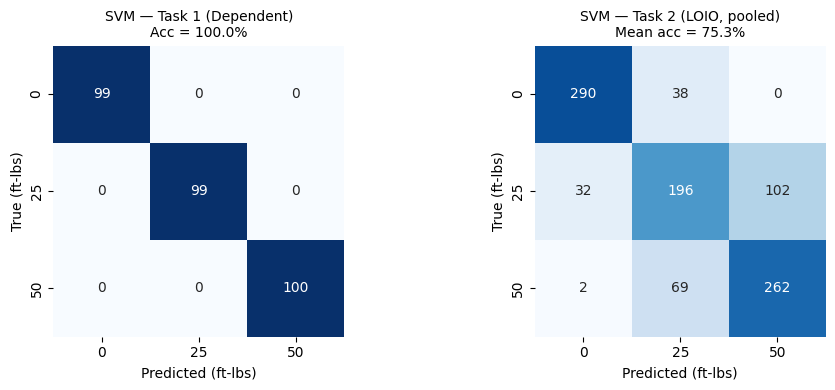

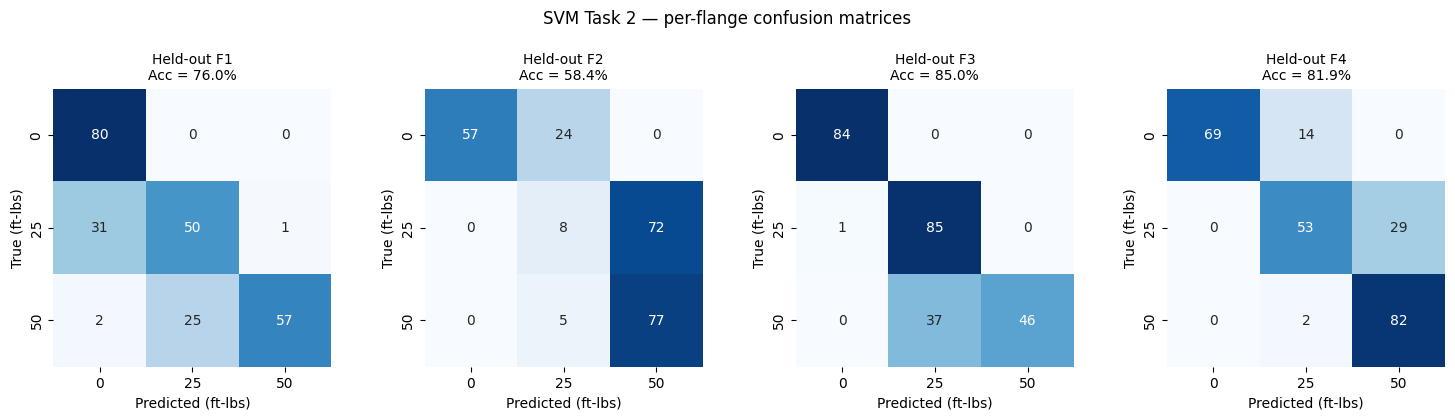


Final model: C=100, γ=0.001 (most common across LOIO folds)
✓ Saved → /content/drive/MyDrive/ML_Project_2026/model_svm.joblib

✓ svm_results cached for Cells 11 (comparison) and 12 (ensemble)


In [7]:
# ============================================================
# Cell 7: SVM (RBF kernel) — Task 1 (Dependent) + Task 2 (LOIO)
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay
from joblib import dump
from collections import Counter

# ============================================================
# Helper: confusion matrix plot (will be reused in Cells 8, 9, 10)
# ============================================================
def plot_confusion(y_true, y_pred, title, ax=None, normalize=True):
    """Heatmap with row-normalized colors but raw counts as annotations."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    if normalize:
        cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    else:
        cm_norm = cm.astype(float)
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.2, 3.6))
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=[f'{c}' for c in CLASS_LABELS],
                yticklabels=[f'{c}' for c in CLASS_LABELS],
                cbar=False, ax=ax, vmin=0, vmax=1, square=True)
    ax.set_xlabel('Predicted (ft-lbs)')
    ax.set_ylabel('True (ft-lbs)')
    ax.set_title(title, fontsize=10)
    return ax

# ============================================================
# Pipeline + grid (StandardScaler bundled so per-fold scaler refit is automatic)
# ============================================================
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', probability=True, class_weight='balanced',
                   decision_function_shape='ovr', random_state=SEED)),
])
svm_grid = {
    'svm__C':     [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01],
}

# ============================================================
# TASK 1 — Dependent test (70/30 stratified split)
# ============================================================
print("="*64)
print("TASK 1 — Dependent test  (70/30 stratified split)")
print("="*64)

X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_feat, y, test_size=0.30, stratify=y, random_state=SEED
)
print(f"Train: {len(y_tr1)} samples,  Test: {len(y_te1)} samples")

t0 = time.time()
gs1 = GridSearchCV(svm_pipe, svm_grid, cv=5, n_jobs=-1, scoring='accuracy')
gs1.fit(X_tr1, y_tr1)
t_t1 = time.time() - t0

svm_t1 = gs1.best_estimator_
acc_tr1   = svm_t1.score(X_tr1, y_tr1)
acc_te1   = svm_t1.score(X_te1, y_te1)
y_pred_t1 = svm_t1.predict(X_te1)
y_prob_t1 = svm_t1.predict_proba(X_te1)
f1_t1     = f1_score(y_te1, y_pred_t1, average='macro')

print(f"Grid search: {t_t1:.1f} s   |   Best: {gs1.best_params_}")
print(f"Train acc : {acc_tr1*100:6.2f}%")
print(f"Test  acc : {acc_te1*100:6.2f}%   Macro-F1: {f1_t1:.3f}")
print("\nPer-class breakdown (test):")
print(classification_report(y_te1, y_pred_t1,
                            target_names=[f'{c} ft-lbs' for c in CLASS_LABELS]))

# ============================================================
# TASK 2 — Independent test (LOIO over 4 flanges, fresh grid per fold)
# ============================================================
print("="*64)
print("TASK 2 — Independent test  (Leave-One-Flange-Out)")
print("="*64)

logo = LeaveOneGroupOut()
fold_records   = []
fold_test_idx  = []   # original-index arrays per fold
fold_y_true    = []
fold_y_pred    = []
fold_y_proba   = []

t0 = time.time()
for fold, (tr_idx, te_idx) in enumerate(logo.split(X_feat, y, groups), 1):
    flange_out = int(groups[te_idx[0]])
    X_tr, X_te = X_feat[tr_idx], X_feat[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    gs = GridSearchCV(svm_pipe, svm_grid, cv=5, n_jobs=-1, scoring='accuracy')
    gs.fit(X_tr, y_tr)

    y_p   = gs.predict(X_te)
    y_pr  = gs.predict_proba(X_te)
    acc3  = accuracy_score(y_te, y_p)
    f1    = f1_score(y_te, y_p, average='macro')
    accB  = accuracy_score((y_te > 0).astype(int), (y_p > 0).astype(int))

    fold_records.append({
        'fold': fold,
        'flange_out': flange_out,
        'best_C':     gs.best_params_['svm__C'],
        'best_gamma': gs.best_params_['svm__gamma'],
        '3class_acc': acc3,
        'binary_acc': accB,
        'macro_f1':   f1,
    })
    fold_test_idx.append(te_idx)
    fold_y_true.append(y_te)
    fold_y_pred.append(y_p)
    fold_y_proba.append(y_pr)

    print(f"Fold {fold} (held-out F{flange_out}): "
          f"3-class={acc3*100:6.2f}%   Binary={accB*100:6.2f}%   "
          f"F1={f1:.3f}   C={gs.best_params_['svm__C']:<5} γ={gs.best_params_['svm__gamma']}")

t_t2 = time.time() - t0
loio_df  = pd.DataFrame(fold_records)
mean3    = loio_df['3class_acc'].mean();  std3 = loio_df['3class_acc'].std()
meanB    = loio_df['binary_acc'].mean();  stdB = loio_df['binary_acc'].std()

print(f"\nLOIO mean : 3-class = {mean3*100:.2f}% ± {std3*100:.2f}%")
print(f"            Binary  = {meanB*100:.2f}% ± {stdB*100:.2f}%")
print(f"            Macro-F1 = {loio_df['macro_f1'].mean():.3f}")
print(f"Total LOIO time: {t_t2:.1f} s")

# ============================================================
# Confusion matrices
# ============================================================
y_true_pooled = np.concatenate(fold_y_true)
y_pred_pooled = np.concatenate(fold_y_pred)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion(y_te1, y_pred_t1,
               f'SVM — Task 1 (Dependent)\nAcc = {acc_te1*100:.1f}%',  ax=axes[0])
plot_confusion(y_true_pooled, y_pred_pooled,
               f'SVM — Task 2 (LOIO, pooled)\nMean acc = {mean3*100:.1f}%', ax=axes[1])
plt.tight_layout(); plt.show()

# Per-flange confusion matrices for Task 2
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for k, ax in enumerate(axes):
    fold = fold_records[k]
    plot_confusion(fold_y_true[k], fold_y_pred[k],
                   f"Held-out F{fold['flange_out']}\nAcc = {fold['3class_acc']*100:.1f}%",
                   ax=ax)
plt.suptitle('SVM Task 2 — per-flange confusion matrices', y=1.04)
plt.tight_layout(); plt.show()

# ============================================================
# Final SVM trained on ALL 991 hits (for ensemble + Task 3 lab inference)
# ============================================================
hp_votes = Counter([(r['best_C'], r['best_gamma']) for r in fold_records])
final_C, final_gamma = hp_votes.most_common(1)[0][0]

svm_final = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=final_C, gamma=final_gamma,
                   probability=True, class_weight='balanced',
                   random_state=SEED)),
])
svm_final.fit(X_feat, y)
dump(svm_final, os.path.join(OUTPUT_DIR, 'model_svm.joblib'))

print(f"\nFinal model: C={final_C}, γ={final_gamma} "
      f"(most common across LOIO folds)")
print(f"✓ Saved → {os.path.join(OUTPUT_DIR, 'model_svm.joblib')}")

# ============================================================
# Cache for ensemble (Cell 12) and comparison table (Cell 11)
# ============================================================
svm_results = {
    'name'             : 'SVM',
    'task1_test_acc'   : acc_te1,
    'task1_train_acc'  : acc_tr1,
    'task1_macro_f1'   : f1_t1,
    'task1_y_test'     : y_te1,
    'task1_y_pred'     : y_pred_t1,
    'task1_y_proba'    : y_prob_t1,
    'task1_test_idx'   : None,    # rebuildable from train_test_split seed
    'task2_mean_acc'   : mean3,
    'task2_mean_bin'   : meanB,
    'task2_mean_f1'    : loio_df['macro_f1'].mean(),
    'task2_per_fold'   : loio_df,
    'task2_test_idx'   : fold_test_idx,
    'task2_y_true'     : fold_y_true,
    'task2_y_pred'     : fold_y_pred,
    'task2_y_proba'    : fold_y_proba,   # for ensemble averaging
    'final_model'      : svm_final,
    'final_hp'         : {'C': final_C, 'gamma': final_gamma},
}
print("\n✓ svm_results cached for Cells 11 (comparison) and 12 (ensemble)")

TASK 1 — Dependent test  (70/30 stratified split)
Grid search: 0.1 s   |   Best: {'lr__C': 1}
Train acc : 100.00%
Test  acc :  99.66%   Macro-F1: 0.997

Per-class breakdown (test):
              precision    recall  f1-score   support

    0 ft-lbs       1.00      1.00      1.00        99
   25 ft-lbs       1.00      0.99      0.99        99
   50 ft-lbs       0.99      1.00      1.00       100

    accuracy                           1.00       298
   macro avg       1.00      1.00      1.00       298
weighted avg       1.00      1.00      1.00       298

TASK 2 — Independent test  (Leave-One-Flange-Out)
Fold 1: Train=[2, 3, 4] → Test=[1]   3-class= 71.95%   Binary= 77.24%   F1=0.713   C=1
Fold 2: Train=[1, 3, 4] → Test=[2]   3-class= 60.91%   Binary= 87.65%   F1=0.580   C=0.1
Fold 3: Train=[1, 2, 4] → Test=[3]   3-class= 82.21%   Binary= 99.21%   F1=0.809   C=0.01
Fold 4: Train=[1, 2, 3] → Test=[4]   3-class= 86.75%   Binary= 93.98%   F1=0.868   C=10

LOIO mean : 3-class = 75.45% ± 11

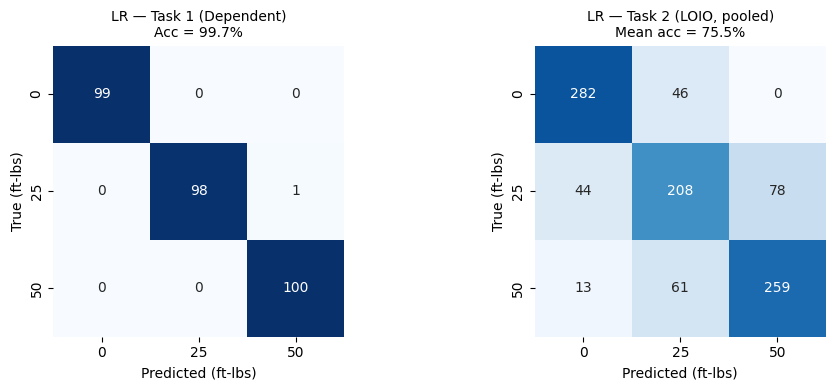

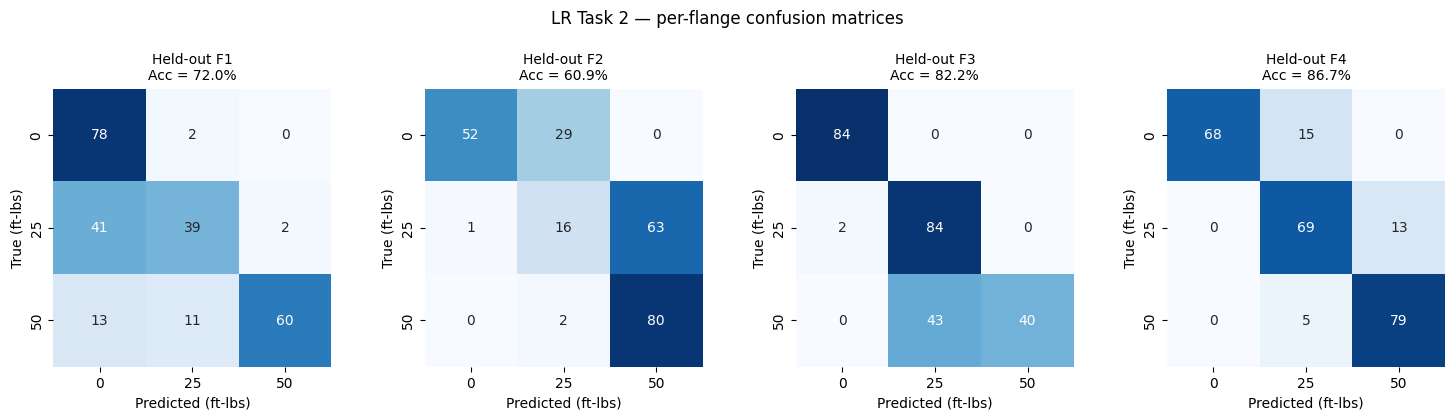


Final model: C=1 (most common across LOIO folds)
✓ Saved → /content/drive/MyDrive/ML_Project_2026/model_lr.joblib

✓ lr_results cached for Cells 11 (comparison) and 12 (ensemble)


In [8]:
# ============================================================
# Cell 8: Logistic Regression (multinomial) — Task 1 + Task 2
# ============================================================
# Linear baseline: same 82-dim input as SVM. If SVM beats LR
# significantly, the class boundary is non-linear (RBF wins).
# Bonus: LR gives well-calibrated probabilities for the ensemble.
# ============================================================

# ============================================================
# Pipeline + grid (single hyperparameter: regularization C)
# ============================================================
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(
                    multi_class='multinomial', solver='lbfgs',
                    class_weight='balanced', max_iter=2000,
                    random_state=SEED)),
])
lr_grid = {'lr__C': [0.001, 0.01, 0.1, 1, 10]}

# ============================================================
# TASK 1 — Dependent test (same 70/30 split as SVM)
# ============================================================
print("="*64)
print("TASK 1 — Dependent test  (70/30 stratified split)")
print("="*64)

# Reuse the same indices as Cell 7 by reseeding the same split
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_feat, y, test_size=0.30, stratify=y, random_state=SEED
)

t0 = time.time()
gs1 = GridSearchCV(lr_pipe, lr_grid, cv=5, n_jobs=-1, scoring='accuracy')
gs1.fit(X_tr1, y_tr1)
t_t1 = time.time() - t0

lr_t1     = gs1.best_estimator_
acc_tr1   = lr_t1.score(X_tr1, y_tr1)
acc_te1   = lr_t1.score(X_te1, y_te1)
y_pred_t1 = lr_t1.predict(X_te1)
y_prob_t1 = lr_t1.predict_proba(X_te1)
f1_t1     = f1_score(y_te1, y_pred_t1, average='macro')

print(f"Grid search: {t_t1:.1f} s   |   Best: {gs1.best_params_}")
print(f"Train acc : {acc_tr1*100:6.2f}%")
print(f"Test  acc : {acc_te1*100:6.2f}%   Macro-F1: {f1_t1:.3f}")
print("\nPer-class breakdown (test):")
print(classification_report(y_te1, y_pred_t1,
                            target_names=[f'{c} ft-lbs' for c in CLASS_LABELS]))

# ============================================================
# TASK 2 — LOIO (matches assignment Table 2: train on 3 flanges, test on 1)
# ============================================================
print("="*64)
print("TASK 2 — Independent test  (Leave-One-Flange-Out)")
print("="*64)

logo = LeaveOneGroupOut()
fold_records  = []
fold_test_idx = []
fold_y_true   = []
fold_y_pred   = []
fold_y_proba  = []

t0 = time.time()
for fold, (tr_idx, te_idx) in enumerate(logo.split(X_feat, y, groups), 1):
    flange_out    = int(groups[te_idx[0]])
    train_flanges = sorted(set([1, 2, 3, 4]) - {flange_out})
    X_tr, X_te    = X_feat[tr_idx], X_feat[te_idx]
    y_tr, y_te    = y[tr_idx], y[te_idx]

    gs = GridSearchCV(lr_pipe, lr_grid, cv=5, n_jobs=-1, scoring='accuracy')
    gs.fit(X_tr, y_tr)

    y_p   = gs.predict(X_te)
    y_pr  = gs.predict_proba(X_te)
    acc3  = accuracy_score(y_te, y_p)
    f1    = f1_score(y_te, y_p, average='macro')
    accB  = accuracy_score((y_te > 0).astype(int), (y_p > 0).astype(int))

    fold_records.append({
        'fold': fold, 'flange_out': flange_out,
        'best_C':     gs.best_params_['lr__C'],
        '3class_acc': acc3, 'binary_acc': accB, 'macro_f1': f1,
    })
    fold_test_idx.append(te_idx)
    fold_y_true.append(y_te)
    fold_y_pred.append(y_p)
    fold_y_proba.append(y_pr)

    print(f"Fold {fold}: Train={train_flanges} → Test=[{flange_out}]   "
          f"3-class={acc3*100:6.2f}%   Binary={accB*100:6.2f}%   "
          f"F1={f1:.3f}   C={gs.best_params_['lr__C']}")

t_t2  = time.time() - t0
loio_df = pd.DataFrame(fold_records)
mean3 = loio_df['3class_acc'].mean();  std3 = loio_df['3class_acc'].std()
meanB = loio_df['binary_acc'].mean();  stdB = loio_df['binary_acc'].std()

print(f"\nLOIO mean : 3-class = {mean3*100:.2f}% ± {std3*100:.2f}%")
print(f"            Binary  = {meanB*100:.2f}% ± {stdB*100:.2f}%")
print(f"            Macro-F1 = {loio_df['macro_f1'].mean():.3f}")
print(f"Total LOIO time: {t_t2:.1f} s")

# ============================================================
# Confusion matrices
# ============================================================
y_true_pooled = np.concatenate(fold_y_true)
y_pred_pooled = np.concatenate(fold_y_pred)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion(y_te1, y_pred_t1,
               f'LR — Task 1 (Dependent)\nAcc = {acc_te1*100:.1f}%', ax=axes[0])
plot_confusion(y_true_pooled, y_pred_pooled,
               f'LR — Task 2 (LOIO, pooled)\nMean acc = {mean3*100:.1f}%', ax=axes[1])
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for k, ax in enumerate(axes):
    fold = fold_records[k]
    plot_confusion(fold_y_true[k], fold_y_pred[k],
                   f"Held-out F{fold['flange_out']}\nAcc = {fold['3class_acc']*100:.1f}%",
                   ax=ax)
plt.suptitle('LR Task 2 — per-flange confusion matrices', y=1.04)
plt.tight_layout(); plt.show()

# ============================================================
# Final LR trained on ALL 991 hits (for ensemble + Task 3 lab inference)
# ============================================================
hp_votes = Counter([r['best_C'] for r in fold_records])
final_C  = hp_votes.most_common(1)[0][0]

lr_final = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(
                    multi_class='multinomial', solver='lbfgs',
                    C=final_C, class_weight='balanced',
                    max_iter=2000, random_state=SEED)),
])
lr_final.fit(X_feat, y)
dump(lr_final, os.path.join(OUTPUT_DIR, 'model_lr.joblib'))

print(f"\nFinal model: C={final_C} (most common across LOIO folds)")
print(f"✓ Saved → {os.path.join(OUTPUT_DIR, 'model_lr.joblib')}")

# ============================================================
# Cache for ensemble (Cell 12) and comparison table (Cell 11)
# ============================================================
lr_results = {
    'name'             : 'LR',
    'task1_test_acc'   : acc_te1,
    'task1_train_acc'  : acc_tr1,
    'task1_macro_f1'   : f1_t1,
    'task1_y_test'     : y_te1,
    'task1_y_pred'     : y_pred_t1,
    'task1_y_proba'    : y_prob_t1,
    'task2_mean_acc'   : mean3,
    'task2_mean_bin'   : meanB,
    'task2_mean_f1'    : loio_df['macro_f1'].mean(),
    'task2_per_fold'   : loio_df,
    'task2_test_idx'   : fold_test_idx,
    'task2_y_true'     : fold_y_true,
    'task2_y_pred'     : fold_y_pred,
    'task2_y_proba'    : fold_y_proba,
    'final_model'      : lr_final,
    'final_hp'         : {'C': final_C},
}
print("\n✓ lr_results cached for Cells 11 (comparison) and 12 (ensemble)")

TASK 1 — KNN Dependent test
Grid: 0.2s | Best: {'knn__metric': 'euclidean', 'knn__n_neighbors': 5}
Train acc: 100.00% | Test acc: 100.00% | Macro-F1: 1.000
              precision    recall  f1-score   support

    0 ft-lbs       1.00      1.00      1.00        99
   25 ft-lbs       1.00      1.00      1.00        99
   50 ft-lbs       1.00      1.00      1.00       100

    accuracy                           1.00       298
   macro avg       1.00      1.00      1.00       298
weighted avg       1.00      1.00      1.00       298

TASK 2 — KNN LOIO
Fold 1 (F1): 3-class= 55.28% Binary= 78.05% F1=0.528 k=3 metric=euclidean
Fold 2 (F2): 3-class= 69.55% Binary= 95.47% F1=0.678 k=3 metric=manhattan
Fold 3 (F3): 3-class= 78.26% Binary= 98.42% F1=0.779 k=7 metric=manhattan
Fold 4 (F4): 3-class= 62.25% Binary= 90.76% F1=0.632 k=3 metric=manhattan

LOIO mean: 3-class=66.34%±9.85% | Binary=90.68%±8.99% | F1=0.654


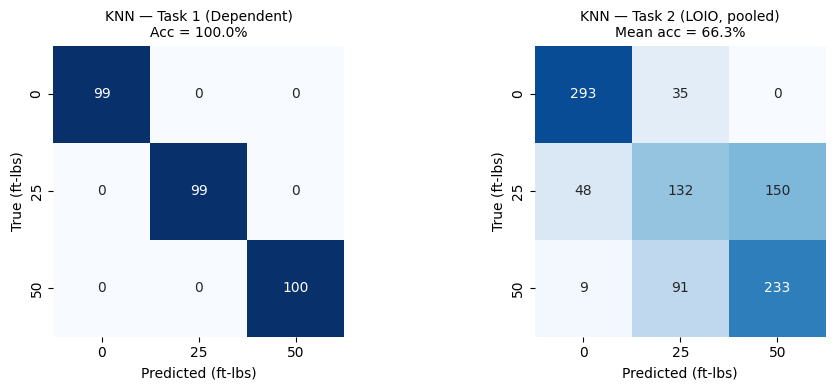

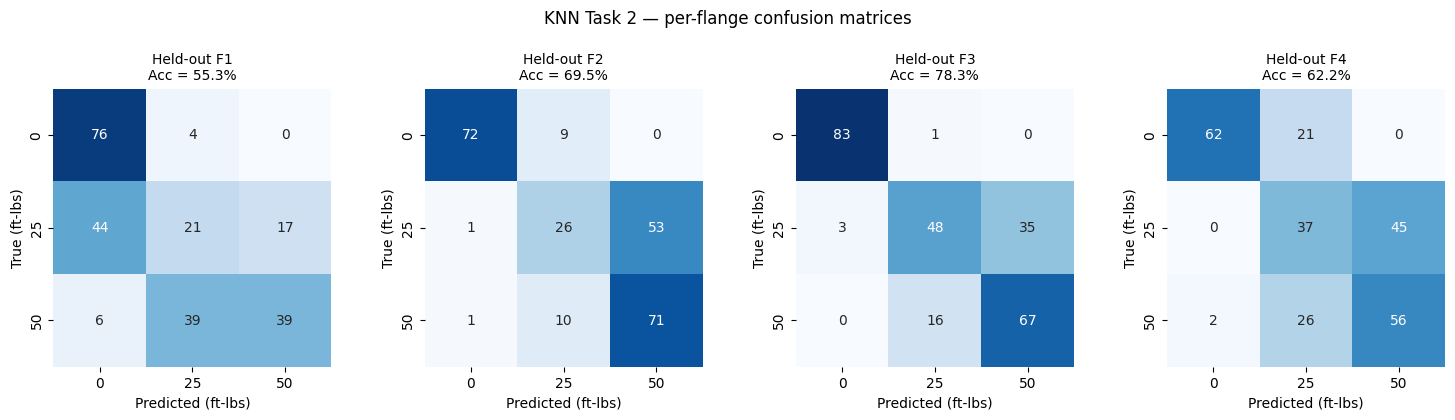


Final model: k=3, metric=manhattan
Saved → model_knn.joblib

✓ knn_results cached — re-run Cell 12 (comparison) and Cell 13 (ensemble)
  with ALL_RESULTS = [svm_results, lr_results, mlp_results, cnn_results,
                       lstm_results, knn_results] to fold KNN in.


In [9]:
# ============================================================
# Cell 16: KNN — 3rd shallow model (extends HW3 lineage)
# ============================================================
# Non-parametric, no implicit distributional assumptions.
# In our HW3/HW4 work, KNN was the most robust shallow model
# to cross-session distribution shift — worth including here
# as a stronger LOIO baseline.
# ============================================================
from sklearn.neighbors import KNeighborsClassifier

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(weights='distance', n_jobs=-1)),
])
knn_grid = {
    'knn__n_neighbors': [3, 5, 7, 11, 15, 21],
    'knn__metric'     : ['euclidean', 'manhattan'],
}

# ============================================================
# TASK 1 — Dependent test
# ============================================================
print("="*64); print("TASK 1 — KNN Dependent test"); print("="*64)
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_feat, y, test_size=0.30, stratify=y, random_state=SEED)

t0 = time.time()
gs1 = GridSearchCV(knn_pipe, knn_grid, cv=5, n_jobs=-1, scoring='accuracy')
gs1.fit(X_tr1, y_tr1)
t_t1 = time.time() - t0

knn_t1     = gs1.best_estimator_
acc_tr1    = knn_t1.score(X_tr1, y_tr1)
acc_te1    = knn_t1.score(X_te1, y_te1)
y_pred_t1  = knn_t1.predict(X_te1)
y_prob_t1  = knn_t1.predict_proba(X_te1)
f1_t1      = f1_score(y_te1, y_pred_t1, average='macro')

print(f"Grid: {t_t1:.1f}s | Best: {gs1.best_params_}")
print(f"Train acc: {acc_tr1*100:.2f}% | Test acc: {acc_te1*100:.2f}% | Macro-F1: {f1_t1:.3f}")
print(classification_report(y_te1, y_pred_t1,
      target_names=[f'{c} ft-lbs' for c in CLASS_LABELS]))

# ============================================================
# TASK 2 — LOIO
# ============================================================
print("="*64); print("TASK 2 — KNN LOIO"); print("="*64)
logo = LeaveOneGroupOut()
fold_records, fold_test_idx = [], []
fold_y_true, fold_y_pred, fold_y_proba = [], [], []

for fold, (tr_idx, te_idx) in enumerate(logo.split(X_feat, y, groups), 1):
    flange_out = int(groups[te_idx[0]])
    X_tr, X_te = X_feat[tr_idx], X_feat[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    gs = GridSearchCV(knn_pipe, knn_grid, cv=5, n_jobs=-1, scoring='accuracy')
    gs.fit(X_tr, y_tr)
    y_p, y_pr = gs.predict(X_te), gs.predict_proba(X_te)

    acc3 = accuracy_score(y_te, y_p)
    f1   = f1_score(y_te, y_p, average='macro')
    accB = accuracy_score((y_te > 0).astype(int), (y_p > 0).astype(int))

    fold_records.append({
        'fold': fold, 'flange_out': flange_out,
        'best_k'     : gs.best_params_['knn__n_neighbors'],
        'best_metric': gs.best_params_['knn__metric'],
        '3class_acc' : acc3, 'binary_acc': accB, 'macro_f1': f1,
    })
    fold_test_idx.append(te_idx); fold_y_true.append(y_te)
    fold_y_pred.append(y_p);      fold_y_proba.append(y_pr)

    print(f"Fold {fold} (F{flange_out}): 3-class={acc3*100:6.2f}% "
          f"Binary={accB*100:6.2f}% F1={f1:.3f} "
          f"k={gs.best_params_['knn__n_neighbors']} "
          f"metric={gs.best_params_['knn__metric']}")

loio_df = pd.DataFrame(fold_records)
mean3, std3 = loio_df['3class_acc'].mean(), loio_df['3class_acc'].std()
meanB, stdB = loio_df['binary_acc'].mean(), loio_df['binary_acc'].std()
print(f"\nLOIO mean: 3-class={mean3*100:.2f}%±{std3*100:.2f}% | "
      f"Binary={meanB*100:.2f}%±{stdB*100:.2f}% | F1={loio_df['macro_f1'].mean():.3f}")

# ============================================================
# Confusion matrices
# ============================================================
y_true_pooled = np.concatenate(fold_y_true)
y_pred_pooled = np.concatenate(fold_y_pred)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion(y_te1, y_pred_t1,
               f'KNN — Task 1 (Dependent)\nAcc = {acc_te1*100:.1f}%', ax=axes[0])
plot_confusion(y_true_pooled, y_pred_pooled,
               f'KNN — Task 2 (LOIO, pooled)\nMean acc = {mean3*100:.1f}%', ax=axes[1])
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for k, ax in enumerate(axes):
    fd = fold_records[k]
    plot_confusion(fold_y_true[k], fold_y_pred[k],
                   f"Held-out F{fd['flange_out']}\nAcc = {fd['3class_acc']*100:.1f}%", ax=ax)
plt.suptitle('KNN Task 2 — per-flange confusion matrices', y=1.04)
plt.tight_layout(); plt.show()

# ============================================================
# Final KNN trained on ALL 991 hits
# ============================================================
hp_votes = Counter([(r['best_k'], r['best_metric']) for r in fold_records])
final_k, final_metric = hp_votes.most_common(1)[0][0]

knn_final = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=final_k, metric=final_metric,
                                  weights='distance', n_jobs=-1)),
]).fit(X_feat, y)
dump(knn_final, os.path.join(OUTPUT_DIR, 'model_knn.joblib'))
print(f"\nFinal model: k={final_k}, metric={final_metric}")
print(f"Saved → model_knn.joblib")

# Cache for ensemble compatibility
knn_results = {
    'name': 'KNN',
    'task1_test_acc' : acc_te1, 'task1_train_acc' : acc_tr1,
    'task1_macro_f1' : f1_t1,
    'task1_y_test'   : y_te1,   'task1_y_pred' : y_pred_t1,
    'task1_y_proba'  : y_prob_t1,
    'task2_mean_acc' : mean3,   'task2_mean_bin'  : meanB,
    'task2_mean_f1'  : loio_df['macro_f1'].mean(),
    'task2_per_fold' : loio_df,
    'task2_test_idx' : fold_test_idx,
    'task2_y_true'   : fold_y_true,
    'task2_y_pred'   : fold_y_pred,
    'task2_y_proba'  : fold_y_proba,
    'final_model'    : knn_final,
    'final_hp'       : {'k': final_k, 'metric': final_metric},
}
print("\n✓ knn_results cached — re-run Cell 12 (comparison) and Cell 13 (ensemble)")
print("  with ALL_RESULTS = [svm_results, lr_results, mlp_results, cnn_results,")
print("                       lstm_results, knn_results] to fold KNN in.")

TASK 1 — Dependent test  (70/30 stratified split)
Trained in 49.6 s (147 epochs, early-stopped)
Train acc : 100.00%
Test  acc :  99.66%   Macro-F1: 0.997

Per-class breakdown (test):
              precision    recall  f1-score   support

    0 ft-lbs       1.00      1.00      1.00        99
   25 ft-lbs       1.00      0.99      0.99        99
   50 ft-lbs       0.99      1.00      1.00       100

    accuracy                           1.00       298
   macro avg       1.00      1.00      1.00       298
weighted avg       1.00      1.00      1.00       298



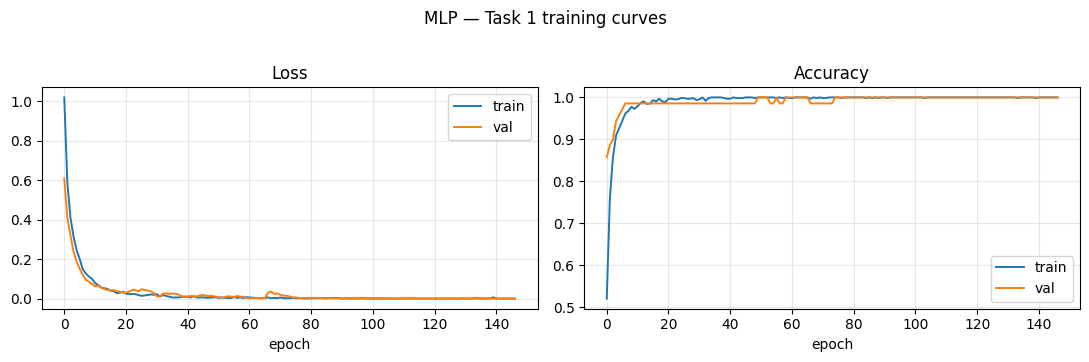

TASK 2 — Independent test  (Leave-One-Flange-Out)
Fold 1: Train=[2, 3, 4] → Test=[1]   3-class= 76.83%   Binary= 88.21%   F1=0.765   epochs=61


Fold 2: Train=[1, 3, 4] → Test=[2]   3-class= 60.08%   Binary= 87.65%   F1=0.565   epochs=49


Fold 3: Train=[1, 2, 4] → Test=[3]   3-class= 90.91%   Binary= 98.42%   F1=0.909   epochs=81
Fold 4: Train=[1, 2, 3] → Test=[4]   3-class= 77.11%   Binary= 92.77%   F1=0.778   epochs=58

LOIO mean : 3-class = 76.23% ± 12.61%
            Binary  = 91.76% ± 4.99%
            Macro-F1 = 0.754
Total LOIO time: 129.6 s


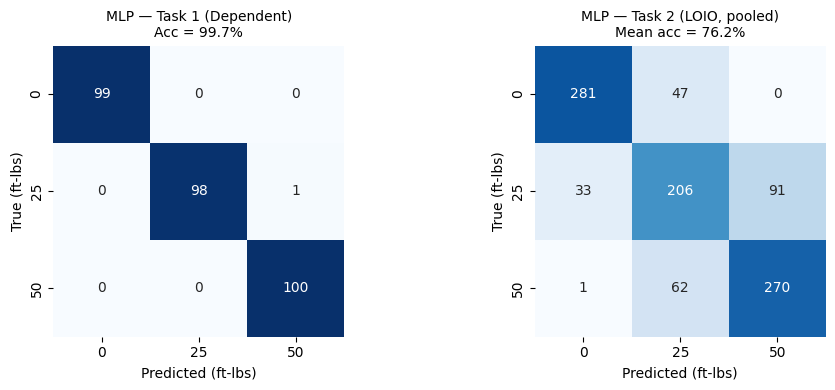

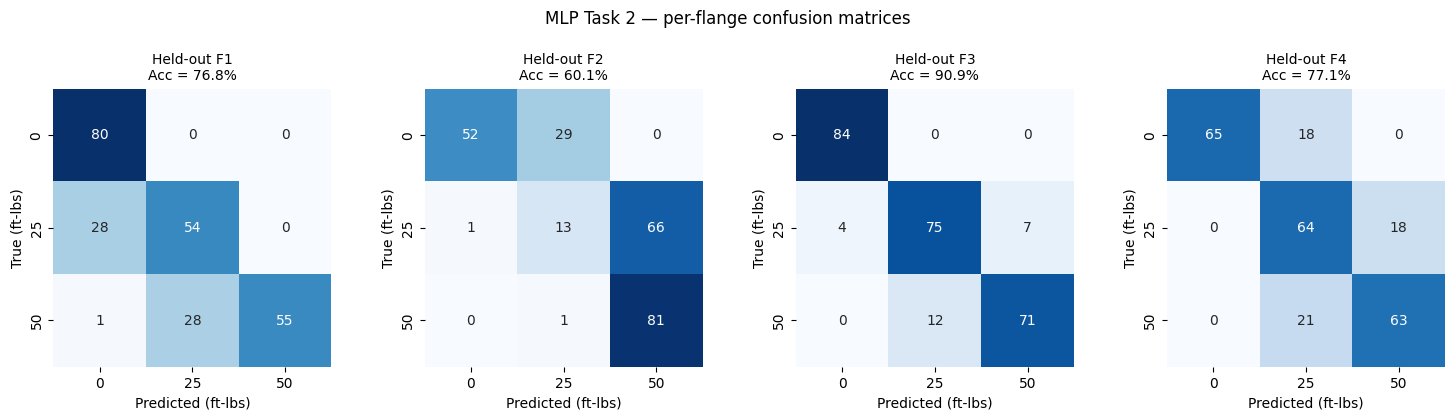


Training final MLP on all 991 hits (with internal val split for early stopping)...
✓ Saved → /content/drive/MyDrive/ML_Project_2026/model_mlp.keras
✓ Saved → /content/drive/MyDrive/ML_Project_2026/scaler_mlp.joblib

✓ mlp_results cached for Cells 11 (comparison) and 12 (ensemble)


In [10]:
# ============================================================
# Cell 9: MLP (3 hidden layers) — Task 1 + Task 2
# ============================================================
# Same 82-dim input as SVM/LR. The hypothesis: a non-linear net
# might find structure linear models can't. Heavy dropout/BN
# because we have only ~720 train samples per LOIO fold.
# ============================================================

# ============================================================
# Architecture builder (from master plan)
# ============================================================
def build_mlp(input_dim=82, n_classes=N_CLASSES, seed=SEED):
    tf.keras.utils.set_random_seed(seed)
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256), layers.BatchNormalization(),
        layers.Activation('relu'), layers.Dropout(0.40),

        layers.Dense(128), layers.BatchNormalization(),
        layers.Activation('relu'), layers.Dropout(0.35),

        layers.Dense(64),  layers.BatchNormalization(),
        layers.Activation('relu'), layers.Dropout(0.25),

        layers.Dense(n_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',     # accepts integer labels
        metrics=['accuracy'],
    )
    return model

# ============================================================
# Train + predict helper (used by both Task 1 and Task 2)
# ============================================================
def train_mlp(X_train, y_train, X_test, y_test, val_frac=0.1, verbose=0):
    """Fit StandardScaler on train, train MLP with internal val split for early
    stopping, return (model, scaler, y_pred, y_proba, train_acc, history)."""
    # 1) carve a validation slice off the training data for early stopping
    Xtr_in, Xval, ytr_in, yval = train_test_split(
        X_train, y_train, test_size=val_frac, stratify=y_train, random_state=SEED
    )
    # 2) standardize using train-only statistics
    scaler = StandardScaler().fit(Xtr_in)
    Xtr_s, Xval_s, Xte_s = scaler.transform(Xtr_in), scaler.transform(Xval), scaler.transform(X_test)

    # 3) build & fit
    model = build_mlp(input_dim=Xtr_s.shape[1])
    cbs = [
        callbacks.EarlyStopping(monitor='val_loss', patience=30,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=10, min_lr=1e-6, verbose=0),
    ]
    history = model.fit(
        Xtr_s, ytr_in,
        validation_data=(Xval_s, yval),
        epochs=200, batch_size=32, verbose=verbose, callbacks=cbs,
    )
    # 4) predictions on the held-out test set
    y_proba   = model.predict(Xte_s, verbose=0)
    y_pred    = y_proba.argmax(axis=1)
    train_acc = model.evaluate(Xtr_s, ytr_in, verbose=0)[1]
    return model, scaler, y_pred, y_proba, train_acc, history

# ============================================================
# TASK 1 — Dependent test (same 70/30 split as SVM/LR)
# ============================================================
print("="*64)
print("TASK 1 — Dependent test  (70/30 stratified split)")
print("="*64)

X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_feat, y, test_size=0.30, stratify=y, random_state=SEED
)

t0 = time.time()
mlp_model_t1, mlp_scaler_t1, y_pred_t1, y_prob_t1, acc_tr1, hist_t1 = \
    train_mlp(X_tr1, y_tr1, X_te1, y_te1)
t_t1 = time.time() - t0

acc_te1 = accuracy_score(y_te1, y_pred_t1)
f1_t1   = f1_score(y_te1, y_pred_t1, average='macro')
n_epochs = len(hist_t1.history['loss'])

print(f"Trained in {t_t1:.1f} s ({n_epochs} epochs, early-stopped)")
print(f"Train acc : {acc_tr1*100:6.2f}%")
print(f"Test  acc : {acc_te1*100:6.2f}%   Macro-F1: {f1_t1:.3f}")
print("\nPer-class breakdown (test):")
print(classification_report(y_te1, y_pred_t1,
                            target_names=[f'{c} ft-lbs' for c in CLASS_LABELS]))

# Plot the training curves so we can sanity-check overfitting
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(hist_t1.history['loss'], label='train', lw=1.4)
axes[0].plot(hist_t1.history['val_loss'], label='val', lw=1.4)
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(hist_t1.history['accuracy'], label='train', lw=1.4)
axes[1].plot(hist_t1.history['val_accuracy'], label='val', lw=1.4)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(alpha=.3)
plt.suptitle('MLP — Task 1 training curves', y=1.02); plt.tight_layout(); plt.show()

# ============================================================
# TASK 2 — LOIO over 4 flanges
# ============================================================
print("="*64)
print("TASK 2 — Independent test  (Leave-One-Flange-Out)")
print("="*64)

logo = LeaveOneGroupOut()
fold_records  = []
fold_test_idx = []
fold_y_true   = []
fold_y_pred   = []
fold_y_proba  = []

t0 = time.time()
for fold, (tr_idx, te_idx) in enumerate(logo.split(X_feat, y, groups), 1):
    flange_out    = int(groups[te_idx[0]])
    train_flanges = sorted(set([1, 2, 3, 4]) - {flange_out})
    X_tr, X_te    = X_feat[tr_idx], X_feat[te_idx]
    y_tr, y_te    = y[tr_idx], y[te_idx]

    _, _, y_p, y_pr, _, hist = train_mlp(X_tr, y_tr, X_te, y_te)

    acc3 = accuracy_score(y_te, y_p)
    f1   = f1_score(y_te, y_p, average='macro')
    accB = accuracy_score((y_te > 0).astype(int), (y_p > 0).astype(int))

    fold_records.append({
        'fold': fold, 'flange_out': flange_out,
        'epochs':     len(hist.history['loss']),
        '3class_acc': acc3, 'binary_acc': accB, 'macro_f1': f1,
    })
    fold_test_idx.append(te_idx)
    fold_y_true.append(y_te); fold_y_pred.append(y_p); fold_y_proba.append(y_pr)

    print(f"Fold {fold}: Train={train_flanges} → Test=[{flange_out}]   "
          f"3-class={acc3*100:6.2f}%   Binary={accB*100:6.2f}%   "
          f"F1={f1:.3f}   epochs={len(hist.history['loss'])}")

t_t2  = time.time() - t0
loio_df = pd.DataFrame(fold_records)
mean3 = loio_df['3class_acc'].mean();  std3 = loio_df['3class_acc'].std()
meanB = loio_df['binary_acc'].mean();  stdB = loio_df['binary_acc'].std()

print(f"\nLOIO mean : 3-class = {mean3*100:.2f}% ± {std3*100:.2f}%")
print(f"            Binary  = {meanB*100:.2f}% ± {stdB*100:.2f}%")
print(f"            Macro-F1 = {loio_df['macro_f1'].mean():.3f}")
print(f"Total LOIO time: {t_t2:.1f} s")

# ============================================================
# Confusion matrices
# ============================================================
y_true_pooled = np.concatenate(fold_y_true)
y_pred_pooled = np.concatenate(fold_y_pred)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion(y_te1, y_pred_t1,
               f'MLP — Task 1 (Dependent)\nAcc = {acc_te1*100:.1f}%', ax=axes[0])
plot_confusion(y_true_pooled, y_pred_pooled,
               f'MLP — Task 2 (LOIO, pooled)\nMean acc = {mean3*100:.1f}%', ax=axes[1])
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for k, ax in enumerate(axes):
    fold = fold_records[k]
    plot_confusion(fold_y_true[k], fold_y_pred[k],
                   f"Held-out F{fold['flange_out']}\nAcc = {fold['3class_acc']*100:.1f}%",
                   ax=ax)
plt.suptitle('MLP Task 2 — per-flange confusion matrices', y=1.04)
plt.tight_layout(); plt.show()

# ============================================================
# Final MLP trained on ALL 991 hits (for ensemble + Task 3)
# ============================================================
print("\nTraining final MLP on all 991 hits (with internal val split for early stopping)...")
mlp_final_scaler = StandardScaler().fit(X_feat)
X_all_s          = mlp_final_scaler.transform(X_feat)
Xtr_f, Xval_f, ytr_f, yval_f = train_test_split(
    X_all_s, y, test_size=0.10, stratify=y, random_state=SEED
)
mlp_final = build_mlp()
cbs = [
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, verbose=0),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=10, min_lr=1e-6, verbose=0),
]
mlp_final.fit(Xtr_f, ytr_f, validation_data=(Xval_f, yval_f),
              epochs=200, batch_size=32, verbose=0, callbacks=cbs)
mlp_final.save(os.path.join(OUTPUT_DIR, 'model_mlp.keras'))
dump(mlp_final_scaler, os.path.join(OUTPUT_DIR, 'scaler_mlp.joblib'))
print(f"✓ Saved → {os.path.join(OUTPUT_DIR, 'model_mlp.keras')}")
print(f"✓ Saved → {os.path.join(OUTPUT_DIR, 'scaler_mlp.joblib')}")

# ============================================================
# Cache for ensemble (Cell 12) and comparison table (Cell 11)
# ============================================================
mlp_results = {
    'name'            : 'MLP',
    'task1_test_acc'  : acc_te1,
    'task1_train_acc' : acc_tr1,
    'task1_macro_f1'  : f1_t1,
    'task1_y_test'    : y_te1,
    'task1_y_pred'    : y_pred_t1,
    'task1_y_proba'   : y_prob_t1,
    'task2_mean_acc'  : mean3,
    'task2_mean_bin'  : meanB,
    'task2_mean_f1'   : loio_df['macro_f1'].mean(),
    'task2_per_fold'  : loio_df,
    'task2_test_idx'  : fold_test_idx,
    'task2_y_true'    : fold_y_true,
    'task2_y_pred'    : fold_y_pred,
    'task2_y_proba'   : fold_y_proba,
    'final_model'     : mlp_final,
    'final_scaler'    : mlp_final_scaler,
}
print("\n✓ mlp_results cached for Cells 11 (comparison) and 12 (ensemble)")

TensorFlow version: 2.20.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU setup error: Physical devices cannot be modified after being initialized


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)        │ (None, 64, 128, 1)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d (Conv2D)                   │ (None, 64, 128, 32)      │           320 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_18            │ (None, 64, 128, 32)      │           128 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_18 (Activation)        │ (None, 64, 128, 32)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)      │ (None, 32, 64, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)                 │ (None, 32, 64, 64)       │        18,496 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_19            │ (None, 32, 64, 64)       │           256 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_19 (Activation)        │ (None, 32, 64, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)    │ (None, 16, 32, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)                 │ (None, 16, 32, 128)      │        73,856 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_20            │ (None, 16, 32, 128)      │           512 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_20 (Activation)        │ (None, 16, 32, 128)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)    │ (None, 8, 16, 128)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)                 │ (None, 8, 16, 128)       │       147,584 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_21            │ (None, 8, 16, 128)       │           512 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_21 (Activation)        │ (None, 8, 16, 128)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 128)              │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_24 (Dense)                  │ (None, 128)              │        16,512 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_18 (Dropout)              │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_25 (Dense)                  │ (None, 3)                │           387 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 258,563 (1010.01 KB)

 Trainable params: 257,859 (1007.26 KB)

 Non-trainable params: 704 (2.75 KB)

TASK 1 — Dependent test  (70/30 stratified split)
Train: 693 samples,  Test: 298 samples
Trained in 37.3 s (69 epochs, early-stopped)
Train acc : 100.00%
Test  acc : 100.00%   Macro-F1: 1.000

Per-class breakdown (test):
              precision    recall  f1-score   support

    0 ft-lbs       1.00      1.00      1.00        99
   25 ft-lbs       1.00      1.00      1.00        99
   50 ft-lbs       1.00      1.00      1.00       100

    accuracy                           1.00       298
   macro avg       1.00      1.00      1.00       298
weighted avg       1.00      1.00      1.00       298



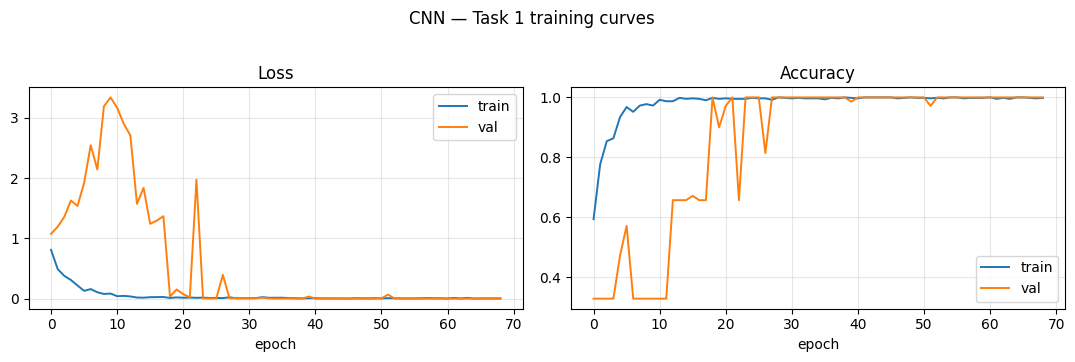

TASK 2 — Independent test  (Leave-One-Flange-Out)
Fold 1: Train=[2, 3, 4] → Test=[1]   3-class= 71.14%   Binary= 99.59%   F1=0.658   epochs=100
Fold 2: Train=[1, 3, 4] → Test=[2]   3-class= 66.67%   Binary=100.00%   F1=0.659   epochs=100
Fold 3: Train=[1, 2, 4] → Test=[3]   3-class= 79.05%   Binary=100.00%   F1=0.788   epochs=100
Fold 4: Train=[1, 2, 3] → Test=[4]   3-class= 55.02%   Binary=100.00%   F1=0.516   epochs=100

LOIO mean : 3-class = 67.97% ± 10.04%
            Binary  = 99.90% ± 0.20%
            Macro-F1 = 0.655
Total LOIO time: 158.9 s


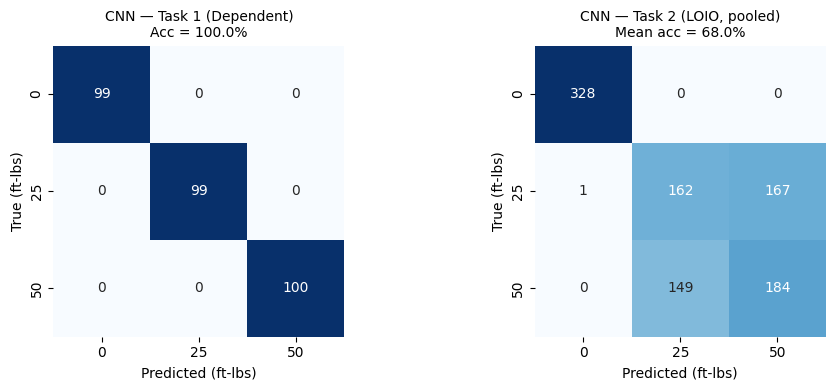

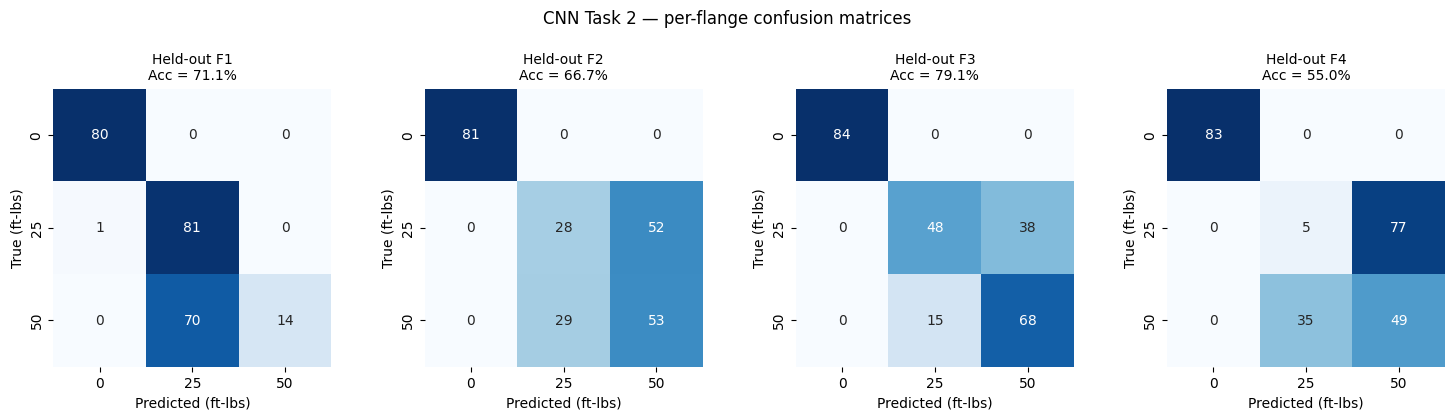


Training final CNN on all 991 hits...
✓ Saved → /content/drive/MyDrive/ML_Project_2026/model_cnn.keras

✓ cnn_results cached for Cells 11 (comparison) and 12 (ensemble)


In [11]:
# ============================================================
# Cell 10: CNN on log-mel spectrograms — Task 1 + Task 2
# GPU-enabled version
# ============================================================
# Input: (64, 128, 1) log-mel spectrogram (already standardized)
# Output: 3-class softmax
# Augmentation (time/freq masking + Gaussian noise) only on training
# data — applied via tf.data pipeline.
# ============================================================

# ============================================================
# GPU setup
# ============================================================
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs detected:", gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as e:
        print("GPU setup error:", e)
else:
    print("No GPU detected. Training will run on CPU.")

# Use a larger batch size for GPU training
BATCH_SIZE = 32


# ============================================================
# Architecture
# ============================================================
def build_cnn(input_shape=(N_MELS, SPEC_TIME_FRAMES, 1),
              n_classes=N_CLASSES, seed=SEED):
    tf.keras.utils.set_random_seed(seed)

    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.50)(x)

    out = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inp, out)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    return model


# Print architecture once for sanity
build_cnn().summary(line_length=80)


# ============================================================
# SpecAugment + noise — applied only during training
# ============================================================
def augment_spec(spec, label):
    """
    spec: (64, 128, 1) tensor.
    Apply augmentations stochastically.
    """

    # Gaussian noise
    if tf.random.uniform([]) < 0.5:
        spec = spec + tf.random.normal(
            tf.shape(spec),
            mean=0.0,
            stddev=0.10
        )

    # Frequency masking — mask up to 4 mel bins
    if tf.random.uniform([]) < 0.5:
        f = tf.random.uniform([], 1, 5, dtype=tf.int32)
        f0 = tf.random.uniform([], 0, N_MELS - f, dtype=tf.int32)

        mask = tf.concat([
            tf.ones([f0, SPEC_TIME_FRAMES, 1]),
            tf.zeros([f, SPEC_TIME_FRAMES, 1]),
            tf.ones([N_MELS - f0 - f, SPEC_TIME_FRAMES, 1]),
        ], axis=0)

        spec = spec * mask

    # Time masking — mask up to 8 frames
    if tf.random.uniform([]) < 0.5:
        t = tf.random.uniform([], 1, 9, dtype=tf.int32)
        t0 = tf.random.uniform([], 0, SPEC_TIME_FRAMES - t, dtype=tf.int32)

        mask = tf.concat([
            tf.ones([N_MELS, t0, 1]),
            tf.zeros([N_MELS, t, 1]),
            tf.ones([N_MELS, SPEC_TIME_FRAMES - t0 - t, 1]),
        ], axis=1)

        spec = spec * mask

    return spec, label


def make_dataset(X, y_lab, batch_size=BATCH_SIZE, augment=False, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y_lab))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(X),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    if augment:
        ds = ds.map(
            augment_spec,
            num_parallel_calls=tf.data.AUTOTUNE
        )

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


# ============================================================
# Train + predict helper
# ============================================================
def train_cnn(X_train, y_train, X_test, y_test,
              val_frac=0.1, verbose=0, batch_size=BATCH_SIZE):

    Xtr_in, Xval, ytr_in, yval = train_test_split(
        X_train,
        y_train,
        test_size=val_frac,
        stratify=y_train,
        random_state=SEED
    )

    train_ds = make_dataset(
        Xtr_in,
        ytr_in,
        batch_size=batch_size,
        augment=True,
        shuffle=True
    )

    val_ds = make_dataset(
        Xval,
        yval,
        batch_size=batch_size,
        augment=False,
        shuffle=False
    )

    model = build_cnn()

    cbs = [
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=0
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=8,
            min_lr=1e-6,
            verbose=0
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        verbose=verbose,
        callbacks=cbs
    )

    y_proba = model.predict(X_test, verbose=0)
    y_pred = y_proba.argmax(axis=1)

    # This can also use the GPU automatically
    train_acc = model.evaluate(Xtr_in, ytr_in, verbose=0)[1]

    return model, y_pred, y_proba, train_acc, history


# ============================================================
# TASK 1 — Dependent test
# ============================================================
print("=" * 64)
print("TASK 1 — Dependent test  (70/30 stratified split)")
print("=" * 64)

idx_all = np.arange(len(y))

idx_tr1, idx_te1 = train_test_split(
    idx_all,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

X_tr1, X_te1 = X_spec[idx_tr1], X_spec[idx_te1]
y_tr1, y_te1 = y[idx_tr1], y[idx_te1]

print(f"Train: {len(y_tr1)} samples,  Test: {len(y_te1)} samples")

t0 = time.time()

cnn_t1, y_pred_t1, y_prob_t1, acc_tr1, hist_t1 = train_cnn(
    X_tr1,
    y_tr1,
    X_te1,
    y_te1,
    verbose=0,
    batch_size=BATCH_SIZE
)

t_t1 = time.time() - t0

acc_te1 = accuracy_score(y_te1, y_pred_t1)
f1_t1 = f1_score(y_te1, y_pred_t1, average='macro')
n_epochs = len(hist_t1.history['loss'])

print(f"Trained in {t_t1:.1f} s ({n_epochs} epochs, early-stopped)")
print(f"Train acc : {acc_tr1 * 100:6.2f}%")
print(f"Test  acc : {acc_te1 * 100:6.2f}%   Macro-F1: {f1_t1:.3f}")

print("\nPer-class breakdown (test):")
print(classification_report(
    y_te1,
    y_pred_t1,
    target_names=[f'{c} ft-lbs' for c in CLASS_LABELS]
))


# Training curves
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(hist_t1.history['loss'], label='train', lw=1.4)
axes[0].plot(hist_t1.history['val_loss'], label='val', lw=1.4)
axes[0].set_title('Loss')
axes[0].set_xlabel('epoch')
axes[0].legend()
axes[0].grid(alpha=.3)

axes[1].plot(hist_t1.history['accuracy'], label='train', lw=1.4)
axes[1].plot(hist_t1.history['val_accuracy'], label='val', lw=1.4)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('epoch')
axes[1].legend()
axes[1].grid(alpha=.3)

plt.suptitle('CNN — Task 1 training curves', y=1.02)
plt.tight_layout()
plt.show()


# ============================================================
# TASK 2 — LOIO over 4 flanges
# ============================================================
print("=" * 64)
print("TASK 2 — Independent test  (Leave-One-Flange-Out)")
print("=" * 64)

logo = LeaveOneGroupOut()

fold_records = []
fold_test_idx = []
fold_y_true = []
fold_y_pred = []
fold_y_proba = []

t0 = time.time()

for fold, (tr_idx, te_idx) in enumerate(logo.split(X_spec, y, groups), 1):

    flange_out = int(groups[te_idx[0]])
    train_flanges = sorted(set([1, 2, 3, 4]) - {flange_out})

    X_tr, X_te = X_spec[tr_idx], X_spec[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    _, y_p, y_pr, _, hist = train_cnn(
        X_tr,
        y_tr,
        X_te,
        y_te,
        verbose=0,
        batch_size=BATCH_SIZE
    )

    acc3 = accuracy_score(y_te, y_p)
    f1 = f1_score(y_te, y_p, average='macro')

    accB = accuracy_score(
        (y_te > 0).astype(int),
        (y_p > 0).astype(int)
    )

    fold_records.append({
        'fold': fold,
        'flange_out': flange_out,
        'epochs': len(hist.history['loss']),
        '3class_acc': acc3,
        'binary_acc': accB,
        'macro_f1': f1,
    })

    fold_test_idx.append(te_idx)
    fold_y_true.append(y_te)
    fold_y_pred.append(y_p)
    fold_y_proba.append(y_pr)

    print(
        f"Fold {fold}: Train={train_flanges} → Test=[{flange_out}]   "
        f"3-class={acc3 * 100:6.2f}%   Binary={accB * 100:6.2f}%   "
        f"F1={f1:.3f}   epochs={len(hist.history['loss'])}"
    )


t_t2 = time.time() - t0

loio_df = pd.DataFrame(fold_records)

mean3 = loio_df['3class_acc'].mean()
std3 = loio_df['3class_acc'].std()

meanB = loio_df['binary_acc'].mean()
stdB = loio_df['binary_acc'].std()

print(f"\nLOIO mean : 3-class = {mean3 * 100:.2f}% ± {std3 * 100:.2f}%")
print(f"            Binary  = {meanB * 100:.2f}% ± {stdB * 100:.2f}%")
print(f"            Macro-F1 = {loio_df['macro_f1'].mean():.3f}")
print(f"Total LOIO time: {t_t2:.1f} s")


# ============================================================
# Confusion matrices
# ============================================================
y_true_pooled = np.concatenate(fold_y_true)
y_pred_pooled = np.concatenate(fold_y_pred)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_confusion(
    y_te1,
    y_pred_t1,
    f'CNN — Task 1 (Dependent)\nAcc = {acc_te1 * 100:.1f}%',
    ax=axes[0]
)

plot_confusion(
    y_true_pooled,
    y_pred_pooled,
    f'CNN — Task 2 (LOIO, pooled)\nMean acc = {mean3 * 100:.1f}%',
    ax=axes[1]
)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))

for k, ax in enumerate(axes):
    fold = fold_records[k]

    plot_confusion(
        fold_y_true[k],
        fold_y_pred[k],
        f"Held-out F{fold['flange_out']}\nAcc = {fold['3class_acc'] * 100:.1f}%",
        ax=ax
    )

plt.suptitle('CNN Task 2 — per-flange confusion matrices', y=1.04)
plt.tight_layout()
plt.show()


# ============================================================
# Final CNN trained on ALL 991 hits
# ============================================================
print("\nTraining final CNN on all 991 hits...")

idx_tr_f, idx_va_f = train_test_split(
    np.arange(len(y)),
    test_size=0.10,
    stratify=y,
    random_state=SEED
)

train_ds_f = make_dataset(
    X_spec[idx_tr_f],
    y[idx_tr_f],
    batch_size=BATCH_SIZE,
    augment=True,
    shuffle=True
)

val_ds_f = make_dataset(
    X_spec[idx_va_f],
    y[idx_va_f],
    batch_size=BATCH_SIZE,
    augment=False,
    shuffle=False
)

cnn_final = build_cnn()

cbs = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=0
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=0
    ),
]

cnn_final.fit(
    train_ds_f,
    validation_data=val_ds_f,
    epochs=100,
    verbose=0,
    callbacks=cbs
)

cnn_final.save(os.path.join(OUTPUT_DIR, 'model_cnn.keras'))

print(f"✓ Saved → {os.path.join(OUTPUT_DIR, 'model_cnn.keras')}")


# ============================================================
# Cache for ensemble and comparison
# ============================================================
cnn_results = {
    'name': 'CNN',

    'task1_test_acc': acc_te1,
    'task1_train_acc': acc_tr1,
    'task1_macro_f1': f1_t1,
    'task1_y_test': y_te1,
    'task1_y_pred': y_pred_t1,
    'task1_y_proba': y_prob_t1,

    'task2_mean_acc': mean3,
    'task2_mean_bin': meanB,
    'task2_mean_f1': loio_df['macro_f1'].mean(),
    'task2_per_fold': loio_df,
    'task2_test_idx': fold_test_idx,
    'task2_y_true': fold_y_true,
    'task2_y_pred': fold_y_pred,
    'task2_y_proba': fold_y_proba,

    'final_model': cnn_final,
}

print("\n✓ cnn_results cached for Cells 11 (comparison) and 12 (ensemble)")

X_seq shape: (991, 128, 64)  (samples, timesteps, features)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)     │ (None, 128, 128)         │        66,048 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_46            │ (None, 128, 128)         │           512 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_25 (Dropout)              │ (None, 128, 128)         │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional)   │ (None, 64)               │        41,216 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_47            │ (None, 64)               │           256 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_26 (Dropout)              │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_38 (Dense)                  │ (None, 32)               │         2,080 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_27 (Dropout)              │ (None, 32)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_39 (Dense)                  │ (None, 3)                │            99 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 110,211 (430.51 KB)

 Trainable params: 109,827 (429.01 KB)

 Non-trainable params: 384 (1.50 KB)

TASK 1 — Dependent test  (70/30 stratified split)
Train: 693 samples,  Test: 298 samples
Trained in 55.6 s (80 epochs, early-stopped)
Train acc : 100.00%
Test  acc :  98.99%   Macro-F1: 0.990

Per-class breakdown (test):
              precision    recall  f1-score   support

    0 ft-lbs       1.00      0.99      0.99        99
   25 ft-lbs       0.97      1.00      0.99        99
   50 ft-lbs       1.00      0.98      0.99       100

    accuracy                           0.99       298
   macro avg       0.99      0.99      0.99       298
weighted avg       0.99      0.99      0.99       298



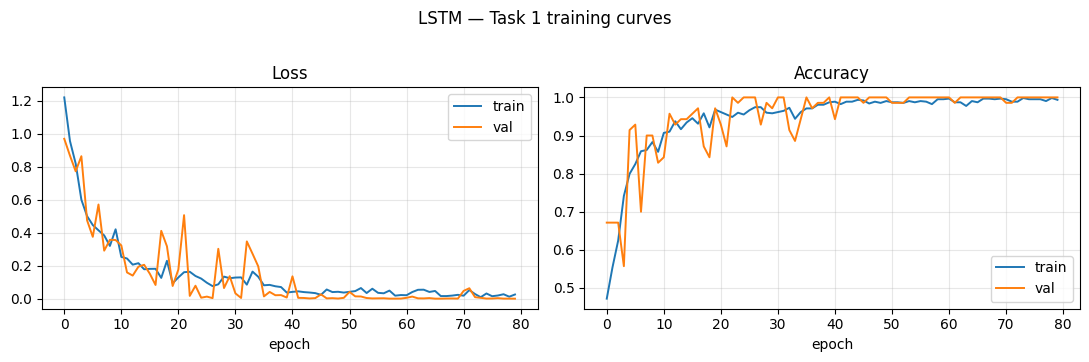

TASK 2 — Independent test  (Leave-One-Flange-Out)
Fold 1: Train=[2, 3, 4] → Test=[1]   3-class= 80.49%   Binary= 91.46%   F1=0.803   epochs=44
Fold 2: Train=[1, 3, 4] → Test=[2]   3-class= 74.07%   Binary= 98.77%   F1=0.704   epochs=59
Fold 3: Train=[1, 2, 4] → Test=[3]   3-class= 84.98%   Binary=100.00%   F1=0.846   epochs=80
Fold 4: Train=[1, 2, 3] → Test=[4]   3-class= 92.77%   Binary=100.00%   F1=0.927   epochs=74

LOIO mean : 3-class = 83.08% ± 7.86%
            Binary  = 97.56% ± 4.10%
            Macro-F1 = 0.820
Total LOIO time: 183.2 s


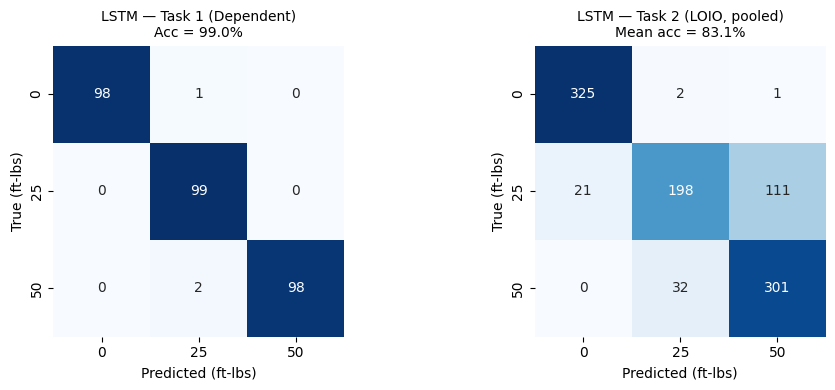

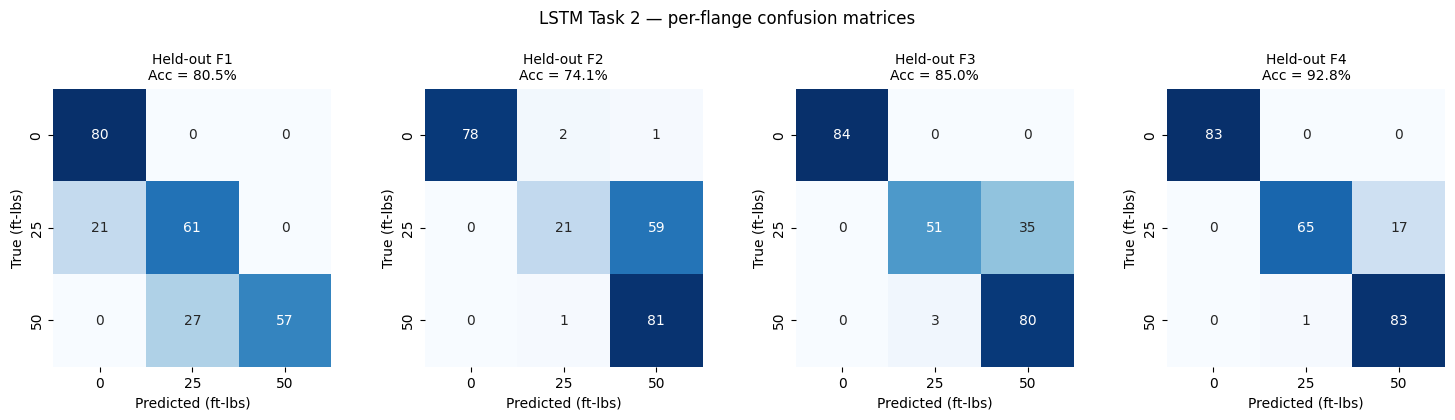


Training final LSTM on all 991 hits...
✓ Saved → /content/drive/MyDrive/ML_Project_2026/model_lstm.keras

✓ lstm_results cached


In [12]:
# ============================================================
# Cell 11: Bidirectional LSTM on mel-spec sequences
# ============================================================
# Input: (128, 64) — 128 time frames × 64 mel features per frame
# Same data as CNN, but processed sequentially. The LSTM's
# inductive bias = "carry hidden state forward through time"
# directly matches the physics of decay.
# ============================================================

# ============================================================
# Reshape spectrogram tensor → sequence form
# ============================================================
# X_spec shape : (N, 64,  128, 1)  — CNN view (channels-last 2D)
# X_seq shape  : (N, 128, 64)      — LSTM view (T timesteps × F features)
X_seq = X_spec[..., 0].transpose(0, 2, 1).astype(np.float32)
print(f"X_seq shape: {X_seq.shape}  (samples, timesteps, features)")

# ============================================================
# Architecture
# ============================================================
def build_lstm(input_shape=(SPEC_TIME_FRAMES, N_MELS),
               n_classes=N_CLASSES, seed=SEED):
    tf.keras.utils.set_random_seed(seed)
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.BatchNormalization(),
        layers.Dropout(0.40),

        layers.Bidirectional(layers.LSTM(32)),
        layers.BatchNormalization(),
        layers.Dropout(0.30),

        layers.Dense(32, activation='relu'),
        layers.Dropout(0.20),

        layers.Dense(n_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

build_lstm().summary(line_length=80)

# ============================================================
# Augmentation — adapted to (T, F) shape (no channel dim)
# ============================================================
def augment_seq(seq, label):
    # Gaussian noise
    if tf.random.uniform([]) < 0.5:
        seq = seq + tf.random.normal(tf.shape(seq), 0.0, 0.10)
    # Frequency masking — along last axis (mel features)
    if tf.random.uniform([]) < 0.5:
        f  = tf.random.uniform([], 1, 5, dtype=tf.int32)
        f0 = tf.random.uniform([], 0, N_MELS - f, dtype=tf.int32)
        mask = tf.concat([
            tf.ones([SPEC_TIME_FRAMES, f0]),
            tf.zeros([SPEC_TIME_FRAMES, f]),
            tf.ones([SPEC_TIME_FRAMES, N_MELS - f0 - f]),
        ], axis=1)
        seq = seq * mask
    # Time masking — along first axis (timesteps)
    if tf.random.uniform([]) < 0.5:
        t  = tf.random.uniform([], 1, 9, dtype=tf.int32)
        t0 = tf.random.uniform([], 0, SPEC_TIME_FRAMES - t, dtype=tf.int32)
        mask = tf.concat([
            tf.ones([t0, N_MELS]),
            tf.zeros([t, N_MELS]),
            tf.ones([SPEC_TIME_FRAMES - t0 - t, N_MELS]),
        ], axis=0)
        seq = seq * mask
    return seq, label

def make_seq_dataset(X, y_lab, batch_size=32, augment=False, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y_lab))
    if shuffle:
        ds = ds.shuffle(len(X), seed=SEED, reshuffle_each_iteration=True)
    if augment:
        ds = ds.map(augment_seq, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# ============================================================
# Train + predict helper
# ============================================================
def train_lstm(X_train, y_train, X_test, y_test,
               val_frac=0.1, verbose=0, batch_size=32):
    Xtr_in, Xval, ytr_in, yval = train_test_split(
        X_train, y_train, test_size=val_frac,
        stratify=y_train, random_state=SEED
    )
    train_ds = make_seq_dataset(Xtr_in, ytr_in, batch_size, augment=True,  shuffle=True)
    val_ds   = make_seq_dataset(Xval,   yval,   batch_size, augment=False, shuffle=False)

    model = build_lstm()
    cbs = [
        callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=8, min_lr=1e-6, verbose=0),
    ]
    history = model.fit(train_ds, validation_data=val_ds,
                        epochs=80, verbose=verbose, callbacks=cbs)

    y_proba   = model.predict(X_test, verbose=0)
    y_pred    = y_proba.argmax(axis=1)
    train_acc = model.evaluate(Xtr_in, ytr_in, verbose=0)[1]
    return model, y_pred, y_proba, train_acc, history

# ============================================================
# TASK 1 — Dependent test (same 70/30 split as everyone else)
# ============================================================
print("="*64)
print("TASK 1 — Dependent test  (70/30 stratified split)")
print("="*64)

idx_all = np.arange(len(y))
idx_tr1, idx_te1 = train_test_split(idx_all, test_size=0.30,
                                    stratify=y, random_state=SEED)
X_tr1, X_te1 = X_seq[idx_tr1], X_seq[idx_te1]
y_tr1, y_te1 = y[idx_tr1],     y[idx_te1]
print(f"Train: {len(y_tr1)} samples,  Test: {len(y_te1)} samples")

t0 = time.time()
lstm_t1, y_pred_t1, y_prob_t1, acc_tr1, hist_t1 = \
    train_lstm(X_tr1, y_tr1, X_te1, y_te1)
t_t1 = time.time() - t0

acc_te1  = accuracy_score(y_te1, y_pred_t1)
f1_t1    = f1_score(y_te1, y_pred_t1, average='macro')
n_epochs = len(hist_t1.history['loss'])

print(f"Trained in {t_t1:.1f} s ({n_epochs} epochs, early-stopped)")
print(f"Train acc : {acc_tr1*100:6.2f}%")
print(f"Test  acc : {acc_te1*100:6.2f}%   Macro-F1: {f1_t1:.3f}")
print("\nPer-class breakdown (test):")
print(classification_report(y_te1, y_pred_t1,
                            target_names=[f'{c} ft-lbs' for c in CLASS_LABELS]))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(hist_t1.history['loss'], label='train', lw=1.4)
axes[0].plot(hist_t1.history['val_loss'], label='val', lw=1.4)
axes[0].set_title('Loss');     axes[0].set_xlabel('epoch')
axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(hist_t1.history['accuracy'], label='train', lw=1.4)
axes[1].plot(hist_t1.history['val_accuracy'], label='val', lw=1.4)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch')
axes[1].legend(); axes[1].grid(alpha=.3)
plt.suptitle('LSTM — Task 1 training curves', y=1.02)
plt.tight_layout(); plt.show()

# ============================================================
# TASK 2 — LOIO over 4 flanges
# ============================================================
print("="*64)
print("TASK 2 — Independent test  (Leave-One-Flange-Out)")
print("="*64)

logo = LeaveOneGroupOut()
fold_records  = []
fold_test_idx = []
fold_y_true   = []
fold_y_pred   = []
fold_y_proba  = []

t0 = time.time()
for fold, (tr_idx, te_idx) in enumerate(logo.split(X_seq, y, groups), 1):
    flange_out    = int(groups[te_idx[0]])
    train_flanges = sorted(set([1, 2, 3, 4]) - {flange_out})
    X_tr, X_te    = X_seq[tr_idx], X_seq[te_idx]
    y_tr, y_te    = y[tr_idx],     y[te_idx]

    _, y_p, y_pr, _, hist = train_lstm(X_tr, y_tr, X_te, y_te)

    acc3 = accuracy_score(y_te, y_p)
    f1   = f1_score(y_te, y_p, average='macro')
    accB = accuracy_score((y_te > 0).astype(int), (y_p > 0).astype(int))

    fold_records.append({
        'fold': fold, 'flange_out': flange_out,
        'epochs':     len(hist.history['loss']),
        '3class_acc': acc3, 'binary_acc': accB, 'macro_f1': f1,
    })
    fold_test_idx.append(te_idx)
    fold_y_true.append(y_te); fold_y_pred.append(y_p); fold_y_proba.append(y_pr)

    print(f"Fold {fold}: Train={train_flanges} → Test=[{flange_out}]   "
          f"3-class={acc3*100:6.2f}%   Binary={accB*100:6.2f}%   "
          f"F1={f1:.3f}   epochs={len(hist.history['loss'])}")

t_t2  = time.time() - t0
loio_df = pd.DataFrame(fold_records)
mean3 = loio_df['3class_acc'].mean();  std3 = loio_df['3class_acc'].std()
meanB = loio_df['binary_acc'].mean();  stdB = loio_df['binary_acc'].std()

print(f"\nLOIO mean : 3-class = {mean3*100:.2f}% ± {std3*100:.2f}%")
print(f"            Binary  = {meanB*100:.2f}% ± {stdB*100:.2f}%")
print(f"            Macro-F1 = {loio_df['macro_f1'].mean():.3f}")
print(f"Total LOIO time: {t_t2:.1f} s")

# ============================================================
# Confusion matrices
# ============================================================
y_true_pooled = np.concatenate(fold_y_true)
y_pred_pooled = np.concatenate(fold_y_pred)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion(y_te1, y_pred_t1,
               f'LSTM — Task 1 (Dependent)\nAcc = {acc_te1*100:.1f}%', ax=axes[0])
plot_confusion(y_true_pooled, y_pred_pooled,
               f'LSTM — Task 2 (LOIO, pooled)\nMean acc = {mean3*100:.1f}%', ax=axes[1])
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for k, ax in enumerate(axes):
    fold = fold_records[k]
    plot_confusion(fold_y_true[k], fold_y_pred[k],
                   f"Held-out F{fold['flange_out']}\nAcc = {fold['3class_acc']*100:.1f}%",
                   ax=ax)
plt.suptitle('LSTM Task 2 — per-flange confusion matrices', y=1.04)
plt.tight_layout(); plt.show()

# ============================================================
# Final LSTM trained on ALL 991 hits
# ============================================================
print("\nTraining final LSTM on all 991 hits...")
idx_tr_f, idx_va_f = train_test_split(np.arange(len(y)), test_size=0.10,
                                       stratify=y, random_state=SEED)
train_ds_f = make_seq_dataset(X_seq[idx_tr_f], y[idx_tr_f], 32, augment=True,  shuffle=True)
val_ds_f   = make_seq_dataset(X_seq[idx_va_f], y[idx_va_f], 32, augment=False, shuffle=False)
lstm_final = build_lstm()
cbs = [
    callbacks.EarlyStopping(monitor='val_loss', patience=20,
                            restore_best_weights=True, verbose=0),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=8, min_lr=1e-6, verbose=0),
]
lstm_final.fit(train_ds_f, validation_data=val_ds_f,
               epochs=80, verbose=0, callbacks=cbs)
lstm_final.save(os.path.join(OUTPUT_DIR, 'model_lstm.keras'))
print(f"✓ Saved → {os.path.join(OUTPUT_DIR, 'model_lstm.keras')}")

# ============================================================
# Cache for ensemble + comparison
# ============================================================
lstm_results = {
    'name'            : 'LSTM',
    'task1_test_acc'  : acc_te1,
    'task1_train_acc' : acc_tr1,
    'task1_macro_f1'  : f1_t1,
    'task1_y_test'    : y_te1,
    'task1_y_pred'    : y_pred_t1,
    'task1_y_proba'   : y_prob_t1,
    'task2_mean_acc'  : mean3,
    'task2_mean_bin'  : meanB,
    'task2_mean_f1'   : loio_df['macro_f1'].mean(),
    'task2_per_fold'  : loio_df,
    'task2_test_idx'  : fold_test_idx,
    'task2_y_true'    : fold_y_true,
    'task2_y_pred'    : fold_y_pred,
    'task2_y_proba'   : fold_y_proba,
    'final_model'     : lstm_final,
}
print("\n✓ lstm_results cached")

TASK 1 — Hierarchical Dependent test
Stage 1 (loose vs tight): {'svm__C': 1, 'svm__gamma': 'scale'}
Stage 2 (25 vs 50)      : {'svm__C': 1, 'svm__gamma': 'scale'}

Task 1 acc: 99.66% | Macro-F1: 0.997
              precision    recall  f1-score   support

    0 ft-lbs       1.00      1.00      1.00        99
   25 ft-lbs       0.99      1.00      0.99        99
   50 ft-lbs       1.00      0.99      0.99       100

    accuracy                           1.00       298
   macro avg       1.00      1.00      1.00       298
weighted avg       1.00      1.00      1.00       298

Stage 1 alone (binary acc): 100.00%
Stage 2 alone (25 vs 50, where both true & pred are tight): 99.50%

TASK 2 — Hierarchical LOIO
Fold 1 (F1): 3-class= 75.20% Binary= 86.59% Stage2|tight=78.95% F1=0.748
Fold 2 (F2): 3-class= 68.72% Binary= 95.47% Stage2|tight=59.88% F1=0.649
Fold 3 (F3): 3-class= 84.98% Binary=100.00% Stage2|tight=77.51% F1=0.841
Fold 4 (F4): 3-class= 77.91% Binary= 93.57% Stage2|tight=76.51% F1=0

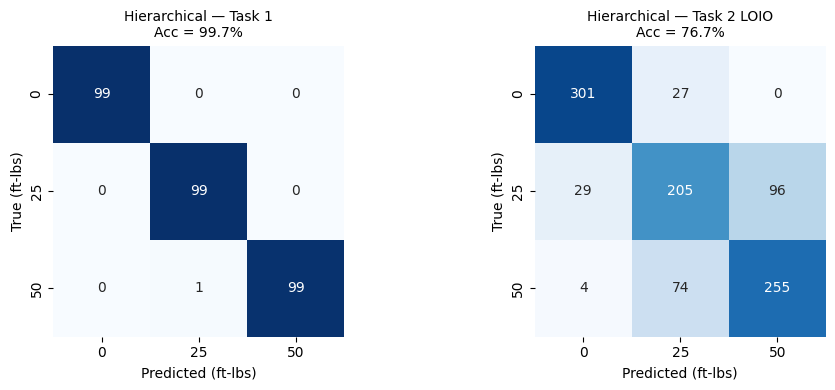

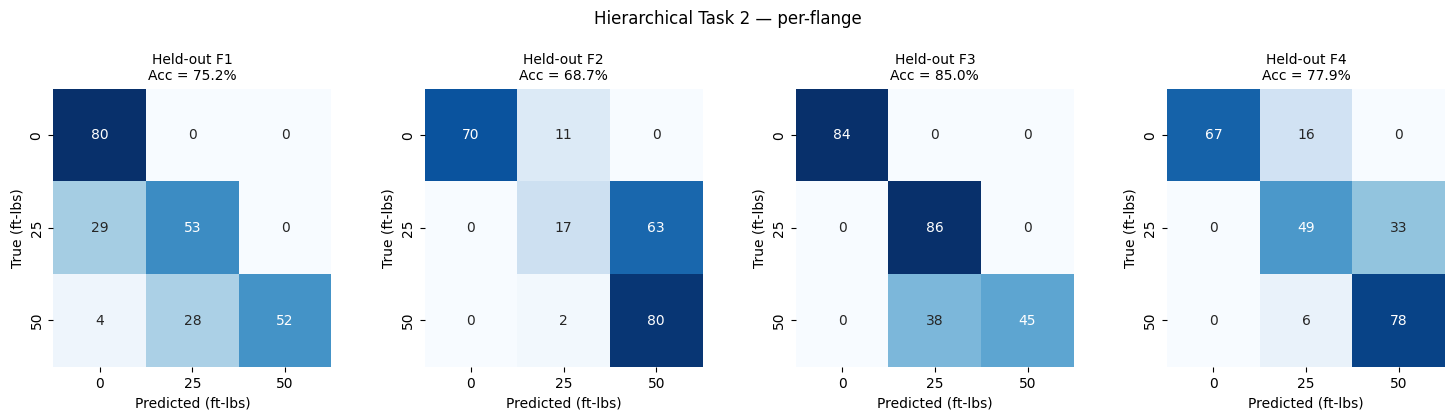


Training final hierarchical model on all 991 hits...
Stage 1: {'svm__C': 1, 'svm__gamma': 0.001}
Stage 2: {'svm__C': 100, 'svm__gamma': 0.001}

✓ hier_results cached


In [14]:
# ============================================================
# Cell 17: Hierarchical (two-step) classifier
# ============================================================
# Stage 1 (binary): loose (0 ft-lbs)  vs  tight ({25, 50} ft-lbs)
# Stage 2 (3-class): if tight, classify  25 vs 50
#
# Why this should help: Our binary LOIO accuracy is 92–99%.
# The hard part is 25 vs 50 (similar mid/high tightness levels).
# A focused expert trained ONLY on {25, 50} samples should
# distinguish them better than a single 3-way classifier
# that also has to reject class 0.
# ============================================================
def make_svm_pipe():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', probability=True,
                    class_weight='balanced', random_state=SEED)),
    ])
svm_grid_hier = {'svm__C': [0.1, 1, 10, 100],
                 'svm__gamma': ['scale', 'auto', 0.001, 0.01]}

def hierarchical_predict(stage1, stage2, X, tight_threshold=0.5):
    """
    Returns (y_pred, joint_proba, p_tight).
    - y_pred: hard hierarchical decision
        if p_tight < threshold → 0
        else → stage2.predict()  (returns label 1 or 2 = 25/50 ft-lbs)
    - joint_proba: P(class=k) = soft 3-class prob (for ensemble compat)
        P(0) = 1 - p_tight
        P(1) = p_tight * P(25 | tight)
        P(2) = p_tight * P(50 | tight)
    """
    p_tight = stage1.predict_proba(X)[:, 1]
    sub_proba = stage2.predict_proba(X)             # (N, 2): P(25|.), P(50|.)
    proba = np.zeros((len(X), 3), dtype=np.float32)
    proba[:, 0] = 1.0 - p_tight
    proba[:, 1] = p_tight * sub_proba[:, 0]
    proba[:, 2] = p_tight * sub_proba[:, 1]

    is_tight = p_tight >= tight_threshold
    y_pred = np.zeros(len(X), dtype=int)
    if is_tight.any():
        y_pred[is_tight] = stage2.predict(X[is_tight])  # → 1 or 2
    return y_pred, proba, p_tight

def fit_two_stage(X_tr, y_tr):
    """Fit Stage 1 (binary) + Stage 2 (25 vs 50 only) with grid search."""
    # Stage 1 — binary
    y_bin = (y_tr > 0).astype(int)
    gs_b = GridSearchCV(make_svm_pipe(), svm_grid_hier,
                        cv=5, n_jobs=-1, scoring='accuracy')
    gs_b.fit(X_tr, y_bin)
    # Stage 2 — 25 vs 50 only
    mask = y_tr > 0
    gs_t = GridSearchCV(make_svm_pipe(), svm_grid_hier,
                        cv=5, n_jobs=-1, scoring='accuracy')
    gs_t.fit(X_tr[mask], y_tr[mask])
    return gs_b.best_estimator_, gs_t.best_estimator_, gs_b.best_params_, gs_t.best_params_

# ============================================================
# TASK 1 — Dependent test
# ============================================================
print("="*64); print("TASK 1 — Hierarchical Dependent test"); print("="*64)
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_feat, y, test_size=0.30, stratify=y, random_state=SEED)

stage1, stage2, hp1, hp2 = fit_two_stage(X_tr1, y_tr1)
print(f"Stage 1 (loose vs tight): {hp1}")
print(f"Stage 2 (25 vs 50)      : {hp2}")

y_pred_t1, y_prob_t1, p_tight_t1 = hierarchical_predict(stage1, stage2, X_te1)
acc_te1 = accuracy_score(y_te1, y_pred_t1)
f1_t1   = f1_score(y_te1, y_pred_t1, average='macro')
print(f"\nTask 1 acc: {acc_te1*100:.2f}% | Macro-F1: {f1_t1:.3f}")
print(classification_report(y_te1, y_pred_t1,
      target_names=[f'{c} ft-lbs' for c in CLASS_LABELS]))

# Stage-wise diagnostics (useful for the report)
y_te1_bin = (y_te1 > 0).astype(int)
y_pred_bin = (p_tight_t1 >= 0.5).astype(int)
print(f"Stage 1 alone (binary acc): {accuracy_score(y_te1_bin, y_pred_bin)*100:.2f}%")
mask_truly_tight = y_te1 > 0
mask_pred_tight  = y_pred_t1 > 0
both_tight = mask_truly_tight & mask_pred_tight
if both_tight.sum() > 0:
    s2_acc = accuracy_score(y_te1[both_tight], y_pred_t1[both_tight])
    print(f"Stage 2 alone (25 vs 50, where both true & pred are tight): {s2_acc*100:.2f}%")

# ============================================================
# TASK 2 — LOIO
# ============================================================
print("\n" + "="*64); print("TASK 2 — Hierarchical LOIO"); print("="*64)
fold_records = []
fold_y_true, fold_y_pred, fold_y_proba = [], [], []

for fold, (tr_idx, te_idx) in enumerate(logo.split(X_feat, y, groups), 1):
    flange_out = int(groups[te_idx[0]])
    X_tr, X_te = X_feat[tr_idx], X_feat[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    s1, s2, _, _ = fit_two_stage(X_tr, y_tr)
    y_p, y_pr, p_t = hierarchical_predict(s1, s2, X_te)

    acc3 = accuracy_score(y_te, y_p)
    f1   = f1_score(y_te, y_p, average='macro')
    accB = accuracy_score((y_te > 0).astype(int), (y_p > 0).astype(int))

    # Stage-2 conditional accuracy: among samples we *correctly* called tight,
    # how often did we get 25 vs 50 right?
    correct_tight = (y_te > 0) & (y_p > 0)
    s2_cond = (accuracy_score(y_te[correct_tight], y_p[correct_tight])
               if correct_tight.sum() > 0 else np.nan)

    fold_records.append({
        'fold': fold, 'flange_out': flange_out,
        '3class_acc': acc3, 'binary_acc': accB, 'macro_f1': f1,
        'stage2_cond_acc': s2_cond,
    })
    fold_y_true.append(y_te); fold_y_pred.append(y_p); fold_y_proba.append(y_pr)
    print(f"Fold {fold} (F{flange_out}): 3-class={acc3*100:6.2f}% "
          f"Binary={accB*100:6.2f}% Stage2|tight={s2_cond*100:5.2f}% F1={f1:.3f}")

loio_df = pd.DataFrame(fold_records)
mean3, std3 = loio_df['3class_acc'].mean(), loio_df['3class_acc'].std()
meanB, stdB = loio_df['binary_acc'].mean(), loio_df['binary_acc'].std()
print(f"\nHierarchical LOIO: 3-class={mean3*100:.2f}%±{std3*100:.2f}% | "
      f"Binary={meanB*100:.2f}%±{stdB*100:.2f}% | F1={loio_df['macro_f1'].mean():.3f}")
print(f"Stage 2 conditional acc (mean across folds): "
      f"{loio_df['stage2_cond_acc'].mean()*100:.2f}%")

# Confusion matrices
y_true_pooled = np.concatenate(fold_y_true)
y_pred_pooled = np.concatenate(fold_y_pred)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion(y_te1, y_pred_t1,
               f'Hierarchical — Task 1\nAcc = {acc_te1*100:.1f}%', ax=axes[0])
plot_confusion(y_true_pooled, y_pred_pooled,
               f'Hierarchical — Task 2 LOIO\nAcc = {mean3*100:.1f}%', ax=axes[1])
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for k, ax in enumerate(axes):
    fd = fold_records[k]
    plot_confusion(fold_y_true[k], fold_y_pred[k],
                   f"Held-out F{fd['flange_out']}\nAcc = {fd['3class_acc']*100:.1f}%", ax=ax)
plt.suptitle('Hierarchical Task 2 — per-flange', y=1.04)
plt.tight_layout(); plt.show()

# ============================================================
# Final hierarchical model on all 991 hits
# ============================================================
print("\nTraining final hierarchical model on all 991 hits...")
stage1_final, stage2_final, hp1f, hp2f = fit_two_stage(X_feat, y)
print(f"Stage 1: {hp1f}")
print(f"Stage 2: {hp2f}")
dump(stage1_final, os.path.join(OUTPUT_DIR, 'model_hier_stage1.joblib'))
dump(stage2_final, os.path.join(OUTPUT_DIR, 'model_hier_stage2.joblib'))

# # ============================================================
# # TASK 3 — Apply hierarchical model to lab test data
# # ============================================================
# print("\n" + "="*64); print("TASK 3 — Hierarchical on lab test data"); print("="*64)
# y_test_pred, y_test_proba, p_test_tight = hierarchical_predict(
#     stage1_final, stage2_final, X_test_feat)

# # Aggregate per flange (same logic as Cell 14)
# def aggregate_hier(proba, p_tight, meta_df, group_cols):
#     rows = []
#     for keys, grp in meta_df.groupby(group_cols):
#         if not isinstance(keys, tuple): keys = (keys,)
#         idx = grp.index.values
#         avg_p   = proba[idx].mean(axis=0)
#         avg_pt  = float(p_tight[idx].mean())
#         pred_ix = int(avg_p.argmax())
#         row = {col: k for col, k in zip(group_cols, keys)}
#         row.update({
#             'n_hits'     : len(idx),
#             'predicted'  : IDX_TO_CLASS[pred_ix],
#             'p_loose'    : float(avg_p[0]),
#             'p_25'       : float(avg_p[1]),
#             'p_50'       : float(avg_p[2]),
#             'p_tight_avg': avg_pt,
#             'confidence' : float(avg_p.max()),
#         })
#         rows.append(row)
#     return pd.DataFrame(rows)

# hier_flange = aggregate_hier(y_test_proba, p_test_tight, test_meta_df,
#                               ['flange_id']).sort_values('flange_id')
# hier_area   = aggregate_hier(y_test_proba, p_test_tight, test_meta_df,
#                               ['flange_id', 'area_id']).sort_values(['flange_id','area_id'])

# print("\nHIERARCHICAL — per-flange:")
# print(hier_flange.to_string(index=False))

# print("\nCOMPARISON: Hierarchical vs original Ensemble:")
# ens_flange = ALL_PREDS['Ensemble']['flange'].sort_values('flange_id')
# cmp_df = pd.DataFrame({
#     'flange_id'        : hier_flange['flange_id'].values,
#     'Ensemble_pred'    : ens_flange['predicted'].values,
#     'Ensemble_conf'    : ens_flange['confidence'].round(3).values,
#     'Hier_pred'        : hier_flange['predicted'].values,
#     'Hier_conf'        : hier_flange['confidence'].round(3).values,
#     'Hier_p_tight'     : hier_flange['p_tight_avg'].round(3).values,
# })
# print(cmp_df.to_string(index=False))

# hier_flange.to_csv(os.path.join(OUTPUT_DIR, 'submission_hier_per_flange.csv'), index=False)
# hier_area.to_csv  (os.path.join(OUTPUT_DIR, 'submission_hier_per_area.csv'),   index=False)
# print(f"\nSaved → submission_hier_per_flange.csv")
# print(f"Saved → submission_hier_per_area.csv")

# Cache for any downstream use
hier_results = {
    'name'           : 'Hierarchical',
    'task1_test_acc' : acc_te1, 'task1_macro_f1' : f1_t1,
    'task1_y_test'   : y_te1,   'task1_y_pred'   : y_pred_t1,
    'task1_y_proba'  : y_prob_t1,
    'task2_mean_acc' : mean3,   'task2_mean_bin' : meanB,
    'task2_mean_f1'  : loio_df['macro_f1'].mean(),
    'task2_per_fold' : loio_df,
    'task2_y_true'   : fold_y_true,
    'task2_y_pred'   : fold_y_pred,
    'task2_y_proba'  : fold_y_proba,
    'final_stage1'   : stage1_final,
    'final_stage2'   : stage2_final,
}
print("\n✓ hier_results cached")

In [17]:
ALL_RESULTS = [svm_results, lr_results, knn_results, mlp_results,
               cnn_results, lstm_results, hier_results]
for r in ALL_RESULTS:
    for k in ['task1_test_acc', 'task1_y_proba', 'task2_mean_acc', 'task2_y_proba']:
        assert k in r, f"{r['name']} missing key {k}"

HEADLINE COMPARISON — all 4 models
       Model Task1 Test Acc Task1 Macro-F1 Task2 Mean 3-cls Task2 Mean Binary Task2 Macro-F1 Train→Task2 Drop
         SVM        100.00%          1.000   75.34% ± 11.87     92.67% ± 5.61          0.739        +24.66 pp
          LR         99.66%          0.997   75.45% ± 11.51     89.52% ± 9.45          0.743        +24.21 pp
         KNN        100.00%          1.000    66.34% ± 9.85     90.68% ± 8.99          0.654        +33.66 pp
         MLP         99.66%          0.997   76.23% ± 12.61     91.76% ± 4.99          0.754        +23.43 pp
         CNN        100.00%          1.000   67.97% ± 10.04     99.90% ± 0.20          0.655        +32.03 pp
        LSTM         98.99%          0.990    83.08% ± 7.86     97.56% ± 4.10          0.820        +15.91 pp
Hierarchical         99.66%          0.997    76.70% ± 6.73     93.91% ± 5.58          0.754        +22.96 pp

PER-FOLD 3-CLASS ACCURACY  (rows: model, columns: held-out flange)
                 

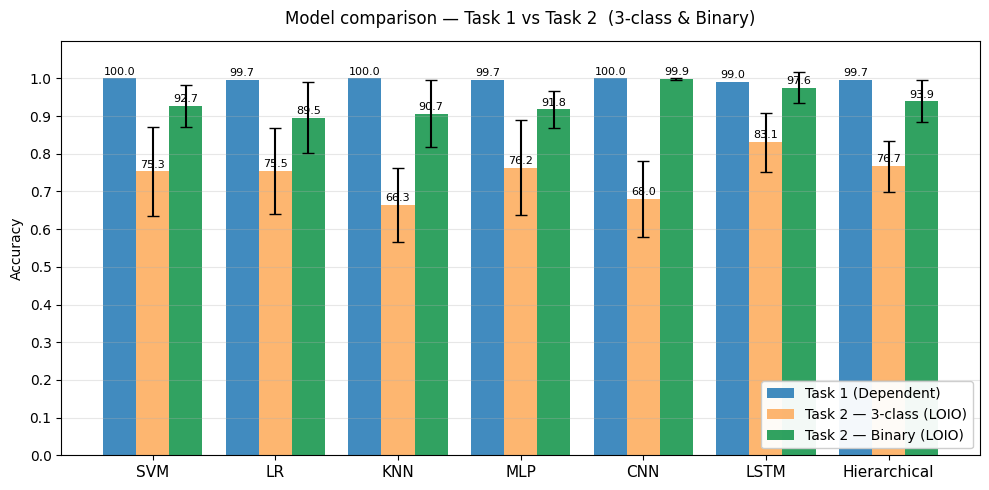

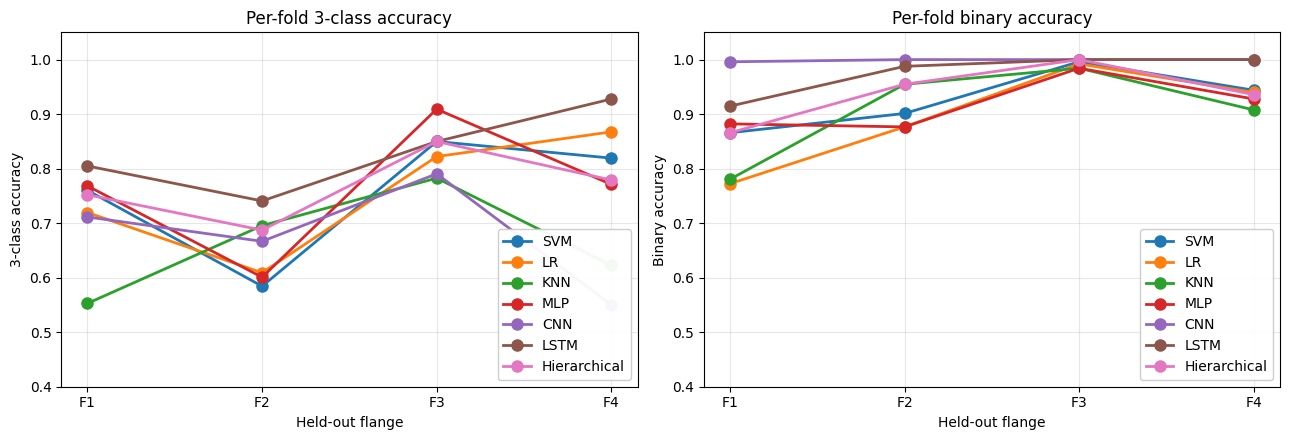


AUTO-GENERATED OBSERVATIONS FOR THE REPORT
• Best Task 1  (3-class)        : SVM  (100.00%)
• Best Task 2  (3-class, LOIO)  : LSTM  (83.08%)
• Best Task 2  (Binary,  LOIO)  : CNN  (99.90%)
• Smallest Task1→Task2 drop     : LSTM  (+15.91 pp)
• Hardest held-out flange       : F2  (mean 3-class = 65.49%)
• Easiest held-out flange       : F3  (mean 3-class = 83.63%)


In [18]:
# ============================================================
# Cell 11: Comparison table — SVM, LR, MLP, CNN
# ============================================================
# Pulls from svm_results, lr_results, mlp_results, cnn_results
# (cached at the end of Cells 7–10)
# Outputs:
#   1. Headline summary table (Task 1 + Task 2 + Binary + F1)
#   2. Per-fold breakdown (4 models × 4 folds)
#   3. Bar charts of the headline numbers
#   4. Per-fold line plot
# ============================================================

ALL_RESULTS = [svm_results, lr_results, knn_results, mlp_results,
               cnn_results, lstm_results, hier_results]

# ============================================================
# 1) Headline summary table
# ============================================================
summary_rows = []
for r in ALL_RESULTS:
    pf = r['task2_per_fold']
    summary_rows.append({
        'Model'            : r['name'],
        'Task1 Test Acc'   : f"{r['task1_test_acc']*100:5.2f}%",
        'Task1 Macro-F1'   : f"{r['task1_macro_f1']:.3f}",
        'Task2 Mean 3-cls' : f"{r['task2_mean_acc']*100:5.2f}% ± {pf['3class_acc'].std()*100:4.2f}",
        'Task2 Mean Binary': f"{r['task2_mean_bin']*100:5.2f}% ± {pf['binary_acc'].std()*100:4.2f}",
        'Task2 Macro-F1'   : f"{r['task2_mean_f1']:.3f}",
        'Train→Task2 Drop' : f"{(r['task1_test_acc']-r['task2_mean_acc'])*100:+5.2f} pp",
    })
summary_df = pd.DataFrame(summary_rows)

print("="*88)
print("HEADLINE COMPARISON — all 4 models")
print("="*88)
print(summary_df.to_string(index=False))

# ============================================================
# 2) Per-fold breakdown — one row per (model, fold)
# ============================================================
perfold_rows = []
for r in ALL_RESULTS:
    for _, fold in r['task2_per_fold'].iterrows():
        perfold_rows.append({
            'Model'      : r['name'],
            'Held-out'   : f"F{fold['flange_out']}",
            '3-class'    : f"{fold['3class_acc']*100:5.2f}%",
            'Binary'     : f"{fold['binary_acc']*100:5.2f}%",
            'Macro-F1'   : f"{fold['macro_f1']:.3f}",
        })
perfold_df = pd.DataFrame(perfold_rows)

# Pivot to a wide model×fold matrix for easy reading
pivot_3cls = (
    pd.DataFrame([
        {'Model': r['name'], **{f"F{int(row['flange_out'])}": row['3class_acc']
                                for _, row in r['task2_per_fold'].iterrows()}}
        for r in ALL_RESULTS
    ])
    .set_index('Model')
)
pivot_3cls['Mean'] = pivot_3cls.mean(axis=1)

pivot_bin = (
    pd.DataFrame([
        {'Model': r['name'], **{f"F{int(row['flange_out'])}": row['binary_acc']
                                for _, row in r['task2_per_fold'].iterrows()}}
        for r in ALL_RESULTS
    ])
    .set_index('Model')
)
pivot_bin['Mean'] = pivot_bin.mean(axis=1)

print(f"\n{'='*88}")
print("PER-FOLD 3-CLASS ACCURACY  (rows: model, columns: held-out flange)")
print(f"{'='*88}")
print((pivot_3cls*100).round(2).to_string())

print(f"\n{'='*88}")
print("PER-FOLD BINARY ACCURACY  (0 ft-lbs vs {25, 50})")
print(f"{'='*88}")
print((pivot_bin*100).round(2).to_string())

# Save tables for the report
summary_df.to_csv(os.path.join(OUTPUT_DIR, 'comparison_summary.csv'), index=False)
perfold_df.to_csv(os.path.join(OUTPUT_DIR, 'comparison_perfold.csv'), index=False)
pivot_3cls.to_csv(os.path.join(OUTPUT_DIR, 'comparison_3class_pivot.csv'))
pivot_bin.to_csv(os.path.join(OUTPUT_DIR, 'comparison_binary_pivot.csv'))
print(f"\n✓ Saved 4 CSVs → {OUTPUT_DIR}")

# ============================================================
# 3) Headline bar chart — all 4 models on 3 key metrics
# ============================================================
model_names = [r['name'] for r in ALL_RESULTS]
t1_acc      = [r['task1_test_acc']    for r in ALL_RESULTS]
t2_3cls     = [r['task2_mean_acc']    for r in ALL_RESULTS]
t2_3cls_std = [r['task2_per_fold']['3class_acc'].std() for r in ALL_RESULTS]
t2_bin      = [r['task2_mean_bin']    for r in ALL_RESULTS]
t2_bin_std  = [r['task2_per_fold']['binary_acc'].std() for r in ALL_RESULTS]

x = np.arange(len(model_names))
w = 0.27
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - w, t1_acc,  w, label='Task 1 (Dependent)',
       color='#2c7fb8', alpha=0.9)
ax.bar(x,     t2_3cls, w, yerr=t2_3cls_std, capsize=4,
       label='Task 2 — 3-class (LOIO)', color='#fdae61', alpha=0.9)
ax.bar(x + w, t2_bin,  w, yerr=t2_bin_std, capsize=4,
       label='Task 2 — Binary (LOIO)',  color='#1a9850', alpha=0.9)

# Annotate bar values
for i, v in enumerate(t1_acc):  ax.text(i-w, v+0.01, f'{v*100:.1f}', ha='center', fontsize=8)
for i, v in enumerate(t2_3cls): ax.text(i,   v+0.01, f'{v*100:.1f}', ha='center', fontsize=8)
for i, v in enumerate(t2_bin):  ax.text(i+w, v+0.01, f'{v*100:.1f}', ha='center', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.10)
ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.set_title('Model comparison — Task 1 vs Task 2  (3-class & Binary)',
             fontsize=12, pad=12)
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_model_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 4) Per-fold line plot — easy way to see which flange is hardest
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
folds = ['F1', 'F2', 'F3', 'F4']

for r in ALL_RESULTS:
    pf = r['task2_per_fold'].sort_values('flange_out')
    axes[0].plot(folds, pf['3class_acc'].values, marker='o', lw=2,
                 markersize=8, label=r['name'])
    axes[1].plot(folds, pf['binary_acc'].values, marker='o', lw=2,
                 markersize=8, label=r['name'])

for ax, title, ylab in zip(axes,
                            ['Per-fold 3-class accuracy', 'Per-fold binary accuracy'],
                            ['3-class accuracy', 'Binary accuracy']):
    ax.set_xlabel('Held-out flange')
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.set_ylim(0.4, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(loc='lower right', framealpha=0.95)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_perfold_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 5) Headline observations (auto-generated for the report)
# ============================================================
best_t1   = max(ALL_RESULTS, key=lambda r: r['task1_test_acc'])
best_t2   = max(ALL_RESULTS, key=lambda r: r['task2_mean_acc'])
best_bin  = max(ALL_RESULTS, key=lambda r: r['task2_mean_bin'])
worst_t2  = min(ALL_RESULTS, key=lambda r: r['task2_mean_acc'])
smallest_drop = min(ALL_RESULTS,
                    key=lambda r: r['task1_test_acc'] - r['task2_mean_acc'])

print(f"\n{'='*88}")
print("AUTO-GENERATED OBSERVATIONS FOR THE REPORT")
print(f"{'='*88}")
print(f"• Best Task 1  (3-class)        : {best_t1['name']}  "
      f"({best_t1['task1_test_acc']*100:.2f}%)")
print(f"• Best Task 2  (3-class, LOIO)  : {best_t2['name']}  "
      f"({best_t2['task2_mean_acc']*100:.2f}%)")
print(f"• Best Task 2  (Binary,  LOIO)  : {best_bin['name']}  "
      f"({best_bin['task2_mean_bin']*100:.2f}%)")
print(f"• Smallest Task1→Task2 drop     : {smallest_drop['name']}  "
      f"({(smallest_drop['task1_test_acc']-smallest_drop['task2_mean_acc'])*100:+.2f} pp)")

# Hardest / easiest flange across all models
hardest_flange = pivot_3cls.drop(columns='Mean').mean(axis=0).idxmin()
easiest_flange = pivot_3cls.drop(columns='Mean').mean(axis=0).idxmax()
print(f"• Hardest held-out flange       : {hardest_flange}  "
      f"(mean 3-class = {pivot_3cls.drop(columns='Mean')[hardest_flange].mean()*100:.2f}%)")
print(f"• Easiest held-out flange       : {easiest_flange}  "
      f"(mean 3-class = {pivot_3cls.drop(columns='Mean')[easiest_flange].mean()*100:.2f}%)")

ENSEMBLE WEIGHTS (proportional to LOIO 3-class accuracy)
Model       LOIO Acc      Weight
SVM           75.34%      0.1446
LR            75.45%      0.1448
KNN           66.34%      0.1273
MLP           76.23%      0.1463
CNN           67.97%      0.1304
LSTM          83.08%      0.1594
Hierarchical      76.70%      0.1472
Sum                       1.0000

TASK 1 — Ensemble on Dependent test set
Test acc : 100.00%   Macro-F1: 1.000

Per-class breakdown:
              precision    recall  f1-score   support

    0 ft-lbs       1.00      1.00      1.00        99
   25 ft-lbs       1.00      1.00      1.00        99
   50 ft-lbs       1.00      1.00      1.00       100

    accuracy                           1.00       298
   macro avg       1.00      1.00      1.00       298
weighted avg       1.00      1.00      1.00       298


TASK 2 — Ensemble per LOIO fold
Fold 1: Train=[2, 3, 4] → Test=[1]   3-class= 78.86%   Binary= 88.21%   F1=0.786
Fold 2: Train=[1, 3, 4] → Test=[2]   3-class= 6

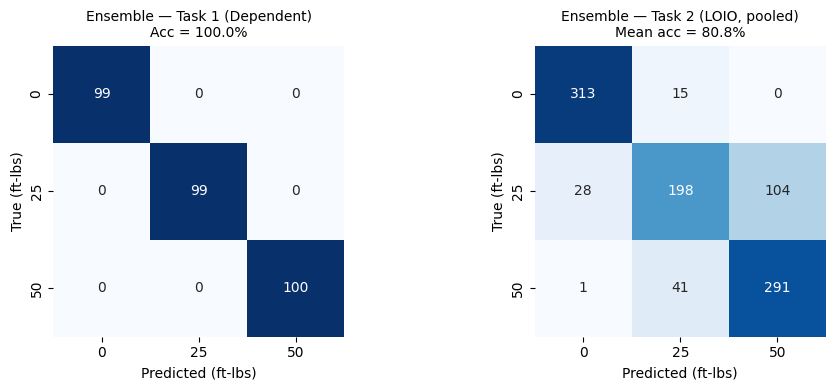

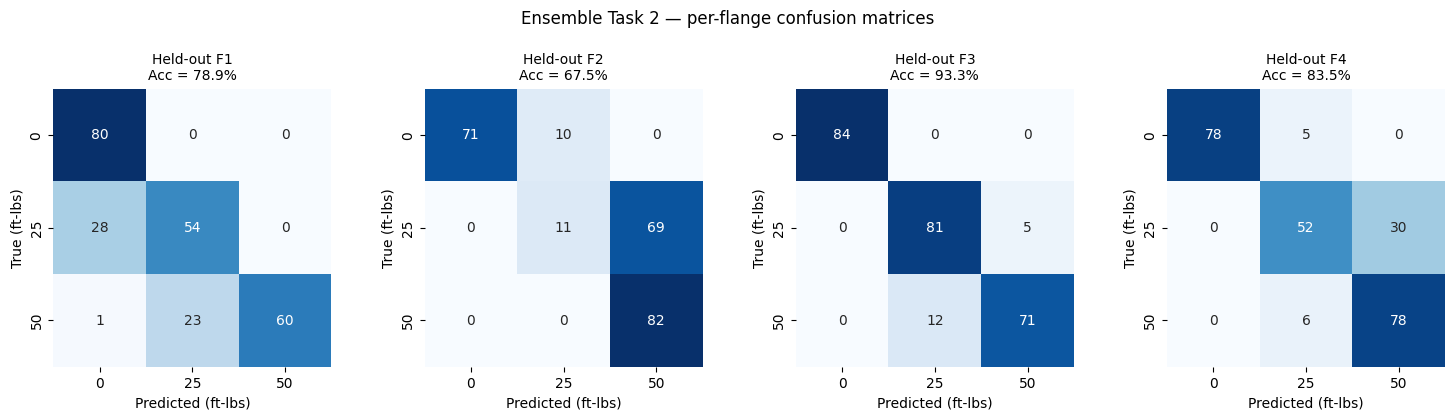

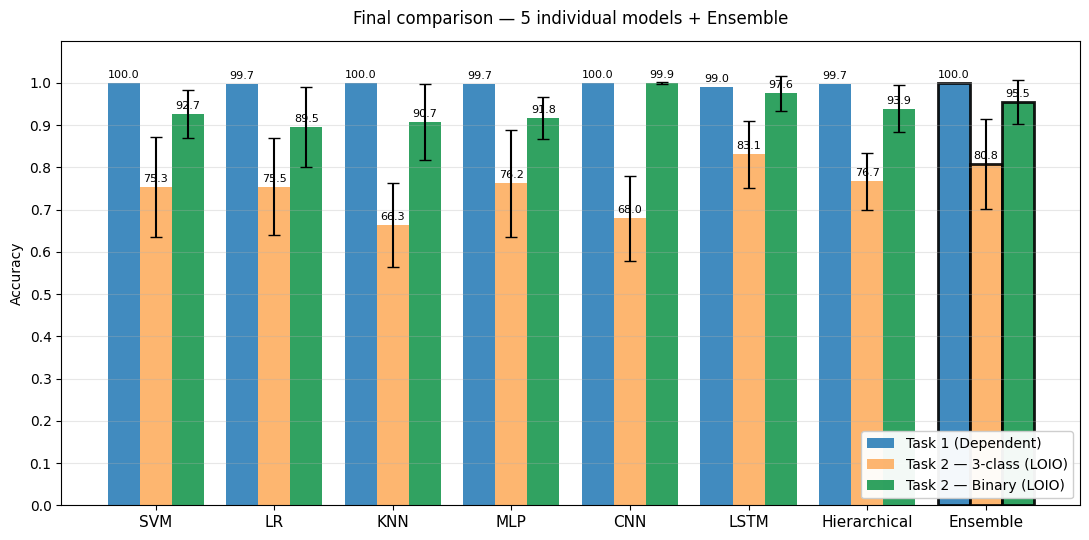


✓ Saved ensemble metadata → ensemble_summary.json
✓ ensemble_results cached

ENSEMBLE LIFT vs best individual model
3-class  :  80.79%  vs  best (LSTM) = 83.08%   Δ = -2.29 pp
Binary   :  95.52%  vs  best (CNN) = 99.90%   Δ = -4.38 pp


In [19]:
# ============================================================
# Cell 12: Soft-voting ensemble — combine all 5 models
# ============================================================
# Strategy: per-sample weighted average of class probabilities,
#           weights ∝ each model's LOIO 3-class accuracy.
# Both Task 1 and Task 2 evaluations included.
# ============================================================

ALL_RESULTS = [svm_results, lr_results, knn_results, mlp_results,
               cnn_results, lstm_results, hier_results]
N_MODELS    = len(ALL_RESULTS)

# ============================================================
# 1) Compute weights from LOIO 3-class accuracy
# ============================================================
loio_accs = np.array([r['task2_mean_acc'] for r in ALL_RESULTS])
weights   = loio_accs / loio_accs.sum()      # normalize to sum = 1

print("="*72)
print("ENSEMBLE WEIGHTS (proportional to LOIO 3-class accuracy)")
print("="*72)
print(f"{'Model':<8}{'LOIO Acc':>12}{'Weight':>12}")
for r, a, w in zip(ALL_RESULTS, loio_accs, weights):
    print(f"{r['name']:<8}{a*100:>11.2f}%{w:>12.4f}")
print(f"{'Sum':<8}{'':>12}{weights.sum():>12.4f}")

# ============================================================
# 2) TASK 1 — Ensemble on the held-out 30% test set
# ============================================================
# All 5 models scored predictions on the SAME y_te1 (same SEED).
# We can simply weight-average their probability arrays.
print(f"\n{'='*72}")
print("TASK 1 — Ensemble on Dependent test set")
print(f"{'='*72}")

# Stack: (N_models, N_test, N_classes)
P_t1 = np.stack([r['task1_y_proba'] for r in ALL_RESULTS], axis=0)
y_te = ALL_RESULTS[0]['task1_y_test']        # identical across all models

# Weighted average → (N_test, N_classes)
P_ens_t1   = (weights[:, None, None] * P_t1).sum(axis=0)
y_ens_t1   = P_ens_t1.argmax(axis=1)
acc_ens_t1 = accuracy_score(y_te, y_ens_t1)
f1_ens_t1  = f1_score(y_te, y_ens_t1, average='macro')

print(f"Test acc : {acc_ens_t1*100:6.2f}%   Macro-F1: {f1_ens_t1:.3f}")
print("\nPer-class breakdown:")
print(classification_report(y_te, y_ens_t1,
                            target_names=[f'{c} ft-lbs' for c in CLASS_LABELS]))

# ============================================================
# 3) TASK 2 — Ensemble per LOIO fold
# ============================================================
# All 5 models tested on the SAME held-out flange in each fold,
# in the SAME row order (LeaveOneGroupOut is deterministic).
# So we can stack their per-fold probability arrays directly.
print(f"\n{'='*72}")
print("TASK 2 — Ensemble per LOIO fold")
print(f"{'='*72}")

ens_fold_records = []
ens_fold_y_true  = []
ens_fold_y_pred  = []

for k in range(4):
    # (N_models, N_fold_samples, N_classes)
    P_fold = np.stack([r['task2_y_proba'][k] for r in ALL_RESULTS], axis=0)
    y_true = ALL_RESULTS[0]['task2_y_true'][k]
    flange_out    = int(ALL_RESULTS[0]['task2_per_fold'].iloc[k]['flange_out'])
    train_flanges = sorted(set([1, 2, 3, 4]) - {flange_out})

    # Sanity check: every model should agree on y_true for this fold
    for r in ALL_RESULTS[1:]:
        assert np.array_equal(r['task2_y_true'][k], y_true), \
            f"Fold {k+1}: y_true mismatch between models"

    P_ens   = (weights[:, None, None] * P_fold).sum(axis=0)
    y_pred  = P_ens.argmax(axis=1)

    acc3 = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro')
    accB = accuracy_score((y_true > 0).astype(int), (y_pred > 0).astype(int))

    ens_fold_records.append({
        'fold': k+1, 'flange_out': flange_out,
        '3class_acc': acc3, 'binary_acc': accB, 'macro_f1': f1,
    })
    ens_fold_y_true.append(y_true)
    ens_fold_y_pred.append(y_pred)

    print(f"Fold {k+1}: Train={train_flanges} → Test=[{flange_out}]   "
          f"3-class={acc3*100:6.2f}%   Binary={accB*100:6.2f}%   F1={f1:.3f}")

ens_loio_df = pd.DataFrame(ens_fold_records)
ens_mean3 = ens_loio_df['3class_acc'].mean();  ens_std3 = ens_loio_df['3class_acc'].std()
ens_meanB = ens_loio_df['binary_acc'].mean();  ens_stdB = ens_loio_df['binary_acc'].std()

print(f"\nEnsemble LOIO mean : 3-class = {ens_mean3*100:.2f}% ± {ens_std3*100:.2f}%")
print(f"                     Binary  = {ens_meanB*100:.2f}% ± {ens_stdB*100:.2f}%")
print(f"                     Macro-F1 = {ens_loio_df['macro_f1'].mean():.3f}")

# ============================================================
# 4) Confusion matrices (Task 1 + pooled Task 2 + per-fold)
# ============================================================
y_true_pooled = np.concatenate(ens_fold_y_true)
y_pred_pooled = np.concatenate(ens_fold_y_pred)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion(y_te, y_ens_t1,
               f'Ensemble — Task 1 (Dependent)\nAcc = {acc_ens_t1*100:.1f}%',
               ax=axes[0])
plot_confusion(y_true_pooled, y_pred_pooled,
               f'Ensemble — Task 2 (LOIO, pooled)\nMean acc = {ens_mean3*100:.1f}%',
               ax=axes[1])
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for k, ax in enumerate(axes):
    fold = ens_fold_records[k]
    plot_confusion(ens_fold_y_true[k], ens_fold_y_pred[k],
                   f"Held-out F{fold['flange_out']}\nAcc = {fold['3class_acc']*100:.1f}%",
                   ax=ax)
plt.suptitle('Ensemble Task 2 — per-flange confusion matrices', y=1.04)
plt.tight_layout(); plt.show()

# ============================================================
# 5) Ensemble vs individual models — final comparison plot
# ============================================================
all_names_plus_ens = [r['name'] for r in ALL_RESULTS] + ['Ensemble']
all_t1   = [r['task1_test_acc'] for r in ALL_RESULTS] + [acc_ens_t1]
all_t2_3 = [r['task2_mean_acc'] for r in ALL_RESULTS] + [ens_mean3]
all_t2_b = [r['task2_mean_bin'] for r in ALL_RESULTS] + [ens_meanB]
t2_3_std = [r['task2_per_fold']['3class_acc'].std() for r in ALL_RESULTS] + [ens_std3]
t2_b_std = [r['task2_per_fold']['binary_acc'].std() for r in ALL_RESULTS] + [ens_stdB]

x = np.arange(len(all_names_plus_ens)); w = 0.27
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x - w, all_t1,   w, label='Task 1 (Dependent)',         color='#2c7fb8', alpha=0.9)
ax.bar(x,     all_t2_3, w, yerr=t2_3_std, capsize=4,
       label='Task 2 — 3-class (LOIO)',                         color='#fdae61', alpha=0.9)
ax.bar(x + w, all_t2_b, w, yerr=t2_b_std, capsize=4,
       label='Task 2 — Binary (LOIO)',                          color='#1a9850', alpha=0.9)

# Highlight ensemble bars
for i, bar_offset in enumerate([-w, 0, w]):
    rect = ax.patches[i*len(all_names_plus_ens) + len(all_names_plus_ens) - 1]
    rect.set_edgecolor('black'); rect.set_linewidth(2)

for i, v in enumerate(all_t1):   ax.text(i-w, v+0.012, f'{v*100:.1f}', ha='center', fontsize=8)
for i, v in enumerate(all_t2_3): ax.text(i,   v+0.012, f'{v*100:.1f}', ha='center', fontsize=8)
for i, v in enumerate(all_t2_b): ax.text(i+w, v+0.012, f'{v*100:.1f}', ha='center', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(all_names_plus_ens, fontsize=11)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.10)
ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.set_title('Final comparison — 5 individual models + Ensemble', fontsize=12, pad=12)
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_ensemble_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 6) Save ensemble metadata + cache
# ============================================================
ens_summary = {
    'model_names'        : [r['name'] for r in ALL_RESULTS],
    'weights'            : weights.tolist(),
    'task1_acc'          : acc_ens_t1,
    'task1_macro_f1'     : f1_ens_t1,
    'task2_mean_acc'     : ens_mean3,
    'task2_mean_bin'     : ens_meanB,
    'task2_mean_f1'      : ens_loio_df['macro_f1'].mean(),
    'task2_per_fold'     : ens_loio_df.to_dict(orient='records'),
}
with open(os.path.join(OUTPUT_DIR, 'ensemble_summary.json'), 'w') as f:
    json.dump(ens_summary, f, indent=2)
print(f"\n✓ Saved ensemble metadata → ensemble_summary.json")

# Cache for any downstream cells
ensemble_results = {
    'name'           : 'Ensemble',
    'weights'        : weights,
    'task1_test_acc' : acc_ens_t1,
    'task1_macro_f1' : f1_ens_t1,
    'task1_y_pred'   : y_ens_t1,
    'task1_y_proba'  : P_ens_t1,
    'task2_mean_acc' : ens_mean3,
    'task2_mean_bin' : ens_meanB,
    'task2_mean_f1'  : ens_loio_df['macro_f1'].mean(),
    'task2_per_fold' : ens_loio_df,
    'task2_y_true'   : ens_fold_y_true,
    'task2_y_pred'   : ens_fold_y_pred,
}
print("✓ ensemble_results cached")

# ============================================================
# 7) Headline gains over best individual model
# ============================================================
best_indiv_t2_3 = max(r['task2_mean_acc'] for r in ALL_RESULTS)
best_indiv_t2_b = max(r['task2_mean_bin'] for r in ALL_RESULTS)
best_t2_3_name  = max(ALL_RESULTS, key=lambda r: r['task2_mean_acc'])['name']
best_t2_b_name  = max(ALL_RESULTS, key=lambda r: r['task2_mean_bin'])['name']

print(f"\n{'='*72}")
print("ENSEMBLE LIFT vs best individual model")
print(f"{'='*72}")
print(f"3-class  : {ens_mean3*100:6.2f}%  vs  best ({best_t2_3_name}) = {best_indiv_t2_3*100:.2f}%   "
      f"Δ = {(ens_mean3 - best_indiv_t2_3)*100:+.2f} pp")
print(f"Binary   : {ens_meanB*100:6.2f}%  vs  best ({best_t2_b_name}) = {best_indiv_t2_b*100:.2f}%   "
      f"Δ = {(ens_meanB - best_indiv_t2_b)*100:+.2f} pp")

Test files indexed : 16
Flanges seen       : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Areas seen         : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

File listing:
           filename  flange_id  area_id
Area 1 Flange 3.m4a          3        1
Area 1 flange 1.m4a          1        1
Area 1 flange 2.m4a          2        1
Area 1 flange 4.m4a          4        1
Area 2 Flange 3.m4a          3        2
Area 2 flange 2.m4a          2        2
Area 2 flange 4.m4a          4        2
Area 3 Flange 3.m4a          3        3
Area 3 flange 1.m4a          1        3
Area 3 flange 2.m4a          2        3
Area 3 flange 4.m4a          4        3
Area 4 Flange 3.m4a          3        4
Area 4 flange 1.m4a          1        4
Area 4 flange 2.m4a          2        4
Area 4 flange 4.m4a          4        4
 Area2 flange 1.m4a          1        2

Extracting hits and features from test recordings...


  0%|          | 0/16 [00:00<?, ?it/s]


Total hits kept: 360

Per-file hit counts:
           filename  flange  area  detected  kept
Area 1 Flange 3.m4a       3     1        22    22
Area 1 flange 1.m4a       1     1        22    22
Area 1 flange 2.m4a       2     1        22    22
Area 1 flange 4.m4a       4     1        22    22
Area 2 Flange 3.m4a       3     2        22    22
Area 2 flange 2.m4a       2     2        22    22
Area 2 flange 4.m4a       4     2        24    24
Area 3 Flange 3.m4a       3     3        22    22
Area 3 flange 1.m4a       1     3        22    22
Area 3 flange 2.m4a       2     3        22    22
Area 3 flange 4.m4a       4     3        27    27
Area 4 Flange 3.m4a       3     4        22    22
Area 4 flange 1.m4a       1     4        22    22
Area 4 flange 2.m4a       2     4        22    22
Area 4 flange 4.m4a       4     4        23    23
 Area2 flange 1.m4a       1     2        22    22

Extracting 82-dim features...


  0%|          | 0/360 [00:00<?, ?it/s]


Extracting mel-spectrograms...


  0%|          | 0/360 [00:00<?, ?it/s]


Feature shapes:
  X_test_feat: (360, 82)
  X_test_spec: (360, 64, 128, 1)
  X_test_seq : (360, 128, 64)

Running all 7 trained final models on test hits...
✓ All 7 models run. Per-hit probabilities computed.

ENSEMBLE — per-flange prediction  (HEADLINE — submit this)
 flange_id  n_hits  predicted  p_0ftlbs  p_25ftlbs  p_50ftlbs  confidence   margin
         1      88         25  0.102887   0.460454   0.436659    0.460454 0.023794
         2      88         25  0.225343   0.604407   0.170250    0.604407 0.379063
         3      88         50  0.065314   0.207268   0.727418    0.727418 0.520150
         4      96         50  0.063032   0.253408   0.683560    0.683560 0.430152

ENSEMBLE — per-area breakdown  (consistency check)
 flange_id  area_id  n_hits  predicted  p_0ftlbs  p_25ftlbs  p_50ftlbs  confidence   margin
         1        1      22         25  0.086326   0.579344   0.334330    0.579344 0.245015
         1        2      22         25  0.109124   0.505518   0.385358    0.5055

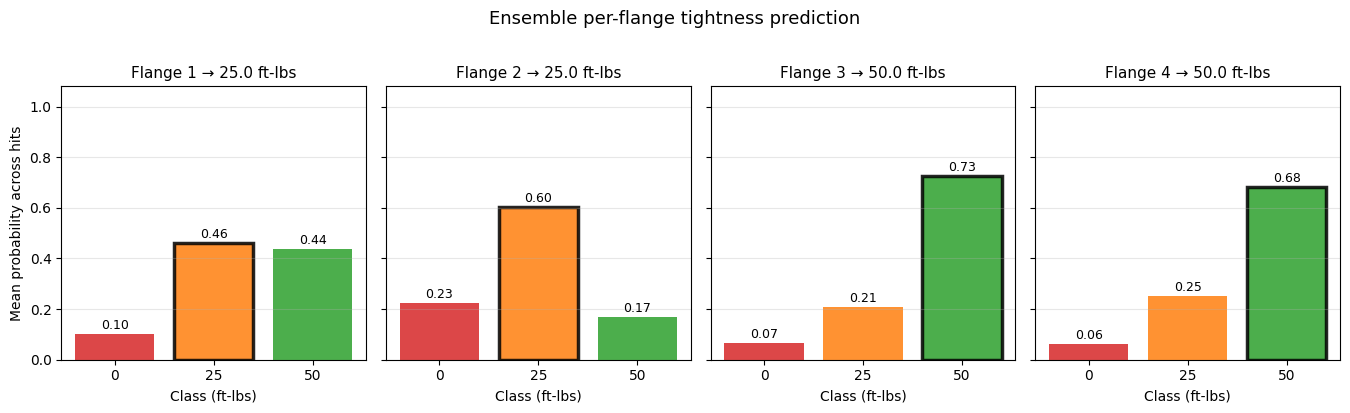

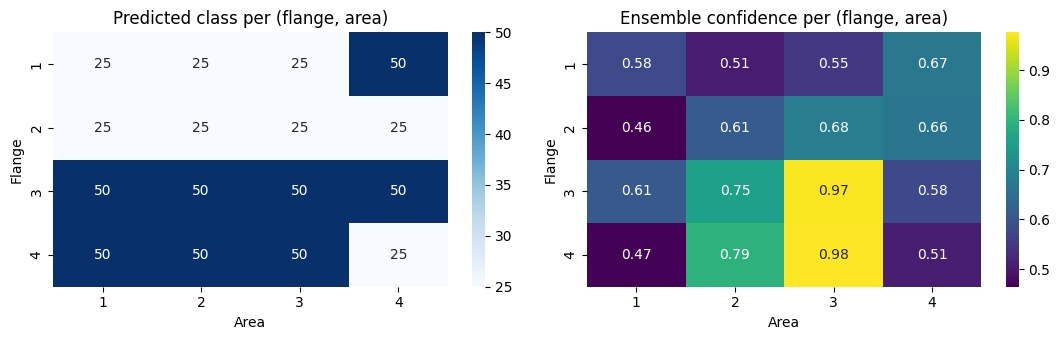


✓ Saved → submission_per_flange.csv  (THE submission)
✓ Saved → submission_per_area.csv    (per-area breakdown)
✓ Saved → consensus_all_models.csv  (which model said what)
✓ Saved → per_hit_predictions.csv   (full forensic log)

FINAL SUBMISSION (Ensemble-based)
  Flange 1 → 25.0 ft-lbs   (confidence=46.05%, margin=2.38%)  ⚠️ low conf
  Flange 2 → 25.0 ft-lbs   (confidence=60.44%, margin=37.91%)  ✓
  Flange 3 → 50.0 ft-lbs   (confidence=72.74%, margin=52.02%)  ✓
  Flange 4 → 50.0 ft-lbs   (confidence=68.36%, margin=43.02%)  ✓


In [23]:
# ============================================================
# Cell 13: Predict tightness for unknown flanges (Task 3)
# ============================================================
# - Reads /content/drive/MyDrive/final_project_test/
# - Tolerant filename parser: any order of "area N" and "flange M",
#   any case, optional underscores/spaces.
# - Reuses Cell 3 hit extractor + Cells 4–5 feature builders.
# - Runs all 5 trained final models + soft-voting ensemble.
# - Aggregates: per-hit → per-area → per-flange prediction.
# ============================================================

TEST_DATA_DIR = '/content/drive/MyDrive/final_project_test'

# ============================================================
# 1) Tolerant filename parser
# ============================================================
# Accepts:  Area_1_flange_1.m4a   Area1Flange1.m4a   flange 1 area 1.m4a
#           Flange1_Area1.m4a     area_1_F1.m4a      F1A1.m4a
# ============================================================
def parse_test_filename(fname):
    """Extract (flange_id, area_id) from any reasonable filename."""
    name = os.path.splitext(fname)[0].lower()
    name = re.sub(r'[\s_\-]+', ' ', name).strip()        # normalize separators

    flange_match = re.search(r'(?:flange|f)\s*(\d+)', name)
    area_match   = re.search(r'(?:area|a)\s*(\d+)',   name)
    if flange_match is None or area_match is None:
        return None
    return {'flange_id': int(flange_match.group(1)),
            'area_id'  : int(area_match.group(1))}

# ============================================================
# 2) Build test-file index
# ============================================================
test_records, unmatched = [], []
for fname in sorted(os.listdir(TEST_DATA_DIR)):
    if fname.startswith('.') or not fname.lower().endswith(('.m4a', '.wav', '.mp3')):
        continue
    parsed = parse_test_filename(fname)
    if parsed is None:
        unmatched.append(fname); continue
    parsed.update({'filename': fname,
                   'filepath': os.path.join(TEST_DATA_DIR, fname)})
    test_records.append(parsed)

test_index = pd.DataFrame(test_records)
print(f"Test files indexed : {len(test_index)}")
if unmatched:
    print(f"⚠️  Unmatched: {unmatched}")
print(f"Flanges seen       : {sorted(test_index['flange_id'].unique())}")
print(f"Areas seen         : {sorted(test_index['area_id'].unique())}")
print("\nFile listing:")
print(test_index[['filename', 'flange_id', 'area_id']].to_string(index=False))

# ============================================================
# 3) Load + segment + extract features for every test file
# ============================================================
print(f"\n{'='*64}")
print("Extracting hits and features from test recordings...")
print(f"{'='*64}")

test_waveforms, test_meta = [], []
per_file_test = []

for _, row in tqdm(test_index.iterrows(), total=len(test_index)):
    y_audio = load_audio_safe(row['filepath'])
    peaks   = detect_peaks_rms(y_audio)
    n_kept = 0
    for hit_i, p in enumerate(peaks):
        win = extract_window(y_audio, p, PRE_SAMPLES, POST_SAMPLES)
        peak_amp, crest, attack = compute_quality(win)
        if not (peak_amp >= MIN_PEAK_AMP and crest >= MIN_CREST_FACTOR
                and attack >= MIN_ATTACK_RATIO):
            continue
        win = apply_hann_fadeout(win, FADE_SAMPLES)
        test_waveforms.append(win)
        test_meta.append({'flange_id': row['flange_id'],
                          'area_id'  : row['area_id'],
                          'filename' : row['filename'],
                          'hit_idx'  : hit_i})
        n_kept += 1
    per_file_test.append({'filename': row['filename'],
                          'flange'  : row['flange_id'],
                          'area'    : row['area_id'],
                          'detected': len(peaks),
                          'kept'    : n_kept})

test_waveforms = np.stack(test_waveforms, axis=0)
test_meta_df   = pd.DataFrame(test_meta)
N_TEST = len(test_waveforms)
print(f"\nTotal hits kept: {N_TEST}")
print("\nPer-file hit counts:")
print(pd.DataFrame(per_file_test).to_string(index=False))

# Build feature matrix and spectrogram tensor (reuses Cells 4–5 functions)
print(f"\nExtracting 82-dim features...")
X_test_feat = np.zeros((N_TEST, N_FEATURES), dtype=np.float32)
for i in tqdm(range(N_TEST)):
    X_test_feat[i] = extract_feature_vector(test_waveforms[i])

# Per-class median imputation for any τ NaNs (use TRAINING medians — no test-set leakage)
nan_mask = np.isnan(X_test_feat)
if nan_mask.any():
    print(f"NaNs in test features: {nan_mask.sum()} — imputing with training medians")
    for c in np.where(nan_mask.any(axis=0))[0]:
        train_median = np.nanmedian(X_feat[:, c])
        X_test_feat[np.isnan(X_test_feat[:, c]), c] = train_median

print(f"\nExtracting mel-spectrograms...")
X_test_spec = np.zeros((N_TEST, N_MELS, SPEC_TIME_FRAMES, 1), dtype=np.float32)
for i in tqdm(range(N_TEST)):
    X_test_spec[i, :, :, 0] = extract_mel_spectrogram(test_waveforms[i])

X_test_seq = X_test_spec[..., 0].transpose(0, 2, 1).astype(np.float32)

print(f"\nFeature shapes:")
print(f"  X_test_feat: {X_test_feat.shape}")
print(f"  X_test_spec: {X_test_spec.shape}")
print(f"  X_test_seq : {X_test_seq.shape}")

# ============================================================
# 4) Run all 7 final models on the test data → per-hit probabilities
# ============================================================
print(f"\n{'='*64}")
print("Running all 7 trained final models on test hits...")
print(f"{'='*64}")

proba_per_model = {}

# --- Shallow models (use 82-dim features directly) ---
proba_per_model['SVM'] = svm_results['final_model'].predict_proba(X_test_feat)
proba_per_model['LR']  = lr_results ['final_model'].predict_proba(X_test_feat)
proba_per_model['KNN'] = knn_results['final_model'].predict_proba(X_test_feat)

# --- MLP: scale, then predict ---
X_test_feat_scaled = mlp_results['final_scaler'].transform(X_test_feat)
proba_per_model['MLP'] = mlp_results['final_model'].predict(X_test_feat_scaled, verbose=0)

# --- Deep models (use spectrogram inputs) ---
proba_per_model['CNN']  = cnn_results ['final_model'].predict(X_test_spec, verbose=0)
proba_per_model['LSTM'] = lstm_results['final_model'].predict(X_test_seq,  verbose=0)

# --- Hierarchical: stage 1 + stage 2 cascade ---
_, hier_proba_test, _ = hierarchical_predict(
    hier_results['final_stage1'],
    hier_results['final_stage2'],
    X_test_feat)
proba_per_model['Hierarchical'] = hier_proba_test

# --- Ensemble: weighted average using weights computed in Cell 12 ---
# IMPORTANT: stack order MUST match the order used to compute ens_weights
# (which comes from ALL_RESULTS in Cell 12). The standard order is:
#   [SVM, LR, KNN, MLP, CNN, LSTM, Hierarchical]
ens_model_order = ['SVM', 'LR', 'KNN', 'MLP', 'CNN', 'LSTM', 'Hierarchical']
P_stack = np.stack([proba_per_model[m] for m in ens_model_order], axis=0)

ens_weights = ensemble_results['weights']
assert len(ens_weights) == len(ens_model_order), (
    f"Weight count mismatch: ens_weights has {len(ens_weights)}, "
    f"expected {len(ens_model_order)}. Re-run Cell 12 (Ensemble) with the "
    f"updated ALL_RESULTS list including knn_results and hier_results."
)

proba_per_model['Ensemble'] = (ens_weights[:, None, None] * P_stack).sum(axis=0)

print(f"✓ All {len(ens_model_order)} models run. Per-hit probabilities computed.")

# ============================================================
# 5) Aggregate: per-hit → per-area → per-flange
# ============================================================
def aggregate_predictions(proba, meta_df, group_cols):
    """Average probabilities within each group, then take argmax."""
    rows = []
    for keys, grp in meta_df.groupby(group_cols):
        if not isinstance(keys, tuple): keys = (keys,)
        idx = grp.index.values
        avg_prob = proba[idx].mean(axis=0)
        pred_idx = int(avg_prob.argmax())
        row = {col: k for col, k in zip(group_cols, keys)}
        row.update({
            'n_hits'      : len(idx),
            'predicted'   : IDX_TO_CLASS[pred_idx],
            'p_0ftlbs'    : float(avg_prob[0]),
            'p_25ftlbs'   : float(avg_prob[1]),
            'p_50ftlbs'   : float(avg_prob[2]),
            'confidence'  : float(avg_prob.max()),
            'margin'      : float(avg_prob.max() - np.partition(avg_prob, -2)[-2]),
        })
        rows.append(row)
    return pd.DataFrame(rows)

# ============================================================
# 6) Print per-area + per-flange tables for every model
# ============================================================
ALL_PREDS = {}   # cache for later: ALL_PREDS[model][level] = dataframe
LEVELS    = {'flange': ['flange_id'], 'area': ['flange_id', 'area_id']}

for model_name, proba in proba_per_model.items():
    ALL_PREDS[model_name] = {
        level: aggregate_predictions(proba, test_meta_df, cols)
        for level, cols in LEVELS.items()
    }

# Show ENSEMBLE first (the headline), then individuals
print(f"\n{'='*72}")
print("ENSEMBLE — per-flange prediction  (HEADLINE — submit this)")
print(f"{'='*72}")
ens_flange = ALL_PREDS['Ensemble']['flange'].sort_values('flange_id')
print(ens_flange.to_string(index=False))

print(f"\n{'='*72}")
print("ENSEMBLE — per-area breakdown  (consistency check)")
print(f"{'='*72}")
ens_area = ALL_PREDS['Ensemble']['area'].sort_values(['flange_id', 'area_id'])
print(ens_area.to_string(index=False))

# Per-flange consensus across all 5 models + ensemble
print(f"\n{'='*72}")
print("CONSENSUS — per-flange prediction by every model")
print(f"{'='*72}")
consensus_rows = []
for fl in sorted(test_meta_df['flange_id'].unique()):
    row = {'flange_id': fl}
    for model_name in ['SVM', 'LR', 'KNN', 'MLP', 'CNN', 'LSTM', 'Hierarchical', 'Ensemble']:
        df = ALL_PREDS[model_name]['flange']
        pred = df.loc[df['flange_id'] == fl, 'predicted'].values[0]
        row[model_name] = pred
    consensus_rows.append(row)
consensus_df = pd.DataFrame(consensus_rows)
print(consensus_df.to_string(index=False))

# ============================================================
# 7) Visualization — confidence per flange + area heatmap
# ============================================================
flanges = sorted(test_meta_df['flange_id'].unique())

fig, axes = plt.subplots(1, len(flanges), figsize=(3.4*len(flanges), 4),
                         sharey=True)
if len(flanges) == 1: axes = [axes]
colors = ['#d62728', '#ff7f0e', '#2ca02c']
for ax, fl in zip(axes, flanges):
    row = ens_flange[ens_flange['flange_id'] == fl].iloc[0]
    probs = [row['p_0ftlbs'], row['p_25ftlbs'], row['p_50ftlbs']]
    bars = ax.bar(['0', '25', '50'], probs, color=colors, alpha=0.85)
    pred_idx = int(np.argmax(probs))
    bars[pred_idx].set_edgecolor('black'); bars[pred_idx].set_linewidth(2.5)
    for b, p in zip(bars, probs):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                f'{p:.2f}', ha='center', fontsize=9)
    ax.set_ylim(0, 1.08); ax.set_title(
        f"Flange {fl} → {row['predicted']} ft-lbs", fontsize=11)
    ax.set_xlabel('Class (ft-lbs)'); ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('Mean probability across hits')
plt.suptitle('Ensemble per-flange tightness prediction', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_test_predictions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Per-area heatmap of predicted class
area_pivot = ens_area.pivot(index='flange_id', columns='area_id',
                             values='predicted')
area_conf  = ens_area.pivot(index='flange_id', columns='area_id',
                             values='confidence')
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, mat, title, fmt in [
    (axes[0], area_pivot.replace({0:0,25:25,50:50}).astype(int),
     'Predicted class per (flange, area)', 'd'),
    (axes[1], area_conf, 'Ensemble confidence per (flange, area)', '.2f')]:
    sns.heatmap(mat, annot=True, fmt=fmt, cmap='viridis' if 'conf' in title else 'Blues',
                ax=ax, cbar=True)
    ax.set_title(title); ax.set_xlabel('Area'); ax.set_ylabel('Flange')
plt.tight_layout(); plt.show()

# ============================================================
# 8) Save submission CSVs + machine-readable predictions
# ============================================================
ens_flange.to_csv (os.path.join(OUTPUT_DIR, 'submission_per_flange.csv'), index=False)
ens_area.to_csv  (os.path.join(OUTPUT_DIR, 'submission_per_area.csv'),   index=False)
consensus_df.to_csv(os.path.join(OUTPUT_DIR, 'consensus_all_models.csv'), index=False)

# Save full per-hit probabilities for forensic analysis
hit_records = test_meta_df.copy()
for model_name, proba in proba_per_model.items():
    hit_records[f'{model_name}_pred']     = [IDX_TO_CLASS[i] for i in proba.argmax(axis=1)]
    hit_records[f'{model_name}_p0']       = proba[:, 0]
    hit_records[f'{model_name}_p25']      = proba[:, 1]
    hit_records[f'{model_name}_p50']      = proba[:, 2]
hit_records.to_csv(os.path.join(OUTPUT_DIR, 'per_hit_predictions.csv'), index=False)

print(f"\n✓ Saved → submission_per_flange.csv  (THE submission)")
print(f"✓ Saved → submission_per_area.csv    (per-area breakdown)")
print(f"✓ Saved → consensus_all_models.csv  (which model said what)")
print(f"✓ Saved → per_hit_predictions.csv   (full forensic log)")

# ============================================================
# 9) Final headline
# ============================================================
print(f"\n{'='*72}")
print("FINAL SUBMISSION (Ensemble-based)")
print(f"{'='*72}")
for _, row in ens_flange.sort_values('flange_id').iterrows():
    flag = "✓" if row['confidence'] >= 0.6 else "⚠️ low conf"
    print(f"  Flange {int(row['flange_id'])} → {row['predicted']:>2} ft-lbs   "
          f"(confidence={row['confidence']:.2%}, margin={row['margin']:.2%})  {flag}")

CORAL alignment: target/test → source/training domain

Covariance distance, original 82-dimensional features:
  Before CORAL: 604639.7394
  After  CORAL: 0.0255

Mean L2 distance:
  Original  before/after CORAL: 1669.0288 → 0.0055

Running trained models on CORAL-aligned test features

Feature-only CORAL ensemble weights:
  SVM : LOIO acc =  75.34% | weight = 0.2568
  LR  : LOIO acc =  75.45% | weight = 0.2572
  MLP : LOIO acc =  76.23% | weight = 0.2599
  KNN : LOIO acc =  66.34% | weight = 0.2261

Building original vs CORAL comparison table

Lab-test predictions: original vs CORAL-aligned
 flange  Ens_orig  Ens_orig_conf  SVM_CORAL  SVM_CORAL_conf  SVM_CORAL_p0  LR_CORAL  LR_CORAL_conf  LR_CORAL_p0  MLP_CORAL  MLP_CORAL_conf  MLP_CORAL_p0  KNN_CORAL  KNN_CORAL_conf  KNN_CORAL_p0  EnsShallow_CORAL  EnsShallow_CORAL_conf  EnsShallow_CORAL_p0  Hier_CORAL  Hier_CORAL_conf  Hier_CORAL_p0
      1        25          0.460       50.0           0.424         0.239      50.0          0.430    

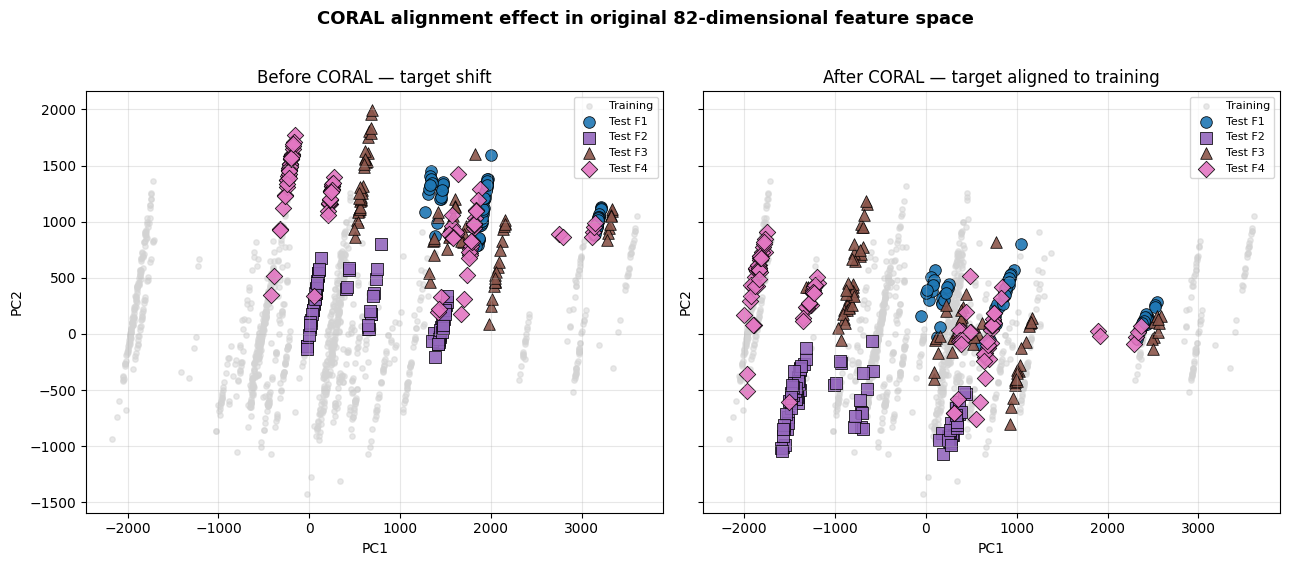

Saved PCA figure → /content/drive/MyDrive/ML_Project_2026/fig_coral_alignment.png
Saved CORAL prediction table → /content/drive/MyDrive/ML_Project_2026/coral_predictions.csv

FINAL CORAL CONSENSUS

Flange 1
  Predictions : [np.float64(25.0), np.float64(50.0), np.float64(50.0), np.float64(50.0), np.float64(50.0), np.float64(50.0), np.float64(50.0)]
  Consensus   : 50.0 ft-lbs (6/7 votes)
  Avg P(0)    : 0.240

Flange 2
  Predictions : [np.float64(25.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
  Consensus   : 0.0 ft-lbs (6/7 votes)
  Avg P(0)    : 0.688

Flange 3
  Predictions : [np.float64(50.0), np.float64(50.0), np.float64(50.0), np.float64(50.0), np.float64(50.0), np.float64(50.0), np.float64(50.0)]
  Consensus   : 50.0 ft-lbs (7/7 votes)
  Avg P(0)    : 0.136

Flange 4
  Predictions : [np.float64(50.0), np.float64(25.0), np.float64(25.0), np.float64(25.0), np.float64(25.0), np.float64(25.0), np.float64(25.0)]
  Consensus 

In [24]:
# ============================================================
# Cell 22: CORAL — test-time domain alignment
# ============================================================
# CORAL (CORrelation ALignment) is used here as a test-time,
# unsupervised domain adaptation method.
#
# Goal:
#   Map the experimental/lab test feature distribution into the
#   training-domain feature space, so the already-trained models
#   can be applied without retraining.
#
# Important:
#   - No target/test labels are used.
#   - Models are not retrained.
#   - Only feature-based models are corrected using CORAL.
#   - CNN/LSTM are not included because they use spectrogram inputs.
#
# Reference:
#   Sun et al., "Return of Frustratingly Easy Domain Adaptation,"
#   AAAI 2016.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.decomposition import PCA as PCAviz


# ============================================================
# 0) CORAL function: align target/test features to source/training
# ============================================================

def coral_align_target_to_source(X_source, X_target, eps=1e-6):
    """
    Test-time CORAL alignment.

    This function transforms the target/test features so that their
    mean and covariance become close to the source/training features.

    Parameters
    ----------
    X_source : array-like, shape (n_source, n_features)
        Training/source features.

    X_target : array-like, shape (n_target, n_features)
        Experimental/test target features.

    eps : float
        Small regularization value added to covariance matrices for
        numerical stability.

    Returns
    -------
    X_target_aligned : ndarray, shape (n_target, n_features)
        Target/test features aligned to the training-domain feature space.

    Transformation
    --------------
    X_target_aligned =
        (X_target - mu_target) @ C_target^(-1/2) @ C_source^(1/2) + mu_source
    """

    X_source = np.asarray(X_source, dtype=np.float64)
    X_target = np.asarray(X_target, dtype=np.float64)

    if X_source.ndim != 2 or X_target.ndim != 2:
        raise ValueError("X_source and X_target must both be 2D arrays.")

    if X_source.shape[1] != X_target.shape[1]:
        raise ValueError(
            f"Feature dimension mismatch: "
            f"source has {X_source.shape[1]}, target has {X_target.shape[1]}"
        )

    # --------------------------------------------------------
    # 1) Compute means and center both domains
    # --------------------------------------------------------
    mu_s = X_source.mean(axis=0, keepdims=True)
    mu_t = X_target.mean(axis=0, keepdims=True)

    Xs_c = X_source - mu_s
    Xt_c = X_target - mu_t

    d = X_source.shape[1]

    # --------------------------------------------------------
    # 2) Compute covariance matrices with regularization
    # --------------------------------------------------------
    C_s = np.cov(Xs_c, rowvar=False) + eps * np.eye(d)
    C_t = np.cov(Xt_c, rowvar=False) + eps * np.eye(d)

    # --------------------------------------------------------
    # 3) Eigen-decomposition for stable matrix square roots
    # --------------------------------------------------------
    eig_s, vec_s = np.linalg.eigh(C_s)
    eig_t, vec_t = np.linalg.eigh(C_t)

    # Avoid division by zero or tiny negative values caused by numerical error
    eig_s = np.maximum(eig_s, eps)
    eig_t = np.maximum(eig_t, eps)

    C_s_sqrt = vec_s @ np.diag(np.sqrt(eig_s)) @ vec_s.T
    C_t_inv_sqrt = vec_t @ np.diag(1.0 / np.sqrt(eig_t)) @ vec_t.T

    # --------------------------------------------------------
    # 4) Whiten target, re-color with source covariance, add source mean
    # --------------------------------------------------------
    X_target_aligned = Xt_c @ C_t_inv_sqrt @ C_s_sqrt + mu_s

    return X_target_aligned.astype(np.float32)


# ============================================================
# 1) Diagnostics helper functions
# ============================================================

def cov_distance(X1, X2):
    """
    Frobenius distance between covariance matrices of two feature sets.
    Smaller value means the second-order statistics are more similar.
    """
    X1 = np.asarray(X1)
    X2 = np.asarray(X2)

    C1 = np.cov(X1, rowvar=False)
    C2 = np.cov(X2, rowvar=False)

    return np.linalg.norm(C1 - C2, ord="fro")


def mean_distance(X1, X2):
    """
    L2 distance between feature means of two feature sets.
    Smaller value means the first-order statistics are more similar.
    """
    return np.linalg.norm(np.asarray(X1).mean(axis=0) - np.asarray(X2).mean(axis=0))


def aggregate(proba, meta_df, group_cols=["flange_id"]):
    """
    Aggregate hit-level probabilities into flange-level predictions.

    Parameters
    ----------
    proba : ndarray, shape (n_hits, 3)
        Class probabilities for each hit.

    meta_df : DataFrame
        Metadata for test hits. Must contain flange_id.

    group_cols : list
        Columns used for grouping. Default: ['flange_id'].

    Returns
    -------
    DataFrame with per-flange average probabilities and predictions.
    """
    rows = []

    for keys, grp in meta_df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)

        idx = grp.index.values
        avg = proba[idx].mean(axis=0)

        row = {col: k for col, k in zip(group_cols, keys)}
        row.update({
            "predicted": IDX_TO_CLASS[int(avg.argmax())],
            "p_0": float(avg[0]),
            "p_25": float(avg[1]),
            "p_50": float(avg[2]),
            "confidence": float(avg.max()),
            "margin": float(np.sort(avg)[-1] - np.sort(avg)[-2])
        })

        rows.append(row)

    return pd.DataFrame(rows).sort_values(group_cols).reset_index(drop=True)


# ============================================================
# 2) Apply CORAL to original and invariant feature sets
# ============================================================

print("=" * 72)
print("CORAL alignment: target/test → source/training domain")
print("=" * 72)

# Original 82-dimensional features
X_test_feat_coral = coral_align_target_to_source(
    X_source=X_feat,
    X_target=X_test_feat,
    eps=1e-6
)


# ============================================================
# 3) Verify CORAL alignment
# ============================================================

print("\nCovariance distance, original 82-dimensional features:")
print(f"  Before CORAL: {cov_distance(X_feat, X_test_feat):.4f}")
print(f"  After  CORAL: {cov_distance(X_feat, X_test_feat_coral):.4f}")



print("\nMean L2 distance:")
print(
    "  Original  before/after CORAL: "
    f"{mean_distance(X_feat, X_test_feat):.4f} → "
    f"{mean_distance(X_feat, X_test_feat_coral):.4f}"
)



# ============================================================
# 4) Run trained feature-based models on CORAL-aligned features
# ============================================================

print("\n" + "=" * 72)
print("Running trained models on CORAL-aligned test features")
print("=" * 72)

# ------------------------------------------------------------
# A) Original 82-dimensional feature models
# ------------------------------------------------------------

# SVM: final model is expected to be a sklearn Pipeline
svm_coral_proba = svm_results["final_model"].predict_proba(X_test_feat_coral)

# Logistic Regression: final model is expected to be a sklearn Pipeline
lr_coral_proba = lr_results["final_model"].predict_proba(X_test_feat_coral)

# KNN: final model is expected to be a sklearn Pipeline
knn_coral_proba = knn_results["final_model"].predict_proba(X_test_feat_coral)

# MLP: final model expects scaled features
X_test_feat_coral_mlp = mlp_results["final_scaler"].transform(X_test_feat_coral)
mlp_coral_proba = mlp_results["final_model"].predict(
    X_test_feat_coral_mlp,
    verbose=0
)

# ------------------------------------------------------------
# B) Feature-only CORAL ensemble
# ------------------------------------------------------------
# CNN/LSTM are not included because CORAL was applied to tabular features,
# not spectrograms.
# We re-normalize model weights using LOIO accuracies of feature-based models.

shallow_results = [
    svm_results,
    lr_results,
    mlp_results,
    knn_results
]

shallow_names = [
    "SVM",
    "LR",
    "MLP",
    "KNN"
]

shallow_accs = np.array(
    [r["task2_mean_acc"] for r in shallow_results],
    dtype=np.float64
)

shallow_w = shallow_accs / shallow_accs.sum()

print("\nFeature-only CORAL ensemble weights:")
for name, acc, w in zip(shallow_names, shallow_accs, shallow_w):
    print(f"  {name:<4}: LOIO acc = {acc * 100:6.2f}% | weight = {w:.4f}")

P_shallow_coral = np.stack(
    [
        svm_coral_proba,
        lr_coral_proba,
        mlp_coral_proba,
        knn_coral_proba
    ],
    axis=0
)

ens_shallow_coral_proba = (
    shallow_w[:, None, None] * P_shallow_coral
).sum(axis=0)


# ------------------------------------------------------------
# C) Hierarchical model using original 82-dimensional features
# ------------------------------------------------------------

hier_coral_pred, hier_coral_proba, hier_coral_info = hierarchical_predict(
    hier_results["final_stage1"],
    hier_results["final_stage2"],
    X_test_feat_coral
)


# ------------------------------------------------------------
# D) Invariant-feature models
# ------------------------------------------------------------




# ============================================================
# 5) Build comparison table: original vs CORAL-aligned results
# ============================================================

print("\n" + "=" * 72)
print("Building original vs CORAL comparison table")
print("=" * 72)

# Original baseline from earlier results
# Expected format:
# ALL_PREDS['Ensemble']['flange'] contains columns:
# flange_id, predicted, p_0, p_25, p_50, confidence
orig_ens_per_flange = ALL_PREDS["Ensemble"]["flange"].set_index("flange_id")

# Pre-compute aggregated CORAL outputs
svm_coral_df = aggregate(svm_coral_proba, test_meta_df)
lr_coral_df = aggregate(lr_coral_proba, test_meta_df)
mlp_coral_df = aggregate(mlp_coral_proba, test_meta_df)
knn_coral_df = aggregate(knn_coral_proba, test_meta_df)
ens_shallow_coral_df = aggregate(ens_shallow_coral_proba, test_meta_df)
hier_coral_df = aggregate(hier_coral_proba, test_meta_df)


results_rows = []

for fl in [1, 2, 3, 4]:
    row = {"flange": fl}

    # Original full ensemble, no CORAL
    row["Ens_orig"] = orig_ens_per_flange.loc[fl, "predicted"]
    row["Ens_orig_conf"] = round(orig_ens_per_flange.loc[fl, "confidence"], 3)

    if "p_0" in orig_ens_per_flange.columns:
        row["Ens_orig_p0"] = round(orig_ens_per_flange.loc[fl, "p_0"], 3)

    # SVM + CORAL
    df = svm_coral_df[svm_coral_df["flange_id"] == fl].iloc[0]
    row["SVM_CORAL"] = df["predicted"]
    row["SVM_CORAL_conf"] = round(df["confidence"], 3)
    row["SVM_CORAL_p0"] = round(df["p_0"], 3)

    # LR + CORAL
    df = lr_coral_df[lr_coral_df["flange_id"] == fl].iloc[0]
    row["LR_CORAL"] = df["predicted"]
    row["LR_CORAL_conf"] = round(df["confidence"], 3)
    row["LR_CORAL_p0"] = round(df["p_0"], 3)

    # MLP + CORAL
    df = mlp_coral_df[mlp_coral_df["flange_id"] == fl].iloc[0]
    row["MLP_CORAL"] = df["predicted"]
    row["MLP_CORAL_conf"] = round(df["confidence"], 3)
    row["MLP_CORAL_p0"] = round(df["p_0"], 3)

    # KNN + CORAL
    df = knn_coral_df[knn_coral_df["flange_id"] == fl].iloc[0]
    row["KNN_CORAL"] = df["predicted"]
    row["KNN_CORAL_conf"] = round(df["confidence"], 3)
    row["KNN_CORAL_p0"] = round(df["p_0"], 3)

    # Feature-only shallow ensemble + CORAL
    df = ens_shallow_coral_df[ens_shallow_coral_df["flange_id"] == fl].iloc[0]
    row["EnsShallow_CORAL"] = df["predicted"]
    row["EnsShallow_CORAL_conf"] = round(df["confidence"], 3)
    row["EnsShallow_CORAL_p0"] = round(df["p_0"], 3)

    # Hierarchical original features + CORAL
    df = hier_coral_df[hier_coral_df["flange_id"] == fl].iloc[0]
    row["Hier_CORAL"] = df["predicted"]
    row["Hier_CORAL_conf"] = round(df["confidence"], 3)
    row["Hier_CORAL_p0"] = round(df["p_0"], 3)


    results_rows.append(row)

coral_table = pd.DataFrame(results_rows)

print("\nLab-test predictions: original vs CORAL-aligned")
print(coral_table.to_string(index=False))


# ============================================================
# 6) PCA visualization before and after CORAL
# ============================================================
# Fit PCA only on training features.
# This shows how the test points move relative to the training feature space.

print("\n" + "=" * 72)
print("Visualizing CORAL effect using PCA")
print("=" * 72)

pca_v = PCAviz(n_components=2, random_state=SEED)
pca_v.fit(X_feat)

train_2d = pca_v.transform(X_feat)
test_2d_before = pca_v.transform(X_test_feat)
test_2d_after = pca_v.transform(X_test_feat_coral)

explained = pca_v.explained_variance_ratio_.sum() * 100
print(f"PCA variance explained by PC1 + PC2: {explained:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)

plot_specs = [
    (axes[0], test_2d_before, "Before CORAL — target shift"),
    (axes[1], test_2d_after, "After CORAL — target aligned to training")
]

markers = {
    1: "o",
    2: "s",
    3: "^",
    4: "D"
}

colors = {
    1: "#1f77b4",
    2: "#9467bd",
    3: "#8c564b",
    4: "#e377c2"
}

for ax, test_2d, title in plot_specs:
    ax.scatter(
        train_2d[:, 0],
        train_2d[:, 1],
        c="lightgray",
        s=15,
        alpha=0.50,
        label="Training"
    )

    for fl in [1, 2, 3, 4]:
        m = (test_meta_df["flange_id"] == fl).values

        ax.scatter(
            test_2d[m, 0],
            test_2d[m, 1],
            marker=markers[fl],
            s=70,
            c=colors[fl],
            edgecolor="black",
            linewidth=0.6,
            alpha=0.90,
            label=f"Test F{fl}"
        )

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(alpha=0.30)
    ax.legend(fontsize=8, loc="best")

plt.suptitle(
    "CORAL alignment effect in original 82-dimensional feature space",
    y=1.02,
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

coral_fig_path = os.path.join(OUTPUT_DIR, "fig_coral_alignment.png")
plt.savefig(coral_fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved PCA figure → {coral_fig_path}")


# ============================================================
# 7) Save CORAL prediction table
# ============================================================

coral_csv_path = os.path.join(OUTPUT_DIR, "coral_predictions.csv")
coral_table.to_csv(coral_csv_path, index=False)

print(f"Saved CORAL prediction table → {coral_csv_path}")


# ============================================================
# 8) Final CORAL consensus
# ============================================================

print("\n" + "=" * 72)
print("FINAL CORAL CONSENSUS")
print("=" * 72)

consensus_rows = []

for fl in [1, 2, 3, 4]:
    row = coral_table[coral_table["flange"] == fl].iloc[0]

    # Include original ensemble plus CORAL feature-based outputs
    preds = [
        row["Ens_orig"],
        row["SVM_CORAL"],
        row["LR_CORAL"],
        row["MLP_CORAL"],
        row["KNN_CORAL"],
        row["EnsShallow_CORAL"],
        row["Hier_CORAL"],

    ]

    votes = Counter(preds)
    winner, n_votes = votes.most_common(1)[0]

    p0_values = [
        row["SVM_CORAL_p0"],
        row["LR_CORAL_p0"],
        row["MLP_CORAL_p0"],
        row["KNN_CORAL_p0"],
        row["EnsShallow_CORAL_p0"],
        row["Hier_CORAL_p0"],

    ]

    avg_p0 = float(np.mean(p0_values))

    consensus_rows.append({
        "flange": fl,
        "consensus_prediction": winner,
        "votes": n_votes,
        "total_votes": len(preds),
        "avg_p0_coral_models": avg_p0
    })

    print(f"\nFlange {fl}")
    print(f"  Predictions : {preds}")
    print(f"  Consensus   : {winner} ft-lbs ({n_votes}/{len(preds)} votes)")
    print(f"  Avg P(0)    : {avg_p0:.3f}")

consensus_df = pd.DataFrame(consensus_rows)

consensus_csv_path = os.path.join(OUTPUT_DIR, "coral_consensus.csv")
consensus_df.to_csv(consensus_csv_path, index=False)

print("\n" + "=" * 72)
print("CORAL cell completed")
print("=" * 72)
print(f"Saved → {coral_csv_path}")
print(f"Saved → {consensus_csv_path}")
print(f"Saved → {coral_fig_path}")

In [26]:
# ============================================================
# Cell 25: Deep CORAL — embedding-space domain alignment
# ============================================================
# Apply CORAL to the penultimate-layer embeddings of CNN and LSTM,
# then refit a classifier head on aligned embeddings.
#
# Pipeline:
#   1. Build feature-extractor models (everything except final
#      softmax) for CNN and LSTM
#   2. Extract embeddings for all training hits and all test hits
#   3. CORAL-align test embeddings to training embedding distribution
#   4. Train a logistic regression head on training embeddings
#   5. Predict on aligned test embeddings
#   6. Compare with feature-CORAL consensus from Cell 22
#
# Reference: Sun & Saenko, "Deep CORAL: Correlation Alignment for
# Deep Domain Adaptation," ECCV 2016 Workshops.
# ============================================================
from sklearn.linear_model import LogisticRegression as LRClassifier

# ============================================================
# 1) Build feature-extractor models from the trained final models
# ============================================================
# For Keras Sequential / Functional models, the embedding layer is
# the layer just before the final softmax Dense layer.

_ = lstm_results['final_model'](X_seq[:1])  # dummy forward pass
_ = cnn_results ['final_model'](X_spec[:1]) # safety: warm CNN too

def get_feature_extractor(model, model_name, input_shape):
    """
    Return a Keras model that outputs the penultimate layer activation.
    Works for Sequential and Functional models, including those whose
    `model.layers` includes an InputLayer.
    """
    layers_list = list(model.layers)

    # Drop the InputLayer if present — we'll build a fresh Input tensor
    if isinstance(layers_list[0], keras.layers.InputLayer):
        layers_list = layers_list[1:]

    # Find the embedding layer: last non-output layer with weights/activation
    output_layer = None
    for i in range(len(layers_list) - 2, -1, -1):
        layer = layers_list[i]
        if isinstance(layer, (keras.layers.Dense, keras.layers.Dropout,
                               keras.layers.GlobalAveragePooling2D,
                               keras.layers.Bidirectional)):
            output_layer = layer
            break
    if output_layer is None:
        raise ValueError(f"Could not find embedding layer in {model_name}")

    # Build a fresh forward pass through the model up to the embedding layer
    new_input = keras.Input(shape=input_shape)
    x = new_input
    for layer in layers_list:
        x = layer(x)
        if layer is output_layer:
            break

    extractor = keras.Model(inputs=new_input, outputs=x,
                             name=f"{model_name}_embedder")
    print(f"{model_name} embedder: input={new_input.shape}, "
          f"output={x.shape}, using layer '{output_layer.name}'")
    return extractor

cnn_embedder  = get_feature_extractor(cnn_results['final_model'],  'CNN',
                                       input_shape=(N_MELS, SPEC_TIME_FRAMES, 1))
lstm_embedder = get_feature_extractor(lstm_results['final_model'], 'LSTM',
                                       input_shape=(SPEC_TIME_FRAMES, N_MELS))

# cnn_embedder  = get_feature_extractor(cnn_results['final_model'], 'CNN')
# lstm_embedder = get_feature_extractor(lstm_results['final_model'], 'LSTM')

# ============================================================
# 2) Extract embeddings for all training and test data
# ============================================================
print("\n" + "="*72)
print("Extracting embeddings for training and test data")
print("="*72)

# CNN: input is X_spec shape (N, 64, 128, 1)
emb_cnn_train = cnn_embedder.predict(X_spec,       verbose=0)
emb_cnn_test  = cnn_embedder.predict(X_test_spec,  verbose=0)

# LSTM: input is X_seq shape (N, 128, 64)
emb_lstm_train = lstm_embedder.predict(X_seq,      verbose=0)
emb_lstm_test  = lstm_embedder.predict(X_test_seq, verbose=0)

print(f"CNN embeddings : train {emb_cnn_train.shape}, test {emb_cnn_test.shape}")
print(f"LSTM embeddings: train {emb_lstm_train.shape}, test {emb_lstm_test.shape}")

# Sanity: the embedding dimensionality must be much smaller than the
# number of training samples for CORAL to be well-conditioned.
print(f"\nWell-conditioned check (n_samples >> n_features):")
print(f"  CNN : {emb_cnn_train.shape[0]} samples, {emb_cnn_train.shape[1]} dims "
      f"→ ratio {emb_cnn_train.shape[0]/emb_cnn_train.shape[1]:.1f}x")
print(f"  LSTM: {emb_lstm_train.shape[0]} samples, {emb_lstm_train.shape[1]} dims "
      f"→ ratio {emb_lstm_train.shape[0]/emb_lstm_train.shape[1]:.1f}x")

# ============================================================
# 3) Apply CORAL in embedding space
# ============================================================
print("\n" + "="*72)
print("CORAL alignment in embedding space")
print("="*72)

emb_cnn_test_coral  = coral_align_target_to_source(emb_cnn_train,  emb_cnn_test)
emb_lstm_test_coral = coral_align_target_to_source(emb_lstm_train, emb_lstm_test)

# Verify alignment quality
print(f"\nCNN embedding covariance distance:")
print(f"  Before: {cov_distance(emb_cnn_train, emb_cnn_test):.4f}")
print(f"  After : {cov_distance(emb_cnn_train, emb_cnn_test_coral):.4f}")
print(f"  Mean L2: {mean_distance(emb_cnn_train, emb_cnn_test):.4f} → "
      f"{mean_distance(emb_cnn_train, emb_cnn_test_coral):.4f}")

print(f"\nLSTM embedding covariance distance:")
print(f"  Before: {cov_distance(emb_lstm_train, emb_lstm_test):.4f}")
print(f"  After : {cov_distance(emb_lstm_train, emb_lstm_test_coral):.4f}")
print(f"  Mean L2: {mean_distance(emb_lstm_train, emb_lstm_test):.4f} → "
      f"{mean_distance(emb_lstm_train, emb_lstm_test_coral):.4f}")

# ============================================================
# 4) Refit classifier heads on training embeddings
# ============================================================
# The original softmax heads were trained jointly with the feature
# extractor on the original (un-aligned) embeddings. We refit a
# fresh linear classifier on the same training embeddings — this
# gives us a head that's properly calibrated for the embedding
# distribution we'll be feeding it.
# ============================================================
print("\n" + "="*72)
print("Training fresh classifier heads on embeddings")
print("="*72)

# Use scikit's logistic regression — fast, well-behaved on small embeddings
cnn_head = LRClassifier(multi_class='multinomial', solver='lbfgs',
                         class_weight='balanced', max_iter=2000, C=1.0,
                         random_state=SEED).fit(emb_cnn_train, y)
lstm_head = LRClassifier(multi_class='multinomial', solver='lbfgs',
                          class_weight='balanced', max_iter=2000, C=1.0,
                          random_state=SEED).fit(emb_lstm_train, y)

print(f"CNN head training acc : {cnn_head.score(emb_cnn_train, y)*100:.2f}%")
print(f"LSTM head training acc: {lstm_head.score(emb_lstm_train, y)*100:.2f}%")

# Also do a quick LOIO sanity check on the embedding+head pipeline
# to make sure refitting the head didn't break LOIO performance
print("\nLOIO sanity check on embedding+head pipeline (CNN):")
cnn_emb_loio = []
for fold, (tr, te) in enumerate(LeaveOneGroupOut().split(emb_cnn_train, y, groups), 1):
    head = LRClassifier(multi_class='multinomial', solver='lbfgs',
                        class_weight='balanced', max_iter=2000, C=1.0,
                        random_state=SEED).fit(emb_cnn_train[tr], y[tr])
    yp = head.predict(emb_cnn_train[te])
    a = accuracy_score(y[te], yp)
    cnn_emb_loio.append(a)
    print(f"  Fold {fold} (F{int(groups[te[0]])}): {a*100:.2f}%")
print(f"  Mean LOIO: {np.mean(cnn_emb_loio)*100:.2f}% "
      f"(original CNN LOIO: {cnn_results['task2_mean_acc']*100:.2f}%)")

print("\nLOIO sanity check (LSTM):")
lstm_emb_loio = []
for fold, (tr, te) in enumerate(LeaveOneGroupOut().split(emb_lstm_train, y, groups), 1):
    head = LRClassifier(multi_class='multinomial', solver='lbfgs',
                        class_weight='balanced', max_iter=2000, C=1.0,
                        random_state=SEED).fit(emb_lstm_train[tr], y[tr])
    yp = head.predict(emb_lstm_train[te])
    a = accuracy_score(y[te], yp)
    lstm_emb_loio.append(a)
    print(f"  Fold {fold} (F{int(groups[te[0]])}): {a*100:.2f}%")
print(f"  Mean LOIO: {np.mean(lstm_emb_loio)*100:.2f}% "
      f"(original LSTM LOIO: {lstm_results['task2_mean_acc']*100:.2f}%)")

# ============================================================
# 5) Predict on lab test: with and without embedding-CORAL
# ============================================================
print("\n" + "="*72)
print("Predicting lab test with embedding-CORAL vs without")
print("="*72)

# Without CORAL (raw embeddings)
cnn_raw_proba   = cnn_head.predict_proba(emb_cnn_test)
lstm_raw_proba  = lstm_head.predict_proba(emb_lstm_test)

# With embedding-CORAL
cnn_coral_proba  = cnn_head.predict_proba(emb_cnn_test_coral)
lstm_coral_proba = lstm_head.predict_proba(emb_lstm_test_coral)

# Aggregate per flange
cnn_raw_df    = aggregate(cnn_raw_proba,    test_meta_df)
lstm_raw_df   = aggregate(lstm_raw_proba,   test_meta_df)
cnn_coral_df  = aggregate(cnn_coral_proba,  test_meta_df)
lstm_coral_df = aggregate(lstm_coral_proba, test_meta_df)

# ============================================================
# 6) Comparison table — deep models, CORAL'd vs not
# ============================================================
deep_rows = []
for fl in [1, 2, 3, 4]:
    row = {'flange': fl}
    # Original CNN (using its native softmax head, no CORAL)
    orig_cnn_pred = ALL_PREDS['CNN']['flange']
    orig_cnn_pred = orig_cnn_pred[orig_cnn_pred['flange_id'] == fl].iloc[0]
    row['CNN_orig']      = orig_cnn_pred['predicted']
    row['CNN_orig_p0']   = round(orig_cnn_pred['p_0ftlbs'], 3)

    # CNN with refit head, no CORAL
    df = cnn_raw_df[cnn_raw_df['flange_id'] == fl].iloc[0]
    row['CNN_refit']     = df['predicted']
    row['CNN_refit_p0']  = round(df['p_0'], 3)
    row['CNN_refit_conf']= round(df['confidence'], 3)

    # CNN with embedding-CORAL
    df = cnn_coral_df[cnn_coral_df['flange_id'] == fl].iloc[0]
    row['CNN_CORAL']     = df['predicted']
    row['CNN_CORAL_p0']  = round(df['p_0'], 3)
    row['CNN_CORAL_conf']= round(df['confidence'], 3)

    # Original LSTM
    orig_lstm = ALL_PREDS['LSTM']['flange']
    orig_lstm = orig_lstm[orig_lstm['flange_id'] == fl].iloc[0]
    row['LSTM_orig']      = orig_lstm['predicted']
    row['LSTM_orig_p0']   = round(orig_lstm['p_0ftlbs'], 3)

    # LSTM with refit head, no CORAL
    df = lstm_raw_df[lstm_raw_df['flange_id'] == fl].iloc[0]
    row['LSTM_refit']     = df['predicted']
    row['LSTM_refit_p0']  = round(df['p_0'], 3)
    row['LSTM_refit_conf']= round(df['confidence'], 3)

    # LSTM with embedding-CORAL
    df = lstm_coral_df[lstm_coral_df['flange_id'] == fl].iloc[0]
    row['LSTM_CORAL']     = df['predicted']
    row['LSTM_CORAL_p0']  = round(df['p_0'], 3)
    row['LSTM_CORAL_conf']= round(df['confidence'], 3)

    deep_rows.append(row)

deep_table = pd.DataFrame(deep_rows)
print("\nDeep models: original vs refit-head vs embedding-CORAL")
print(deep_table.to_string(index=False))

# ============================================================
# 7) Master 9-model consensus
# ============================================================
# 6 feature-based CORAL pipelines (from Cell 22)
#   + 1 un-adapted ensemble baseline
#   + 2 deep CORAL (this cell)
# = 9 votes per flange
# ============================================================
print("\n" + "="*72)
print("UPDATED CONSENSUS — 9 CORAL-aligned pipelines")
print("="*72)

for fl in [1, 2, 3, 4]:
    # Feature-based CORAL predictions (from Cell 22 coral_table)
    fr = coral_table[coral_table['flange'] == fl].iloc[0]
    feat_preds = [
        fr['SVM_CORAL'], fr['LR_CORAL'], fr['MLP_CORAL'], fr['KNN_CORAL'],
        fr['EnsShallow_CORAL'], fr['Hier_CORAL'],
    ]
    # Add the un-adapted ensemble for reference
    orig_ens_pred = fr['Ens_orig']

    # Deep CORAL predictions (this cell)
    dr = deep_table[deep_table['flange'] == fl].iloc[0]
    deep_preds = [dr['CNN_CORAL'], dr['LSTM_CORAL']]

    all_coral = feat_preds + deep_preds
    votes = Counter(all_coral)
    winner, n_votes = votes.most_common(1)[0]

    p0_values = [
        fr['SVM_CORAL_p0'], fr['LR_CORAL_p0'], fr['MLP_CORAL_p0'],
        fr['KNN_CORAL_p0'], fr['EnsShallow_CORAL_p0'], fr['Hier_CORAL_p0'],
        dr['CNN_CORAL_p0'], dr['LSTM_CORAL_p0'],
    ]
    avg_p0 = float(np.mean(p0_values))

    print(f"\nFlange {fl}:")
    print(f"  Feature-CORAL votes: {feat_preds}")
    print(f"  Deep-CORAL votes   : {deep_preds}")
    print(f"  Original (no CORAL): {orig_ens_pred}")
    print(f"  → Consensus: {winner} ft-lbs ({n_votes}/{len(all_coral)} votes)")
    print(f"  → Avg P(0) across CORAL: {avg_p0:.3f}")

# Save
deep_table.to_csv(os.path.join(OUTPUT_DIR, 'deep_coral_predictions.csv'), index=False)
print(f"\nSaved → deep_coral_predictions.csv")

CNN embedder: input=(None, 64, 128, 1), output=(None, 128), using layer 'dropout_24'
LSTM embedder: input=(None, 128, 64), output=(None, 32), using layer 'dropout_45'

Extracting embeddings for training and test data
CNN embeddings : train (991, 128), test (360, 128)
LSTM embeddings: train (991, 32), test (360, 32)

Well-conditioned check (n_samples >> n_features):
  CNN : 991 samples, 128 dims → ratio 7.7x
  LSTM: 991 samples, 32 dims → ratio 31.0x

CORAL alignment in embedding space

CNN embedding covariance distance:
  Before: 37.7464
  After : 0.0111
  Mean L2: 4.7387 → 0.0000

LSTM embedding covariance distance:
  Before: 31.2004
  After : 0.0583
  Mean L2: 6.2084 → 0.0000

Training fresh classifier heads on embeddings
CNN head training acc : 100.00%
LSTM head training acc: 99.80%

LOIO sanity check on embedding+head pipeline (CNN):
  Fold 1 (F1): 100.00%
  Fold 2 (F2): 100.00%
  Fold 3 (F3): 100.00%
  Fold 4 (F4): 100.00%
  Mean LOIO: 100.00% (original CNN LOIO: 67.97%)

LOIO san

UNSUPERVISED CLUSTERING METRICS (training data, no labels used)
 k   ARI  Silhouette  Purity
 2 0.695       0.116   0.917
 3 0.459       0.115   0.653

k=2 composition (binary: loose vs tight):
 cluster  size  loose  tight purity
       0   410    328     82    80%
       1   581      0    581   100%

k=3 composition (3-class):
 cluster  size  0 ft-lbs  25 ft-lbs  50 ft-lbs purity
       0   580         0        262        318    55%
       1   410       328         67         15    80%
       2     1         0          1          0   100%

PCA: PC1+PC2 explain 23.6% of variance


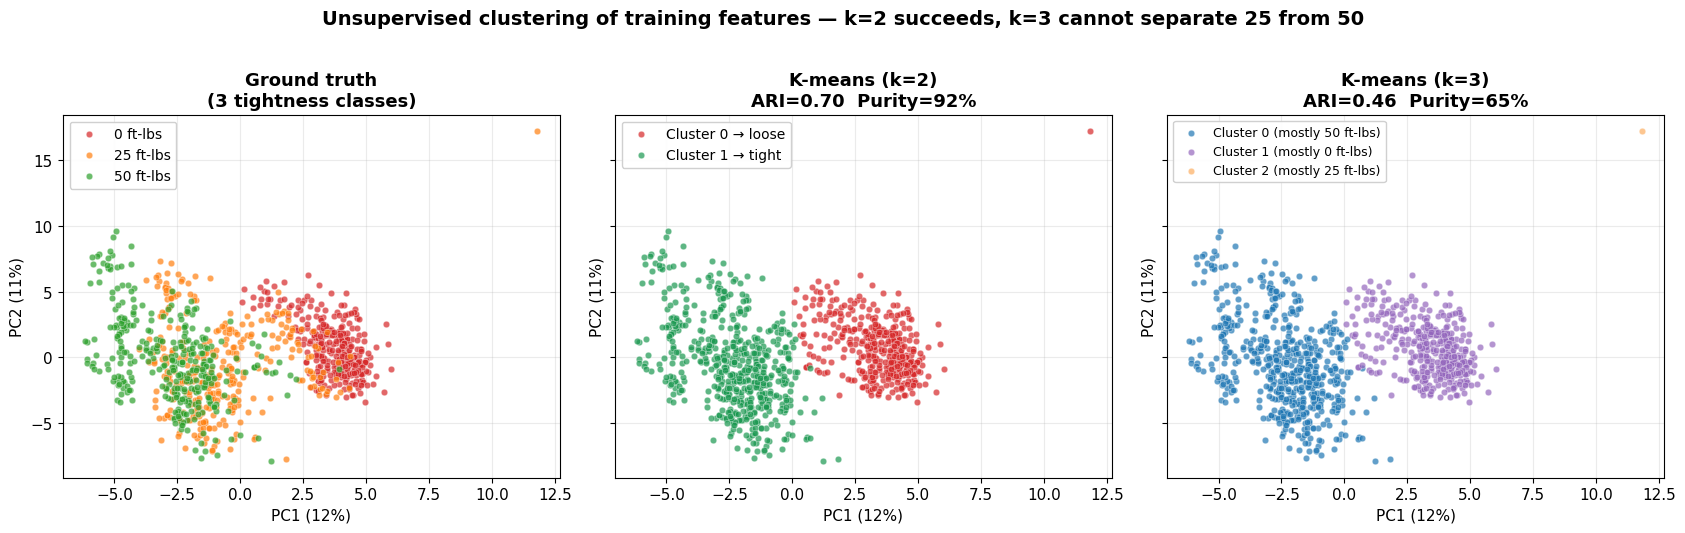

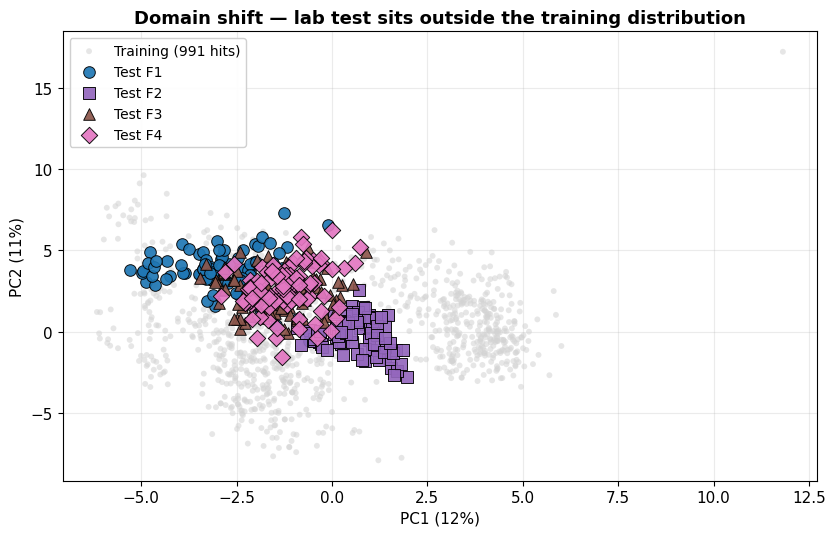


Saved → fig_clustering_main.png
Saved → fig_domain_shift.png
Saved → clustering_metrics.csv


In [27]:
# ============================================================
# Cell 18: Unsupervised Clustering — Bonus Task
# ============================================================
# Question (project docx bonus):
#   Can unsupervised clustering discover the three tightness classes
#   (0 / 25 / 50 ft-lbs) without seeing labels?
#
# Method:
#   K-means with k=2 and k=3 on the 82-dim training features (z-scored).
#   Compare cluster assignments with true labels using:
#     - Adjusted Rand Index (ARI)
#     - Silhouette score
#     - Per-cluster purity
#
# Headline finding:
#   k=2 cleanly separates LOOSE (0) from TIGHT (25 + 50).
#   k=3 fails to separate 25 from 50 — they collapse into one cluster.
#   The natural geometry of the feature space is BINARY, not ternary.
#   This mirrors what every supervised model showed: 25-vs-50 is the
#   hard problem, regardless of approach.
# ============================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1) Standardize training features
# ------------------------------------------------------------
scaler = StandardScaler().fit(X_feat)
Xtr_s = scaler.transform(X_feat)

# ------------------------------------------------------------
# 2) K-means clustering (k=2 and k=3) — training data only
# ------------------------------------------------------------
km2 = KMeans(n_clusters=2, random_state=SEED, n_init=50).fit(Xtr_s)
km3 = KMeans(n_clusters=3, random_state=SEED, n_init=50).fit(Xtr_s)

cl2, cl3 = km2.labels_, km3.labels_

# ------------------------------------------------------------
# 3) Evaluation metrics
# ------------------------------------------------------------
def purity(labels, y_true):
    """Average max-class fraction across clusters."""
    total, correct = 0, 0
    for cl in np.unique(labels):
        m = labels == cl
        total += m.sum()
        correct += np.bincount(y_true[m], minlength=3).max()
    return correct / total

# For k=2, true labels are binary: loose (0) vs tight (25 or 50)
y_binary = (y > 0).astype(int)

metrics = pd.DataFrame({
    'k'             : [2, 3],
    'ARI'           : [adjusted_rand_score(y_binary, cl2),
                       adjusted_rand_score(y,        cl3)],
    'Silhouette'    : [silhouette_score(Xtr_s, cl2),
                       silhouette_score(Xtr_s, cl3)],
    'Purity'        : [purity(cl2, y_binary),
                       purity(cl3, y)],
})
print("="*64)
print("UNSUPERVISED CLUSTERING METRICS (training data, no labels used)")
print("="*64)
print(metrics.round(3).to_string(index=False))

# Cluster composition
def composition(labels, k, y_true, label_names):
    rows = []
    for cl in range(k):
        m = labels == cl
        if not m.sum(): continue
        d = np.bincount(y_true[m], minlength=len(label_names))
        rows.append({'cluster': cl, 'size': int(m.sum()),
                     **{label_names[i]: int(d[i]) for i in range(len(label_names))},
                     'purity': f"{d.max()/d.sum():.0%}"})
    return pd.DataFrame(rows)

print("\nk=2 composition (binary: loose vs tight):")
print(composition(cl2, 2, y_binary, ['loose', 'tight']).to_string(index=False))
print("\nk=3 composition (3-class):")
print(composition(cl3, 3, y, ['0 ft-lbs', '25 ft-lbs', '50 ft-lbs']).to_string(index=False))

# ------------------------------------------------------------
# 4) PCA reduction for visualization (training data only)
# ------------------------------------------------------------
pca = PCA(n_components=2, random_state=SEED).fit(Xtr_s)
Xpca = pca.transform(Xtr_s)
print(f"\nPCA: PC1+PC2 explain {pca.explained_variance_ratio_.sum():.1%} of variance")

# ------------------------------------------------------------
# 5) MAIN FIGURE — bonus clustering result, 1×3 panel
# ------------------------------------------------------------
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13,
                     'axes.titleweight': 'bold'})

CLASS_C  = {0: '#d62728', 1: '#ff7f0e', 2: '#2ca02c'}     # red / orange / green
BINARY_C = {0: '#d62728', 1: '#1a9850'}                    # red (loose) / green (tight)
K3_C     = ['#1f77b4', '#9467bd', '#fdae61']               # qualitative for k=3

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2),
                          sharex=True, sharey=True)

# Panel 1 — Ground truth (3 classes)
for cls in range(N_CLASSES):
    m = y == cls
    axes[0].scatter(Xpca[m, 0], Xpca[m, 1], c=CLASS_C[cls], s=22,
                    alpha=0.7, edgecolor='white', linewidth=0.3,
                    label=f'{IDX_TO_CLASS[cls]} ft-lbs')
axes[0].set_title('Ground truth\n(3 tightness classes)')
axes[0].legend(fontsize=10, loc='best', framealpha=0.92)

# Panel 2 — K-means k=2 (binary discovery)
# Auto-relabel so cluster colors match the dominant true class
remap2 = {cl: int(np.bincount(y_binary[cl2==cl], minlength=2).argmax())
          for cl in range(2)}
for cl in range(2):
    m = cl2 == cl
    axes[1].scatter(Xpca[m, 0], Xpca[m, 1], c=BINARY_C[remap2[cl]], s=22,
                    alpha=0.7, edgecolor='white', linewidth=0.3,
                    label=f"Cluster {cl} → {'loose' if remap2[cl]==0 else 'tight'}")
axes[1].set_title(f'K-means (k=2)\nARI={metrics.loc[0,"ARI"]:.2f}  '
                  f'Purity={metrics.loc[0,"Purity"]:.0%}')
axes[1].legend(fontsize=10, loc='best', framealpha=0.92)

# Panel 3 — K-means k=3 (attempt at 3-class discovery)
for cl in range(3):
    m = cl3 == cl
    if not m.sum(): continue
    # Tag cluster by its dominant true class to make the failure visible
    dom = int(np.bincount(y[m], minlength=3).argmax())
    axes[2].scatter(Xpca[m, 0], Xpca[m, 1], c=K3_C[cl], s=22,
                    alpha=0.7, edgecolor='white', linewidth=0.3,
                    label=f"Cluster {cl} (mostly {IDX_TO_CLASS[dom]} ft-lbs)")
axes[2].set_title(f'K-means (k=3)\nARI={metrics.loc[1,"ARI"]:.2f}  '
                  f'Purity={metrics.loc[1,"Purity"]:.0%}')
axes[2].legend(fontsize=9, loc='best', framealpha=0.92)

for ax in axes:
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)

plt.suptitle('Unsupervised clustering of training features — '
             'k=2 succeeds, k=3 cannot separate 25 from 50',
             y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_clustering_main.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 6) COMPANION FIGURE — domain shift (training vs lab test)
# ------------------------------------------------------------
# A separate, single panel: shows that even though clustering works
# well on training, the lab test data sits in a different region
# of feature space. Motivates the CORAL section.
# ------------------------------------------------------------
Xte_s = scaler.transform(X_test_feat)
Xpca_te = pca.transform(Xte_s)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
# Training, gray background
ax.scatter(Xpca[:, 0], Xpca[:, 1], c='lightgray', s=18, alpha=0.55,
           label='Training (991 hits)', edgecolor='none')
# Test by flange
flange_marker = {1: 'o', 2: 's', 3: '^', 4: 'D'}
flange_color  = {1: '#1f77b4', 2: '#9467bd', 3: '#8c564b', 4: '#e377c2'}
for fl in [1, 2, 3, 4]:
    m = (test_meta_df['flange_id'] == fl).values
    ax.scatter(Xpca_te[m, 0], Xpca_te[m, 1], marker=flange_marker[fl],
               s=70, c=flange_color[fl], edgecolor='black', linewidth=0.7,
               alpha=0.92, label=f'Test F{fl}')
ax.set_title('Domain shift — lab test sits outside the training distribution',
             fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')
ax.grid(alpha=0.25); ax.set_axisbelow(True)
ax.legend(fontsize=10, loc='best', framealpha=0.92)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_domain_shift.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 7) Save metrics
# ------------------------------------------------------------
metrics.to_csv(os.path.join(OUTPUT_DIR, 'clustering_metrics.csv'), index=False)
print(f"\nSaved → fig_clustering_main.png")
print(f"Saved → fig_domain_shift.png")
print(f"Saved → clustering_metrics.csv")

In [31]:
!pip install nbconvert
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc
!apt-get update
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-plain-generic
!jupyter nbconvert --to pdf "/content/final.ipynb"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-extra texlive-latex-recommended texlive-pictures tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-fr

In [32]:
from google.colab import files

# nbconvert produces the PDF in the same directory as the notebook,
# with the same base name. So /content/final.ipynb → /content/final.pdf
files.download('/content/final.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>